# Load Libraries

In [1]:
import sys, os, pygmt, importlib, re, time, glob, io
mod_path = '/home/581/da1339/AFIM/src/AFIM/src'
sys.path.insert(0, mod_path)
from sea_ice_toolbox      import SeaIceToolbox, SeaIceToolboxManager
from datetime             import timedelta, date, datetime
from pathlib              import Path
from dask.distributed     import Client, LocalCluster
from dask.diagnostics     import ProgressBar
from pyproj               import CRS, Transformer
from collections          import defaultdict
from scipy.interpolate      import interp1d
#from tqdm                   import tqdm        
import numpy                as np
import pandas               as pd
import xarray               as xr
import xesmf                as xe
import matplotlib.pyplot    as plt
import matplotlib.dates     as mdates
import matplotlib.animation as animation
from IPython.display        import Image, HTML, Video
import warnings
warnings.filterwarnings("ignore", message="Sending large graph of size", category=UserWarning, module="distributed.client")
from pyproj import Transformer
from pyresample.geometry import AreaDefinition, SwathDefinition
from pyresample.kd_tree import resample_nearest

## reload SeaIceToolbox if local changes have been made

In [29]:
import sys
import importlib
for mod in list(sys.modules):
    if mod.startswith("sea_ice_toolbox") or mod.startswith("sea_ice_"):
        del sys.modules[mod]
import sea_ice_plotter
import sea_ice_gridwork
import sea_ice_cice
import sea_ice_fast
import sea_ice_ACCESS
import sea_ice_classification
import sea_ice_icebergs
import sea_ice_observations
import sea_ice_metrics
import sea_ice_toolbox
importlib.reload(sea_ice_plotter)
importlib.reload(sea_ice_cice)
importlib.reload(sea_ice_fast)
importlib.reload(sea_ice_ACCESS)
importlib.reload(sea_ice_classification)
importlib.reload(sea_ice_icebergs)
importlib.reload(sea_ice_observations)
importlib.reload(sea_ice_metrics)
importlib.reload(sea_ice_toolbox)
from sea_ice_toolbox import SeaIceToolbox, SeaIceToolboxManager

In [ ]:
import sys
sys.path.insert(0,'/home/581/da1339/AFIM/src/AFIM/src')
import sea_ice_toolbox
print([m for m in dir(sea_ice_toolbox) if 'Toolbox' in m])

# [Simulation Table](https://dpath2o.github.io/AFIM/ice_diag_summary.html)

# [Methodology](https://dpath2o.github.io/AFIM/AFIM_sensitivity_methodology.html)

# quantify the fraction of LFI that needs grounded icebergs

## simple method

In [30]:
sim_with_gib    = "elps-min"
sim_without_gib = "gi-nil-def"
dt0_str         = "1994-01-01"
dtN_str         = "1999-12-31"
P_log           = Path(Path.home(), "logs", "paper1_fastice_panel.log")
mgr             = SeaIceToolboxManager(P_log=P_log)
tb_with         = mgr.get_toolbox(sim_name       = sim_with_gib,
                                  dt0_str        = dt0_str,
                                  dtN_str        = dtN_str,
                                  ice_type       = "FI",
                                  list_of_BorC2T = ['Tb'])
tb_without      = mgr.get_toolbox(sim_name       = sim_without_gib,
                                  dt0_str        = dt0_str,
                                  dtN_str        = dtN_str,
                                  ice_type       = "FI",
                                  list_of_BorC2T = ['Tb'])
FIA_with        = tb_with.load_computed_metrics()['FIA']
FIA_without     = tb_without.load_computed_metrics()['FIA']
mean_with       = float(FIA_with.mean())
mean_without    = float(FIA_without.mean())
frac_gib_req    = 1 - (mean_without / mean_with)
print("Mean FIA with GIB:", mean_with)
print("Mean FIA without GIB:", mean_without)
print("Fraction of fast ice requiring grounded icebergs:", frac_gib_req)

/g/data/gv90/da1339/conda-envs/afim-geo/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39837 instead
  warnings.warn(
2026-03-12 14:50:38,207 - INFO - log file connected: /home/581/da1339/logs/paper1_fastice_panel.log
2026-03-12 14:50:38,216 - INFO - Dask Client Connected
  Dashboard      : /proxy/39837/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 14:50:38,217 - INFO - hemisphere initialised: SH
2026-03-12 14:50:38,219 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 14:50:38,223 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 14:50:38,224 - INFO - Simulation Name     : elps-min
2026-03-12 14:50:38,226 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 14:50:38,228 - INFO - Analysis End Da

Mean FIA with GIB: 468.66876220703125
Mean FIA without GIB: 80.0440902709961
Fraction of fast ice requiring grounded icebergs: 0.8292096748798522


## more complex method

+ looks at the GIB area of *best-performing* simulation (`elps-min`) and compares that to FIP
+ benefit is that more accurately gets at the dependency 

In [ ]:
from scipy.ndimage import binary_dilation
# helpers
def month_abbr():
    return ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def define_GIB_zone(GIB, buffer_cells=1, connectivity=8):
    if GIB.ndim != 2:
        raise ValueError(f"GIB must be 2D, got dims={GIB.dims}")

    rename_map = {}
    if "nj" in GIB.dims:
        rename_map["nj"] = "y"
    if "ni" in GIB.dims:
        rename_map["ni"] = "x"
    GIB = GIB.rename(rename_map).astype(bool).load()

    if connectivity == 8:
        structure = np.ones((3, 3), dtype=bool)
    elif connectivity == 4:
        structure = np.array([[0, 1, 0],
                              [1, 1, 1],
                              [0, 1, 0]], dtype=bool)
    else:
        raise ValueError("connectivity must be 4 or 8")

    zone = binary_dilation(GIB.values, structure=structure, iterations=buffer_cells)
    return xr.DataArray(zone, coords=GIB.coords, dims=GIB.dims, name="GIB_zone")

def monthly_climatology(da):
    return da.groupby("time.month").mean("time")

def load_fi_mask(sim_name, dt0_str, dtN_str, P_log):
    mgr = SeaIceToolboxManager(P_log=P_log)
    tb = mgr.get_toolbox(
        sim_name=sim_name,
        dt0_str=dt0_str,
        dtN_str=dtN_str,
        ice_type="FI",
        list_of_BorC2T=["Tb"],
    )

    FI = tb.load_classified_ice(class_method="binary-days")["FI_mask"]

    rename_map = {}
    if "nj" in FI.dims:
        rename_map["nj"] = "y"
    if "ni" in FI.dims:
        rename_map["ni"] = "x"
    FI = FI.rename(rename_map)

    if "date" in FI.coords:
        FI = FI.rename({"date": "time"})

    FI = FI.sel(time=slice(dt0_str, dtN_str)).fillna(0).astype("uint8")
    return FI, tb

def load_aice(tb, dt0_str, dtN_str):
    aice = tb.load_cice_zarr(variables=["aice"], slice_hem=True)["aice"]

    rename_map = {}
    if "nj" in aice.dims:
        rename_map["nj"] = "y"
    if "ni" in aice.dims:
        rename_map["ni"] = "x"
    aice = aice.rename(rename_map)

    if "date" in aice.coords:
        aice = aice.rename({"date": "time"})

    aice = aice.sel(time=slice(dt0_str, dtN_str)).fillna(0).astype("float32")
    return aice

def load_grid_and_gib(tb, y_slice=None):
    tb.load_cice_grid()
    G = tb.G_t
    korg = tb.kmt_org["kmt_org"]
    kmod = tb.kmt_mod["kmt_mod"]
    area = G["area"]
    lat = G["lat"]
    lon = G["lon"]

    GIB = (korg > 0) & (~(kmod > 0))

    rename_map = {}
    if "nj" in GIB.dims:
        rename_map["nj"] = "y"
    if "ni" in GIB.dims:
        rename_map["ni"] = "x"

    GIB  = GIB.rename(rename_map).astype("uint8")
    area = area.rename(rename_map).astype("float32")
    lat  = lat.rename(rename_map)
    lon  = lon.rename(rename_map)

    ds = xr.Dataset({
        "GI_mask": GIB,
        "area": area,
        "lat": lat,
        "lon": lon,
    })

    if y_slice is not None:
        ds = ds.isel(y=y_slice)

    return ds

def align_space(FI, grid_ds):
    return xr.Dataset({
        v: grid_ds[v].sel(y=FI["y"], x=FI["x"])
        for v in ["GI_mask", "area", "lat", "lon"]
    })

def weighted_fia(mask, aice, area):
    """
    FIA in units of 10^3 km^2 if area is m^2.
    """
    mask = mask.fillna(0).astype("uint8")
    aice = aice.fillna(0).astype("float32")
    mask, aice = xr.align(mask, aice, join="inner")
    area = area.sel(y=mask["y"], x=mask["x"])
    return ((mask * aice * area).sum(("y", "x")) / 1e9).rename("FIA")

In [ ]:
# config
sim_with_gib    = "elps-min"
sim_without_gib = "gi-nil-def"
dt0_str         = "1994-01-01"
dtN_str         = "1999-12-31"

P_log = Path(Path.home(), "logs", "paper1_gib_dependence.log")
D_out = Path("/g/data/gv90/da1339/GRAPHICAL/AFIM/elps-min")
D_out.mkdir(parents=True, exist_ok=True)
P_png = D_out / "FIA_GIB_dependence_3panel_1994_1999.png"

In [ ]:
# load masks, toolbox, aice
FI_with, tb_with       = load_fi_mask(sim_with_gib, dt0_str, dtN_str, P_log)
FI_without, tb_without = load_fi_mask(sim_without_gib, dt0_str, dtN_str, P_log)
aice_with = load_aice(tb_with, dt0_str, dtN_str)
FI_with, FI_without, aice_with = xr.align(FI_with, FI_without, aice_with, join="inner")

# moderate chunking
FI_with    = FI_with.chunk({"time": 31, "y": 180, "x": 360})
FI_without = FI_without.chunk({"time": 31, "y": 180, "x": 360})
aice_with  = aice_with.chunk({"time": 31, "y": 180, "x": 360})

# load grid + GIB mask
grid_ds = load_grid_and_gib(tb_with, y_slice=slice(0, 540))
grid_ds = align_space(FI_with, grid_ds)

GI_mask = grid_ds["GI_mask"]
area    = grid_ds["area"]
weighted_fi = (aice_with * area).astype("float32").compute()
print("GIB grid cells:", int(GI_mask.sum().item()))
print("GIB total area (km^2):", float((GI_mask * area).sum().item() / 1e6))

In [ ]:
# authoritative total FIA from paper metrics
FIA_total = tb_with.load_computed_metrics()["FIA"]
if "date" in FIA_total.coords:
    FIA_total = FIA_total.rename({"date": "time"})
FIA_total = FIA_total.sel(time=slice(dt0_str, dtN_str))
FIA_total = FIA_total.astype("float32")
print('loaded FIA')

# align total FIA to mask timeline
FIA_total, FI_with = xr.align(FIA_total, FI_with, join="inner")
FI_without = FI_without.sel(time=FIA_total["time"])
aice_with  = aice_with.sel(time=FIA_total["time"])
print('aligned datasets')

# required FIA time series
FI_req = ((FI_with == 1) & (FI_without == 0)).astype("uint8")
FIA_req = ((FI_req * weighted_fi).sum(("y", "x")) / 1e9).rename("FIA_req").persist()
print('computed FIA required')

# required fraction
FI_req_frac = (FIA_req / FIA_total).where(FIA_total > 0).rename("FI_req_frac").persist()

# 2-cell GIB-zone FIA time series
zone2 = define_GIB_zone(GI_mask, buffer_cells=2, connectivity=8)
zone2 = zone2.sel(y=FI_with["y"], x=FI_with["x"]).astype("uint8")
FIA_zone2 = ((FI_with * zone2) * weighted_fi).sum(("y", "x")) / 1e9
FI_zone2_frac = (FIA_zone2 / FIA_total).where(FIA_total > 0).rename("FI_zone2_frac").persist()
print('compute GIB-zone FIA')

In [ ]:
# buffer sensitivity
weighted_presence = (FI_with * weighted_fi).astype("float32")
denom = FIA_total.sum("time")
rows = []
for b in range(0, 6):
    zone_b = define_GIB_zone(GI_mask, buffer_cells=b, connectivity=8)
    zone_b = zone_b.sel(y=FI_with["y"], x=FI_with["x"]).astype("uint8")
    num = ((weighted_presence * zone_b).sum(("y", "x", "time")) / 1e9)
    rows.append({"buffer_cells": b,
                 "overall_zone_frac": num / denom,})
buffer_df = pd.DataFrame(rows)

In [ ]:
FIA_req.chunk({'time':'auto'}).compute()

In [ ]:
# compute only the 1D series we need
FIA_total      = FIA_total.compute()
FIA_req        = FIA_req.compute()
FI_req_frac    = FI_req_frac.compute()
FIA_zone2      = FIA_zone2.compute()
FI_zone2_frac  = FI_zone2_frac.compute()
mean_total_area = float(FIA_total.mean().values)
mean_req_area   = float(FIA_req.mean().values)
print(f"Mean total FIA with GIB (10^3 km^2): {mean_total_area:.1f}")
print(f"Mean GIB-required FIA (10^3 km^2): {mean_req_area:.1f}")
print(f"Overall required fraction: {overall_req_frac:.3f}")
print("Buffer sensitivity (%):", (100 * buffer_df["overall_zone_frac"]).round(1).tolist())

In [ ]:
# monthly climatologies
clim_total      = monthly_climatology(FIA_total)
clim_req        = monthly_climatology(FIA_req)
clim_req_frac   = monthly_climatology(FI_req_frac)
clim_zone2_area = monthly_climatology(FIA_zone2)
clim_zone2_frac = monthly_climatology(FI_zone2_frac)
print("Monthly required fraction climatology (%):", (100 * clim_req_frac).round(1).values.tolist())
print("Monthly 2-cell zone fraction climatology (%):", (100 * clim_zone2_frac).round(1).values.tolist())

In [ ]:
# plot
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})
fig, axs = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
# (a)
ax = axs[0]
ax.plot(clim_total["month"], clim_total, lw=2.2, label="Total FIA")
ax.plot(clim_req["month"], clim_req, lw=2.0, label="GIB-required FIA")
ax.plot(clim_zone2_area["month"], clim_zone2_area, lw=2.0, label="FIA within 2-cell GIB zone")
ax.set_title("(a) Monthly climatology of FIA")
ax.set_ylabel(r"Area ($10^{3}$ km$^{2}$)")
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(month_abbr())
ax.set_ylim(0, 650)
ax.legend(loc="lower right")
# (b)
ax = axs[1]
ax.plot(clim_req_frac["month"], 100 * clim_req_frac, lw=2.2, label="Required fraction")
ax.plot(clim_zone2_frac["month"], 100 * clim_zone2_frac, lw=2.0, label="2-cell GIB-zone fraction")
ax.set_title("(b) Monthly climatology of GIB dependence")
ax.set_ylabel("Fraction of FIA (%)")
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(month_abbr())
ax.set_ylim(0, 100)
ax.legend(loc="lower right")
# (c)
ax = axs[2]
ax.plot(buffer_df["buffer_cells"], 100 * buffer_df["overall_zone_frac"], marker="o", lw=2)
ax.axhline(100 * overall_req_frac, color="k", ls="--", lw=1.6)
ax.set_title("(c) Sensitivity to GIB buffer size")
ax.set_xlabel("Buffer size (grid cells)")
ax.set_ylabel("FIA within GIB zone (%)")
ax.set_ylim(0, 100)
ax.set_xlim(0, buffer_df["buffer_cells"].max())
fig.savefig(P_png, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved:", P_png)

In [ ]:
def month_abbr():
    return ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def define_GIB_zone(GIB, buffer_cells=1, connectivity=8):
    """
    Dilate a 2D grounded-iceberg mask by N grid cells.

    Parameters
    ----------
    GIB : xr.DataArray(bool), dims (y, x) or (nj, ni)
        Grounded iceberg mask.
    buffer_cells : int
        Number of dilation iterations.
    connectivity : {4, 8}
        Pixel connectivity.

    Returns
    -------
    xr.DataArray(bool)
        Buffered GIB zone.
    """
    if GIB.ndim != 2:
        raise ValueError(f"GIB must be 2D, got dims={GIB.dims}")
    rename_map = {}
    if "nj" in GIB.dims:
        rename_map["nj"] = "y"
    if "ni" in GIB.dims:
        rename_map["ni"] = "x"
    GIB = GIB.rename(rename_map).astype(bool).load()
    if connectivity == 8:
        structure = np.ones((3, 3), dtype=bool)
    elif connectivity == 4:
        structure = np.array([[0, 1, 0],
                              [1, 1, 1],
                              [0, 1, 0]], dtype=bool)
    else:
        raise ValueError("connectivity must be 4 or 8")
    zone = binary_dilation(GIB.values,
                           structure  = structure,
                           iterations = buffer_cells)
    return xr.DataArray(zone, coords=GIB.coords, dims=GIB.dims, name="GIB_zone")

def load_fi_mask(sim_name, dt0_str, dtN_str, P_log):
    """
    Load binary-days fast-ice mask and standardise dimensions.
    """
    mgr = SeaIceToolboxManager(P_log=P_log)
    tb = mgr.get_toolbox(sim_name=sim_name,
                         dt0_str=dt0_str,
                         dtN_str=dtN_str,
                         ice_type="FI",
                         list_of_BorC2T=["Tb"])
    FI = tb.load_classified_ice(class_method="binary-days")["FI_mask"]
    rename_map = {}
    if "nj" in FI.dims:
        rename_map["nj"] = "y"
    if "ni" in FI.dims:
        rename_map["ni"] = "x"
    FI = FI.rename(rename_map)
    if "date" in FI.coords:
        FI = FI.rename({"date": "time"})
    FI = FI.sel(time=slice(dt0_str, dtN_str))
    FI = FI.fillna(0).astype("uint8")
    FI = FI.chunk({"time": 31})
    return FI, tb

def load_grid_and_gib(tb):
    """
    Build grounded-iceberg mask from original and modified kmt fields.
    """
    tb.load_cice_grid()
    G       = tb.G_t
    korg    = tb.kmt_org['kmt_org']
    kmod    = tb.kmt_mod['kmt_mod']
    area    = G["area"]
    ocn_org = korg > 0
    ocn_mod = kmod > 0
    # GIB cells: ocean originally, land in modified mask
    GIB        = (ocn_org & (~ocn_mod))
    rename_map = {}
    for nm in ["lat", "lon", "area", "GI_mask"]:
        pass
    if "nj" in GIB.dims:
        GIB  = GIB.rename({"nj": "y", "ni": "x"})
        area = area.rename({"nj": "y", "ni": "x"})
    lat = G["lat"]
    lon = G["lon"]
    if "nj" in lat.dims:
        lat = lat.rename({"nj": "y", "ni": "x"})
    if "nj" in lon.dims:
        lon = lon.rename({"nj": "y", "ni": "x"})
    return xr.Dataset({"GI_mask": GIB.astype("uint8"),
                       "area"   : area.astype("float32"),
                       "lat"    : lat,
                       "lon"    : lon})

def align_space(FI, grid_ds):
    """
    Align 2D grid fields to the FI mask domain.
    """
    out = {}
    for v in ["GI_mask", "area", "lat", "lon"]:
        da     = grid_ds[v]
        out[v] = da.sel(y=FI["y"], x=FI["x"])
    return xr.Dataset(out)

def _as_dataarray(obj, preferred_name=None):
    """
    Convert a Dataset with one variable into a DataArray.
    Pass DataArray through unchanged.
    """
    if isinstance(obj, xr.DataArray):
        return obj
    if isinstance(obj, xr.Dataset):
        if preferred_name is not None and preferred_name in obj.data_vars:
            return obj[preferred_name]
        if len(obj.data_vars) == 1:
            return obj[list(obj.data_vars)[0]]
        raise ValueError(
            f"Expected Dataset with one data variable, got {list(obj.data_vars)}"
        )
    raise TypeError(f"Expected DataArray or Dataset, got {type(obj)}")

def compute_counterfactual_dependence_timeseries(
    FI_with,
    FI_without,
    aice_with,
    tb_with,
    area,
):
    FI_with = FI_with.fillna(0).astype("uint8").chunk({"time": 31, "y": 540, "x": 1440})
    FI_without = FI_without.fillna(0).astype("uint8").chunk({"time": 31, "y": 540, "x": 1440})
    aice_with = aice_with.fillna(0).astype("float32").chunk({"time": 31, "y": 540, "x": 1440})
    FI_with, FI_without, aice_with = xr.align(FI_with, FI_without, aice_with, join="inner")
    FI_with = FI_with.persist()
    FI_without = FI_without.persist()
    aice_with = aice_with.persist()
    # FI_with = FI_with.fillna(0).astype("uint8")
    # FI_without = FI_without.fillna(0).astype("uint8")
    # aice_with = aice_with.fillna(0)

    # FI_with, FI_without, aice_with = xr.align(FI_with, FI_without, aice_with, join="inner")
    area = area.sel(y=FI_with["y"], x=FI_with["x"])

    FI_req = ((FI_with == 1) & (FI_without == 0)).astype("uint8")
    FI_both = ((FI_with == 1) & (FI_without == 1)).astype("uint8")

    aice_fi_total = (FI_with * aice_with).astype("float32")
    aice_fi_req   = (FI_req * aice_with).astype("float32")
    aice_fi_both  = (FI_both * aice_with).astype("float32")

    FI_total_area = _as_dataarray(
        tb_with.compute_hemisphere_ice_area(aice_fi_total, area, spatial_dim_names=["y","x"])
    ).rename("FI_total_area")

    FI_req_area = _as_dataarray(
        tb_with.compute_hemisphere_ice_area(aice_fi_req, area, spatial_dim_names=["y","x"])
    ).rename("FI_req_area")

    FI_both_area = _as_dataarray(
        tb_with.compute_hemisphere_ice_area(aice_fi_both, area, spatial_dim_names=["y","x"])
    ).rename("FI_both_area")

    FI_req_frac = (FI_req_area / FI_total_area).where(FI_total_area > 0).rename("FI_req_frac")

    return xr.Dataset({
        "FI_total_area": FI_total_area,
        "FI_req_area": FI_req_area,
        "FI_both_area": FI_both_area,
        "FI_req_frac": FI_req_frac,
    })

def compute_counterfactual_dependence_maps(FI_with, FI_without):
    FI_with = FI_with.fillna(0).astype("uint8")
    FI_without = FI_without.fillna(0).astype("uint8")
    FI_with, FI_without = xr.align(FI_with, FI_without, join="inner")

    FI_req = ((FI_with == 1) & (FI_without == 0)).astype("uint8")
    FI_both = ((FI_with == 1) & (FI_without == 1)).astype("uint8")

    return xr.Dataset({
        "FI_with_freq": FI_with.mean("time"),
        "FI_without_freq": FI_without.mean("time"),
        "FI_req_freq": FI_req.mean("time"),
        "FI_both_freq": FI_both.mean("time"),
    })

def compute_counterfactual_dependence(FI_with,
                                        FI_without,
                                        aice_with,
                                        aice_without,
                                        tb_with,
                                        tb_without,
                                        area):
    # ------------------------------------------------------------------
    # Align inputs
    # ------------------------------------------------------------------
    FI_with = FI_with.fillna(0).astype("uint8")
    FI_without = FI_without.fillna(0).astype("uint8")
    aice_with = aice_with.fillna(0)
    aice_without = aice_without.fillna(0)
    FI_with, FI_without, aice_with, aice_without = xr.align(FI_with, FI_without, aice_with, aice_without, join="inner")
    area = area.sel(y=FI_with["y"], x=FI_with["x"])
    # ------------------------------------------------------------------
    # Binary masks
    # ------------------------------------------------------------------
    FI_req = ((FI_with == 1) & (FI_without == 0)).astype("uint8")
    FI_both = ((FI_with == 1) & (FI_without == 1)).astype("uint8")
    # ------------------------------------------------------------------
    # Concentration-weighted fast-ice fields
    # Use aice_with so all reported areas are referenced to the tuned run
    # ------------------------------------------------------------------
    aice_fi_total = (FI_with * aice_with).astype("float32")
    aice_fi_req = (FI_req * aice_with).astype("float32")
    aice_fi_both = (FI_both * aice_with).astype("float32")
    # ------------------------------------------------------------------
    # FIA diagnostics using the same method as the main paper
    # Assumes compute_hemisphere_ice_area(I_C, A, hemisphere=...) returns
    # a time series in units of 10^3 km^2, consistent with your metrics code.
    # ------------------------------------------------------------------
    FI_total_area = tb_with.compute_hemisphere_ice_area(aice_fi_total, area, spatial_dim_names=['y','x'])
    FI_req_area = tb_with.compute_hemisphere_ice_area(aice_fi_req, area, spatial_dim_names=['y','x'])
    FI_both_area = tb_with.compute_hemisphere_ice_area(aice_fi_both, area, spatial_dim_names=['y','x'])
    # Convert Dataset -> DataArray if needed
    FI_total_area = _as_dataarray(FI_total_area).rename("FI_total_area")
    FI_req_area = _as_dataarray(FI_req_area).rename("FI_req_area")
    FI_both_area = _as_dataarray(FI_both_area).rename("FI_both_area")
    FI_req_frac = (FI_req_area / FI_total_area).where(FI_total_area > 0)
    # ------------------------------------------------------------------
    # Time-mean frequencies (still binary-mask based)
    # ------------------------------------------------------------------
    FI_with_freq    = FI_with.mean("time")
    FI_without_freq = FI_without.mean("time")
    FI_req_freq     = FI_req.mean("time")
    FI_both_freq    = FI_both.mean("time")
    return xr.Dataset({"FI_total_area"  : FI_total_area,
                       "FI_req_area"    : FI_req_area,
                       "FI_both_area"   : FI_both_area,
                       "FI_req_frac"    : FI_req_frac,
                       "FI_with_freq"   : FI_with_freq,
                       "FI_without_freq": FI_without_freq,
                       "FI_req_freq"    : FI_req_freq,
                       "FI_both_freq"   : FI_both_freq})

def compute_buffer_zone_fraction(FI_with,
                                 GIB_zone,
                                 aice_with,
                                 tb_with,
                                 area,
                                 spatial_dim_names=("y", "x")):
    FI_with = FI_with.fillna(0).astype("uint8")
    aice_with = aice_with.fillna(0)
    GIB_zone = GIB_zone.fillna(0).astype("uint8")
    area = area.astype("float32")
    FI_with, aice_with = xr.align(FI_with, aice_with, join="inner")
    GIB_zone = GIB_zone.sel(y=FI_with["y"], x=FI_with["x"])
    area = area.sel(y=FI_with["y"], x=FI_with["x"])
    # concentration-weighted fields
    aice_fi_total = (FI_with * aice_with).astype("float32")
    aice_fi_zone = (FI_with * GIB_zone * aice_with).astype("float32")
    FI_total_area = tb_with.compute_hemisphere_ice_area(aice_fi_total, area, spatial_dim_names=list(spatial_dim_names))
    FI_zone_area = tb_with.compute_hemisphere_ice_area(aice_fi_zone, area, spatial_dim_names=list(spatial_dim_names))
    FI_total_area = _as_dataarray(FI_total_area).rename("FI_total_area")
    FI_zone_area = _as_dataarray(FI_zone_area).rename("FI_zone_area")
    FI_zone_frac = (FI_zone_area / FI_total_area).where(FI_total_area > 0).rename("FI_zone_frac")
    return xr.Dataset({"FI_total_area": FI_total_area,
                       "FI_zone_area": FI_zone_area,
                       "FI_zone_frac": FI_zone_frac})

def compute_buffer_sensitivity(FI_with,
                               GI_mask,
                               aice_with,
                               tb_with,
                               area,
                               FI_total_area_ref,
                               max_buffer=5,
                               connectivity=8,
                               spatial_dim_names=("y", "x")):
    rows = []
    zone_fracs = []
    for b in range(max_buffer + 1):
        zone = define_GIB_zone(GI_mask, buffer_cells=b, connectivity=connectivity)
        ds_b = compute_buffer_zone_fraction(FI_with=FI_with,
                                            GIB_zone=zone,
                                            aice_with=aice_with,
                                            tb_with=tb_with,
                                            area=area,
                                            spatial_dim_names=spatial_dim_names)
        total_frac = float((ds_b["FI_zone_area"].sum("time") / FI_total_area_ref.sum("time")).item())
        zone_fracs.append(ds_b["FI_zone_frac"].rename(f"buffer_{b}"))
        rows.append({"buffer_cells": b,
                     "overall_zone_frac": total_frac})
    df = pd.DataFrame(rows)
    ds_zone = xr.merge(zone_fracs)
    return df, ds_zone

def monthly_climatology(da):
    """
    Monthly climatology for a time series DataArray.
    """
    return da.groupby("time.month").mean("time")

def km2_thousand(da_m2):
    return da_m2 / 1e9  # m^2 -> 10^3 km^2

def nice_time_axis_months(ax):
    ax.set_xticks(np.arange(1, 13))
    ax.set_xticklabels(month_abbr())

In [ ]:
print("Monthly required fraction climatology (%):")
print((100 * clim_req_frac).round(1).values)
print("Monthly 2-cell zone fraction climatology (%):")
print((100 * clim_zone2_frac).round(1).values)
print("Buffer sensitivity (%):")
print((100 * buffer_df["overall_zone_frac"]).round(1).tolist())

# Results

## Figure: SIA, SIT, and SIV

+ Sea ice area and volum comparisons are done against [NSIDC](https://nsidc.org/data/g02202/versions/4) and [ACCESS-OM2-025-IAF-ERA](https://forum.access-hive.org.au/t/era-5-forced-access-om2-simulations/1103) (``AOM2-ERA``). The rationale is to show two of my simulations ([AFIM](https://github.com/dpath2o/AFIM), *CICE6-standalone*) against both NSIDC and ACCESS-OM2 as a relative overall gauge of AFIM performance.

+ I've chosen two related AFIM simulations: ``elps-min`` and ``gi-nil``. Both of which have ellispse eccentrincities ($e_{f}=e_{g}=1.2$, and further just abbreviated $e$) and tensile stress parameter ($k_{t}=0.2$) and all other CICE namelist parameters set to *default* standalone configuration, with the exception of the landmask file used (``kmt_file``). ``elps-min`` uses a modified landmask where 25% of the non-isolated grounded iceberg cells remain, whereas ``gi-nil`` uses the same landmask file as ``AOM2-ERA5`` and hence has no grounded iceberg cells.
  
+ Animations of daily sea ice speed ($\sqrt{u^2 + v^2}$) are then shown of the above two AFIM simulations along with AOM2-ERA5 for the same period (Austral winter 1999). Implicitly, the animations show the effect of $e$ and $ktens$ on the coastal icepack, and for the ``elps-min`` simulation the animation clearly shows the significance of grouned icebergs. 

#### Helper functions

In [ ]:
def compute_ORAS_sia_siv_sit(P_nc, A_da):
    ds = (xr.open_dataset(P_nc, engine="netcdf4",
                          chunks={"time": 31, "latitude": 256, "longitude": 256},).isel(latitude=slice(0, 1020))[["siconc", "sithick"]].astype("float32"))
    # Make sure area is chunked compatibly
    area = A_da.isel(latitude=slice(0, 1020)).astype("float32").chunk({"latitude": 256, "longitude": 256})
    mask = ds["siconc"] > 0.15
    sic  = xr.where(mask, ds["siconc"], 0.0)
    hi   = xr.where(mask, ds["sithick"], 0.0)
    sia = (sic * area).sum(("latitude", "longitude")) / 1e12
    siv = (sic * hi * area).sum(("latitude", "longitude")) / 1e12
    sit = siv / sia
    return sia, siv, sit

def sia_siv_sit_for_year(tb, yr: int):
    dt0, dtN = f"{yr}-01-01", f"{yr}-12-31"
    so       = tb.load_cice_zarr(slice_hem = True, variables = ["aice","hi","tarea"])
    sic      = so["aice"]  # [time, j, i] ...
    hi       = so["hi"]    # [time, j, i] ...
    A        = so["tarea"].isel(time=0).drop_vars("time", errors="ignore")  # [j, i]
    sia      = tb.compute_hemisphere_ice_area(sic, A, ice_area_scale=tb.SIC_scale)
    siv      = tb.compute_hemisphere_ice_volume(sic, hi, A)
    sit      = tb.compute_hemisphere_ice_thickness(sic, hi, A)
    sia      = sia.rename("SIA")
    siv      = siv.rename("SIV")
    sit      = sit.rename("SIT")
    return sia, siv, sit

#### Initialisation

In [ ]:
sias, sivs, sits             = [], [], []
SIA_dict, SIV_dict, SIT_dict = {}, {}, {}

In [ ]:
years       = range(1994, 2000)
sim_name    = "elps-min" #dummy name as a loop will redefine this ... 
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox.log")
mgr         = SeaIceToolboxManager(P_log=P_log)
tb          = mgr.get_toolbox(sim_name       = sim_name,
                              dt0_str        = dt0_str,
                              dtN_str        = dtN_str,
                              ice_type       = "FI",
                              list_of_BorC2T = ['Tb'])

#### NSIDC

In [ ]:
NSIDC_ts          = tb.compute_NSIDC_metrics()
SIA_dict['NSIDC'] = {'SIA' : NSIDC_ts['SIA'].sel(time=slice(dt0_str,dtN_str))}

#### ESA-CCI



In [ ]:
esa = xr.open_dataset(Path(os.path.expanduser("~/AFIM_gv90/SeaIce/ESA/CCI"),"SIT_ESA-CCI_envisat_v2p0_daily_climatology_2002-2012.nc"))["sit_climatology"]
esa = esa.rename({"clim_time": "time"}) 
esa = esa.rename("SIT")
SIT_dict["ESA-CCI"] = {}
SIT_dict["ESA-CCI"]["SIT"] = esa

#### ORAS

In [ ]:
G_CMEMS     = xr.open_dataset("/g/data/gv90/da1339/grids/GLORYS/CMEMS_0p083_grid.nc")
x_dist      = G_CMEMS['e1t'].load()
y_dist      = G_CMEMS['e2t'].load()
ORAS_A      = x_dist * y_dist
ORAS_A_SH   = ORAS_A.isel(latitude=slice(0,1020))
ORAS_A_da   = xr.DataArray(ORAS_A_SH.values, coords = ORAS_A_SH.coords, dims = ORAS_A_SH.dims)
for yr in years:
    P_ = f"/g/data/gv90/da1339/SeaIce/CMEMS/0p083/daily/{yr}0101_{yr}1231_CMEMS_0p083_org.nc"
    print("working on", P_)
    sia, siv, sit = compute_ORAS_sia_siv_sit(P_, ORAS_A_da)
    sias.append(sia.compute())
    sivs.append(siv.compute())
    sits.append(sit.compute())
# Concatenate along time 
SIA = xr.concat(sias, dim="time")
SIV = xr.concat(sivs, dim="time")
SIT = xr.concat(sits, dim="time")
# sort time in case any year has inclusive endpoints
SIA = SIA.sortby("time")
SIV = SIV.sortby("time")
SIT = SIT.sortby("time")
# write to disk
ts = xr.Dataset({"SIA": SIA, "SIV": SIV, "SIT": SIT})
ts.to_zarr("/g/data/gv90/da1339/SeaIce/CMEMS/CMEMS_SIA_SIV_SIT_1994-1999.zarr", mode="w", consolidated=True)
SIA_dict['ORAS'] = {'SIA' : SIA}
SIV_dict['ORAS'] = {'SIV' : SIV}
SIT_dict['ORAS'] = {'SIT' : SIT}

#### CICE-SA

In [ ]:
for sim_name in ["AOM2-ERA5","notensnogi","ry93","elps-min"]:
    tb  = mgr.get_toolbox(sim_name       = sim_name,
                          dt0_str        = dt0_str,
                          dtN_str        = dtN_str,
                          ice_type       = "FI",
                          list_of_BorC2T = ['Tb'])
    so   = tb.load_cice_zarr(slice_hem = True, variables = ["aice","hi","tarea"])
    sic  = so["aice"]  # [time, j, i] ...
    hi   = so["hi"]    # [time, j, i] ...
    A    = so["tarea"].isel(time=0).drop_vars("time", errors="ignore")  # [j, i]
    sia  = tb.compute_hemisphere_ice_area(sic, A, ice_area_scale=tb.SIC_scale)
    siv  = tb.compute_hemisphere_ice_volume(sic, hi, A)
    sit  = tb.compute_hemisphere_ice_thickness(sic, hi, A)
    sia  = sia.rename("SIA")
    siv  = siv.rename("SIV")
    sit  = sit.rename("SIT")
    ds   = xr.Dataset({"SIA" : sia, 
                       "SIV" : siv,
                       "SIT" : sit})
    SIA_dict[sim_name] = {"SIA": ds["SIA"]}
    SIV_dict[sim_name] = {"SIV": ds["SIV"]}
    SIT_dict[sim_name] = {"SIT": ds["SIT"]}

In [ ]:
SIA_dict_sort = {'NSIDC' : {"SIA": SIA_dict["NSIDC"]["SIA"]},
                 'ORAS'  : {"SIA": SIA_dict["ORAS"]["SIA"]},
                 'AOM2-ERA5' : {"SIA": SIA_dict["AOM2-ERA5"]["SIA"]},
                 'notensnogi' : {"SIA": SIA_dict["notensnogi"]["SIA"]},
                 'ry93'       : {"SIA": SIA_dict["ry93"]["SIA"]},
                 'elps-min'    : {"SIA": SIA_dict["elps-min"]["SIA"]}}
SIV_dict_sort = {'ORAS'  : {"SIV": SIV_dict["ORAS"]["SIV"]},
                 'AOM2-ERA5' : {"SIV": SIV_dict["AOM2-ERA5"]["SIV"]},
                 'notensnogi' : {"SIV": SIV_dict["notensnogi"]["SIV"]},
                 'ry93'       : {"SIV": SIV_dict["ry93"]["SIV"]},
                 'elps-min'    : {"SIV": SIV_dict["elps-min"]["SIV"]}}
SIT_dict_sort = {'ESA-CCI'     : {'SIT' : SIT_dict['ESA-CCI']['SIT']},
                 'ORAS'      : {"SIT": SIT_dict["ORAS"]["SIT"]},
                 'AOM2-ERA5' : {"SIT": SIT_dict["AOM2-ERA5"]["SIT"]},
                 'notensnogi' : {"SIT": SIT_dict["notensnogi"]["SIT"]},
                 'ry93'       : {"SIT": SIT_dict["ry93"]["SIT"]},
                 'elps-min'    : {"SIT": SIT_dict["elps-min"]["SIT"]}}

#### plot SIA

In [ ]:
tb.pygmt_timeseries(SIA_dict_sort, 
                    comp_name   = "SH",
                    primary_key = "SIA",
                    climatology = True,
                    yaxis_pri   = "a2f1g5+lSea Ice Area (@[1\\times10^6\\ \\mathrm{km}^2@[)",
                    ylim        = [0,20],
                    show_fig    = True,
                    line_pen    = "3p",
                    legend_pos  = "JTL+jTL+o0.2c+w7.5c")

#### plot SIV

In [ ]:
tb.pygmt_timeseries(SIV_dict_sort, 
                    comp_name   = "SH",
                    primary_key = "SIV",
                    climatology = True,
                    ylabel      = "Sea Ice Volume (@[1\\times10^6\\ \\mathrm{km}^3@[)",
                    ylim        = [0,21],
                    ytick_pri   = 2,
                    ytick_sec   = 1,
                    show_fig    = True,
                    line_pen    = "3p",
                    legend_pos  = "JTL+jTL+o0.2c+w7.5c")

#### plot SIT

In [ ]:
tb.pygmt_timeseries(SIT_dict_sort,
                    comp_name   = "SH",
                    primary_key = "SIT",
                    climatology = True,
                    yaxis_pri   = "a1f.5.g1+lSea Ice Thickness (m)",
                    ylim        = [0, 4],
                    show_fig    = True,
                    line_pen    = "3p",
                    legend_pos  = "JTR+jTR+o0.2c+w7.5c",
                    clip_x_axis = True)

## Figure: ice drift / speed

### helper functions

In [ ]:
def load_ispd_diffs(sim_name):
    D_search = Path(Path.home(), "seaice", "OSI_SAF", "ice_drift_455m")
    F_search = "ispd_diffs_pygmt_nn_{sim}_199*.nc".format(sim=sim_name)
    P_       = sorted(D_search.rglob(F_search))
    return xr.open_mfdataset(P_, combine="by_coords")

### load the data

In [ ]:
ISP_bias, ISP_rmse, ISP_ang, ISP_cos = {}, {}, {}, {}
ds                     = load_ispd_diffs("elps-min")
ISP_bias['AOM2-ERA5']  = {'ispd_bias'  : ds['d_ispd_AOM2'].mean(dim=['ny','nx']).compute()}
ISP_rmse['AOM2-ERA5']  = {'ispd_rmse'  : ds['RMSE_AOM2']}
ISP_ang['AOM2-ERA5']   = {'ang_bias'   : ds['ANG_AOM2_mean']}
ISP_cos['AOM2-ERA5']   = {'cos_bias'   : ds['COS_AOM2_mean']}
ISP_bias['ORAS']       = {'ispd_bias'  : ds['d_ispd_ORAS'].mean(dim=['ny','nx']).compute()}
ISP_rmse['ORAS']       = {'ispd_rmse'  : ds['RMSE_ORAS']}
ISP_ang['ORAS']        = {'ang_bias'   : ds['ANG_ORAS_mean']}
ISP_cos['ORAS']        = {'cos_bias'   : ds['COS_ORAS_mean']}
ds                     = load_ispd_diffs("notensnogi")
ISP_bias['notensnogi'] = {'ispd_bias'  : ds['d_ispd_CICE'].mean(dim=['ny','nx']).compute()}
ISP_rmse['notensnogi'] = {'ispd_rmse'  : ds['RMSE_CICE']}
ISP_ang['notensnogi']  = {'ang_bias'   : ds['ANG_CICE_mean']}
ISP_cos['notensnogi']  = {'cos_bias'   : ds['COS_CICE_mean']}
ds                     = load_ispd_diffs("elps-min")
ISP_bias['elps-min']   = {'ispd_bias'  : ds['d_ispd_CICE'].mean(dim=['ny','nx']).compute()}
ISP_rmse['elps-min']   = {'ispd_rmse'  : ds['RMSE_CICE']}
ISP_ang['elps-min']    = {'ang_bias'   : ds['ANG_CICE_mean']}
ISP_cos['elps-min']    = {'cos_bias'   : ds['COS_CICE_mean']}

#### plot ispd_diffs

In [ ]:
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "ispd_diffs.log")
mgr         = SeaIceToolboxManager(P_log=P_log)
tb          = mgr.get_toolbox(sim_name       = sim_name,
                              dt0_str        = dt0_str,
                              dtN_str        = dtN_str,
                              ice_type       = "FI",
                              list_of_BorC2T = ['Tb'])
tb.pygmt_timeseries(ISP_bias,
                           comp_name    = "ISP_ispd_bias",
                           primary_key  = "ispd_bias",
                           climatology  = True,
                           clim_smooth  = 15,
                           line_pen     = '3p',
                           yaxis_pri    = "a0.05f0.025g0.1+lSea Ice Speed Biases (m/s)",
                           ylim         = [-.1,.1],
                           legend_pos   = "JBL+jBL+o0.2c+w7.5c",
                           show_fig     = True)

## Figures: FIA & FIP panel

In [ ]:
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "paper1_fastice_panel.log")
mgr         = SeaIceToolboxManager(P_log=P_log)
for sim_name in ["gi-nil-def"]:#Path(SI_tools.D_dict["AFIM_out"]).iterdir():
    tb = mgr.get_toolbox(sim_name       = sim_name,
                         dt0_str        = dt0_str,
                         dtN_str        = dtN_str,
                         ice_type       = "FI",
                         list_of_BorC2T = ['Tb'])
    tb.pygmt_fastice_panel(fast_ice_variable = "FIA",
                           ylim              = [0,800],
                           water_clr         = "#F5FFFF",
                           font_annot_pri    = "26p,Times-Roman",
                           font_lab          = "28p,Times-Roman",
                           overwrite_fig     = True,
                           show_fig          = True)

### extra figures

In [ ]:
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1995-12-31"
P_log       = Path(Path.home(), "logs", "paper1.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
skip_names  = {"pack_ice.zarr","ice_diag_summary.csv","CMEMS-ORAS","AOM2-ERA5","AFIM_archive_status.json"}
for item in ["notensnogi"]:#Path(SI_tools.D_dict["AFIM_out"]).iterdir():
    # if item.name in skip_names:
    #     continue
    sim_name = item#.name
    SI_tools = SI_tool_mgr.get_toolbox(dt0_str  = dt0_str,
                                       dtN_str  = dtN_str,
                                       sim_name = sim_name)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FIA",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 overwrite_fig     = True,
                                 show_fig          = True)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FIT",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 overwrite_fig     = True,
                                 show_fig          = False)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FIS",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 overwrite_fig     = True,
                                 show_fig          = False)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FIMAR",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 water_clr         = "#F4A582",
                                 overwrite_fig     = True,
                                 show_fig          = False)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FIMVR",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 water_clr         = "#F4A582",
                                 overwrite_fig     = True,
                                 show_fig          = False)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FITAR",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 water_clr         = "#F4A582",
                                 overwrite_fig     = True,
                                 show_fig          = False)
    SI_tools.pygmt_fastice_panel(fast_ice_variable = "FITVR",   
                                 ice_class         = "FI_BT", 
                                 class_type        = "bin",   
                                 sim_name          = sim_name,
                                 font_annot_pri    = "26p,Times-Roman",
                                 font_lab          = "28p,Times-Bold",
                                 water_clr         = "#F4A582",
                                 overwrite_fig     = True,
                                 show_fig          = False)

## Figure: Sensitivity Summary

In [ ]:
ARCHIVE_ROOT = Path("~/AFIM_archive").expanduser()
THRESH_DIR   = "ispd_thresh_5.0e-4"
STORE_NAME   = "FI_Tb_bin.zarr"
YEARS        = list(range(1994, 2000))  # 1994–1999 inclusive
CONTROL_SIM  = "gi-mid"           # change if your default member differs
OUTDIR       = ARCHIVE_ROOT / "_paper1_sensitivity_summary"
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTDIR)

### functional helpers

In [ ]:
def infer_param_group(sim: str) -> str | None:
    if sim in ["elps-min-GI", "elps-min-NS", "elps-min-NS-T24", "elps-min-NS-T7"]:
        return None
    if sim.startswith("Cstar-")   : return "Cstar"
    if sim.startswith("Pstar-")   : return "Pstar"
    if sim.startswith("ktens-")   : return "ktens"
    if sim.startswith("elps-")    : return "eratio"
    if sim.startswith("gi-mid-gi"): return "GI-placement"  # your GI perturb members
    if sim.startswith("gi-")      : return "githin"
    #if sim.startswith("ndte-")    : return "ndte"
    #if sim in {"re-evp-off", "ndte-max-re-off"}: return "revised-evp"
    return None 

def find_fi_stores():
    sims = []
    for sim_dir in sorted(ARCHIVE_ROOT.glob("*/zarr")):
        sim = sim_dir.parent.name
        zpath = sim_dir / "SH" / THRESH_DIR / STORE_NAME
        if zpath.exists():
            group = infer_param_group(sim)
            if group is not None:
                sims.append((sim, group, zpath))
    return sims

def open_year(zarr_path: Path, year: int, chunks={"time": 31}):
    # Your store has subgroups per year: group="1994", "1995", etc.
    try:
        ds = xr.open_zarr(zarr_path, group=str(year), consolidated=True, chunks=chunks)
    except Exception:
        ds = xr.open_zarr(zarr_path, group=str(year), consolidated=False, chunks=chunks)
    return ds

def fortnightly_series_from_year_group(ds: xr.Dataset, AREA: xr.DataArray) -> xr.DataArray:
    """
    Convert ONE year's daily FIA series into 26-point fortnightly mean.
    - drops Feb 29
    - trims to first 364 days
    - coarsen into 14-day blocks (26 blocks)
    """
    FI = _standardise_dims(ds["FI_mask"]).astype("float32")

    # FIA daily (units of AREA; usually m^2)
    fia = (FI * AREA).sum(("y", "x"))

    fia = fia.resample(time="1D").mean()
    fia = fia.sel(time=~((fia.time.dt.month == 2) & (fia.time.dt.day == 29)))
    fia = fia.isel(time=slice(0, 364))

    fia14 = fia.coarsen(time=14, boundary="trim").mean()
    fia14 = fia14.assign_coords(fortnight=("time", np.arange(fia14.sizes["time"], dtype=int)))
    fia14 = fia14.swap_dims({"time": "fortnight"}).drop_vars("time")

    return fia14

def climatology_1994_1999(zarr_path: Path, AREA: xr.DataArray, years) -> xr.DataArray:
    out = []
    for y in years:
        ds = open_year(zarr_path, y)
        out.append(fortnightly_series_from_year_group(ds, AREA))
    return xr.concat(out, dim="year").mean("year")

def rmsd(a: xr.DataArray, b: xr.DataArray, dim="fortnight") -> float:
    return float(np.sqrt(((a - b) ** 2).mean(dim)))

def pick_first_present(ds, names):
    for n in names:
        if n in ds.variables:
            return ds[n]
    raise KeyError(f"None of these variables were found: {names}. Available: {list(ds.variables)}")

def _standardise_dims(da: xr.DataArray) -> xr.DataArray:
    ren = {}
    if "ny" in da.dims: ren["ny"] = "y"
    if "nx" in da.dims: ren["nx"] = "x"
    if "nj" in da.dims: ren["nj"] = "y"
    if "ni" in da.dims: ren["ni"] = "x"
    if "j"  in da.dims: ren["j"]  = "y"
    if "i"  in da.dims: ren["i"]  = "x"
    if ren:
        da = da.rename(ren)
    return da

def load_cell_area_from_grid(P_grid: str | Path) -> xr.DataArray:
    """
    Load a 2D cell-area DataArray from a grid file (CICE/ACCESS style).
    Returns area with dims (y,x).
    """
    P_grid = Path(P_grid).expanduser()
    dsG = xr.open_dataset(P_grid)

    area = pick_first_present(dsG, [
        # common CICE / ACCESS / CF-ish names
        "tarea", "TAREA", "area", "cell_area", "areacello", "area_t",
        "AREA", "tcell_area", "wet_area_t"
    ])

    area = _standardise_dims(area).astype("float64")

    # If time-dependent, take first slice
    if "time" in area.dims:
        area = area.isel(time=0, drop=True)

    # Sanity: require 2D
    if set(area.dims) != {"y", "x"}:
        raise ValueError(f"Area must be 2D (y,x). Got dims={area.dims}")

    return area


In [ ]:
SIMS = find_fi_stores()
df_sims = pd.DataFrame(SIMS, columns=["sim", "param_group", "zarr_path"]).sort_values(["param_group","sim"])
display(df_sims)
print("Found sims:", len(df_sims))

### Sanity check one store/year

In [ ]:
# Pick one example
example_sim  = df_sims.iloc[0]["sim"]
example_path = df_sims.iloc[0]["zarr_path"]
ds94         = open_year(example_path, 1994)
print(ds94)

### Compute fortnightly climatologies for all sims

In [ ]:
P_CTL   = Path("~/AFIM_archive/gi-mid/zarr/SH/ispd_thresh_5.0e-4/FI_Tb_bin.zarr").expanduser()
P_GRID  = Path("~/grids/ACCESS-OM2-025_grid.nc").expanduser()  # <-- set yours
AREA    = load_cell_area_from_grid(P_GRID)
fia_ctl = climatology_1994_1999(P_CTL, AREA=AREA.isel(y=slice(0,540)), years=YEARS)

In [ ]:
# Compute all
clims = []
for sim, group, zpath in df_sims[["sim","param_group","zarr_path"]].itertuples(index=False):
    print(f"SIM_NAME: {sim}")
    try:
        fia = climatology_1994_1999(zpath, AREA=AREA.isel(y=slice(0,540)), years=YEARS)
        fia = fia.assign_coords(sim=sim, param_group=group).expand_dims("sim")
        clims.append(fia)
    except:
        print(f"PROBLEM COMPUTING CLIMATOLOGY FOR {sim}")
        pass
FIA_CLIM      = xr.concat(clims, dim="sim")  # dims: sim, fortnight
FIA_CLIM.name = "FIA_fortnightly_clim"
# Save a lightweight cache (optional but recommended)
cache_path = OUTDIR / "FIA_fortnightly_climatologies_1994_1999.nc"
FIA_CLIM.to_netcdf(cache_path)
print("Wrote:", cache_path)

### Compute RMSD vs control and summarise by parameter group

In [ ]:
records = []
ctl_mean = float(fia_ctl.mean("fortnight"))
for sim in FIA_CLIM["sim"].values:
    print(f"SIM_NAME: {sim}")
    group = str(FIA_CLIM.sel(sim=sim)["param_group"].values)
    fia   = FIA_CLIM.sel(sim=sim)
    r     = rmsd(fia, fia_ctl)
    records.append({"sim"         : sim,
                    "param_group" : group,
                    "rmsd"        : r,
                    "rmsd_rel"    : r / ctl_mean}) # fraction of control mean
print("build RMSD dataframe")
df_rmsd = pd.DataFrame(records).sort_values(["param_group","rmsd"])
display(df_rmsd)

In [ ]:
# Group summary (this is what Will asked for)
df_group = (df_rmsd.groupby("param_group").agg(mean_rmsd=("rmsd","mean"),
                                               min_rmsd=("rmsd","min"),
                                               max_rmsd=("rmsd","max"),
                                               n=("rmsd","count")).sort_values("mean_rmsd"))
display(df_group)

### Plot: “Sensitivity by parameter” (bar + whiskers)

In [ ]:
def style_for_paper():
    plt.rcParams.update({"figure.dpi": 150,
                         "savefig.dpi": 300,
                         "font.size": 9,
                         "axes.labelsize": 9,
                         "axes.titlesize": 9,
                         "xtick.labelsize": 8,
                         "ytick.labelsize": 8,
                         "axes.linewidth": 0.8,
                         "xtick.major.width": 0.8,
                         "ytick.major.width": 0.8,
                         "xtick.major.size": 3,
                         "ytick.major.size": 3})
# --- label mapping (MathText; works without a LaTeX install)
GROUP_LABEL = {"eratio":       r"stress ellipse ratio ($\mathrm{e}$)",
               "ktens":        r"tensile strength ($\mathrm{k}_\mathrm{T}$)",
               "Pstar":        r"ice strength parameter ($\mathrm{P}^\ast$)",
               "githin":       r"grounded iceberg concentration (${\mathrm{GIB}_\theta})$",   # adjust to your paper’s exact symbol
               "Cstar":        r"concentration scaling parameter ($\mathrm{C}^\ast$)",
               "GI-placement": r"grounded iceberg placement"}
# Optional: mimic the “one color per group” dots in your screenshot
GROUP_COLOR = {"eratio":       "tab:pink",
               "ktens":        "tab:brown",
               "Pstar":        "tab:purple",
               "githin":       "tab:red",
               "Cstar":        "tab:green",
               "GI-placement": "tab:orange"}
style_for_paper()
df_plot = df_rmsd.copy()
df_plot = df_plot[df_plot["sim"] != CONTROL_SIM]  # exclude control member dots
metric = "rmsd_rel"
# order groups by median sensitivity (ascending)
order = (df_plot.groupby("param_group")[metric].median().sort_values().index.tolist())
med   = df_plot.groupby("param_group")[metric].median().reindex(order)
n     = df_plot.groupby("param_group")[metric].count().reindex(order)
# figure
fig, ax = plt.subplots(figsize=(3.6, 2.3))  # ~single-column friendly
y       = np.arange(len(order))
ax.barh(y, med.values, edgecolor="k", linewidth=0.6)
# overlay dots = individual members
rng = np.random.default_rng(0)
for i, g in enumerate(order):
    vals   = df_plot.loc[df_plot.param_group == g, metric].values
    jitter = (rng.random(len(vals)) - 0.5) * 0.18
    ax.scatter(vals, np.full_like(vals, i, dtype=float) + jitter,
               s=18,
               color=GROUP_COLOR.get(g, None),  # remove this kwarg if you want default cycle
               zorder=3,
               linewidths=0.0)
# y tick labels: LaTeX-ish + n
ytxt = [f"{GROUP_LABEL.get(g, g)} (n={int(nn)})" for g, nn in zip(order, n.values)]
ax.set_yticks(y)
ax.set_yticklabels(ytxt)
# x label (MathText, paper-ish)
# ax.set_xlabel(
#     "FIA sensitivity\n"
#     r"$\mathrm{RMSD}(\mathrm{FIA},\mathrm{FIA}_{\mathrm{ctl}})"
#     r"/\overline{\mathrm{FIA}}_{\mathrm{ctl}}$"
#     f" (control = {CONTROL_SIM})",
#     labelpad=6
# )
xlabel = (
    r"FIA sensitivity: $\mathrm{RMSD}(\mathrm{FIA},\mathrm{FIA}_{\mathrm{ctl}})"
    r"/\overline{\mathrm{FIA}}_{\mathrm{ctl}}$"
    #"\n"
    #"(control = gi-mid)"
)
ax.set_xlabel(xlabel, labelpad=6)
# ax.set_xlabel(
#     "FIA sensitivity\n"
#     r"$\mathrm{RMSD}(\mathrm{FIA},\mathrm{FIA}_{\mathrm{ctl}})"
#     r"/\overline{\mathrm{FIA}}_{\mathrm{ctl}}$"
#     f" (control = {CONTROL_SIM})",
#     labelpad=6
# )
#fig.tight_layout()
fig.subplots_adjust(bottom=0.22)
ax.set_axisbelow(True)
ax.xaxis.grid(True, alpha=0.25, linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Save vector + raster
fig.savefig(OUTDIR / "fia_sensitivity_rmsd_rel.pdf", bbox_inches="tight")
fig.savefig(OUTDIR / "fia_sensitivity_rmsd_rel.png", bbox_inches="tight")
plt.show()

### unitless version

In [ ]:
df_group_rel = (df_rmsd.groupby("param_group")
                .agg(mean=("rmsd_rel","mean"),
                     min=("rmsd_rel","min"),
                     max=("rmsd_rel","max"),
                     n=("rmsd_rel","count"))
                .sort_values("mean"))

df_plot = df_rmsd.copy()
df_plot = df_plot[df_plot["sim"] != CONTROL_SIM]  # exclude control from group stats



## Figures: Sensitivity (parameter sweeps) Time Series

In [ ]:
sim_name    = "__dummy__"
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox2.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
sim_names   = ["Cstar-max","gi-mid","Cstar-min"]
comp_name   = "Cstar-comparison"
# "FI-heavy"         : ["elps-min","FI-heavy"]
# "GI-perturbation"  : ["gi-mid","gi-mid-gi1","gi-mid-gi2","gi-mid-gi3"]
# "GI-comparison"    : ["gi-max","gi-mid","gi-min","gi-nil","gi-nil-def","notensnogi"]
# "Cstar-comparison" : "@[\\texttt{gi-mid}\\ \\mathrm{C}^{\\ast}=20@["
# "Pstar-comparison" : "@[\\texttt{gi-mid}\\ \\mathrm{P}^{\\ast}=2.75\\times10^4@["
# "ktens-comparison" : "@[\\texttt{gi-mid}\\ k_{T}=0.2@[", ["ktens-ext","ktens-max","gi-mid","ktens-min","ktens-nil"]
# "ktens-comparison" : "@[\\texttt{gi-mid}\\ \\mathrm{e}=2.0@[", ["elps-max","gi-mid","elps-mid","elps-min","elps-ext"]
FIA_dict    = {}
FIT_dict    = {}
#FITVR_dict  = {}
#FITAR_dict  = {}
#FIMAR_dict  = {}
for sim_name in sim_names:
    SI_tools = SI_tool_mgr.get_toolbox(sim_name = sim_name, dt0_str=dt0_str, dtN_str=dtN_str)
    FIA_dict['AF2020']  = {'FIA' : SI_tools.load_AF2020_FIA_summary()['FIA_obs']}
    P_zarr = Path(SI_tools.D_ispd_thresh, "FI_BT_bin_mets.zarr")
    SI_tools.logger.info(f"opening zarr met file: {P_zarr}")
    ds                   = xr.open_zarr(P_zarr, consolidated=False)
    FIA_dict[sim_name]   = {'FIA'   : ds['FIA']}
    FIT_dict[sim_name]   = {'FIT'   : ds['FIT']}
    #FITVR_dict[sim_name] = {'FITVR' : ds['FITVR']}
    #FITAR_dict[sim_name] = {'FITAR' : ds['FITAR']}
    #FIMAR_dict[sim_name] = {'FIMAR' : ds['FIMAR']}

In [ ]:
SI_tools.pygmt_timeseries(FIA_dict,
                          comp_name   = comp_name,
                          primary_key = "FIA",
                          climatology = True,
                          ylabel      = "Fast Ice Area (@[1\\times10^3\\ \\mathrm{km}^2@[)",
                          ylim        = [100,750],
                          show_fig    = True, 
                          legend_pos  = "JTL+jTL+o0.2c+w8c")
SI_tools.pygmt_timeseries(FIT_dict, 
                          comp_name   = comp_name,
                          primary_key = "FIT",
                          climatology = True,
                          ylabel      = "Fast Ice Thickness (@[\\mathrm{m}@[)",
                          ylim        = [1,6],
                          ytick_pri   = 1,
                          ytick_sec   = 0.5,
                          show_fig    = True, 
                          legend_pos  = "JTR+jTR+o0.2c+w8c")

### more fields (beyond FIA & FIT)

In [ ]:
SI_tools.pygmt_timeseries(FITVR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FITVR",
                          climatology = True,
                          clim_smooth = 15, 
                          ylabel      = "Fast Ice Thermodynamic Volume Rate (@[\\mathrm{m}/\\mathrm{s}@[)",
                          ylim        = [-4,4],
                          ytick_pri   = 1,
                          ytick_sec   = 0.5,
                          show_fig    = True, 
                          legend_pos  = "JBC+jBC+o0.2c+w7c")
SI_tools.pygmt_timeseries(FITAR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FITAR",
                          climatology = True,
                          clim_smooth = 15,
                          ylabel      = "Fast Ice Thermodynamic Area Rate (@[\\mathrm{m}/\\mathrm{s}@[)",
                          ylim        = [-1,1],
                          ytick_pri   = 1,
                          ytick_sec   = 0.5,
                          show_fig    = True, 
                          legend_pos  = "JBC+jBC+o0.2c+w7c")
SI_tools.pygmt_timeseries(FIMAR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FIMAR",
                          climatology = True,
                          ylabel      = "Fast Ice Mechanical Area Rate (@[\\mathrm{m}/\\mathrm{s}@[)",
                          ylim        = [-1,1],
                          ytick_pri   = 1,
                          ytick_sec   = 0.5,
                          show_fig    = True, 
                          legend_pos  = "JTC+jTC+o0.2c+w13c")

### extra figures

In [ ]:
#AF2020 = xr.open_zarr(SI_tools.AF_FI_dict['P_AF2020_reG_zarr'], consolidated=False)
D_obs   = Path(SI_tools.AF_FI_dict['D_AF2020_db_org'])
P_orgs  = sorted(D_obs.glob("FastIce_70_*.nc"))
FI_obs  = xr.open_mfdataset(P_orgs, engine='netcdf4', combine='by_coords')
lat_c   = FI_obs['latitude'].isel(time=0)
lon_c   = FI_obs['longitude'].isel(time=0)
FI_mask = xr.where(FI_obs['Fast_Ice_Time_series'] >= 4, 1.0, 0.0)

In [ ]:
def print_scalar_vars(ds, label=""):
    """Print scalar variables and their values from an xarray.Dataset."""
    print(f"\nScalar variables in dataset {label}:\n" + "-"*40)
    for var in ds.data_vars:
        if ds[var].dims == ():
            val = ds[var].values.item()  # extract scalar value
            print(f"{var:30s}: {val:.4f}")
skip_names  = {"pack_ice.zarr","ice_diag_summary.csv","CMEMS-ORAS","AOM2-ERA5","AFIM_archive_status.json"}
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "FIA_and_FIP_figs.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
SI_tools    = SI_tool_mgr.get_toolbox(sim_name = sim_name)
AF2020      = xr.open_dataset(SI_tools.AF_FI_dict['P_AF2020_FIA'])["AF2020"]
comp_name   = "Cstar-comparison"
comp_sims   = ["Cstar-min","Cstar-max","elps-min","gi-mid"]
sim_names   = ["Cstar-min","Cstar-max","Pstar-min","Pstar-max","elps-max","elps-mid","elps-min","elps-ext",
               "gi-max","gi-mid","gi-min","gi-nil","gi-nil-def","notensnogi","ktens-nil","ktens-min","ktens-max","ktens-ext"]
FIA_dict    = {'AF2020'     : {'FIA' : AF2020}}
FIT_dict    = {}
FIS_dict    = {}
FIMAR_dict  = {}
FIMVR_dict  = {}
FITAR_dict  = {}
FITVR_dict  = {}
for sim_name in comp_sims:
    FI_bn_mets = xr.open_zarr(Path('/','g','data','gv90','da1339','afim_output',sim_name,'zarr','ispd_thresh_5.0e-4',"FI_BT_bin_mets.zarr"))
    FIA_dict[sim_name]   = {'FIA'   : FI_bn_mets['FIA']}
    FIT_dict[sim_name]   = {'FIT'   : FI_bn_mets['FIT']}
    FIS_dict[sim_name]   = {'FIS'   : FI_bn_mets['FIS']}
    FIMAR_dict[sim_name] = {'FIMAR' : FI_bn_mets['FIMAR']}
    FIMVR_dict[sim_name] = {'FIMVR' : FI_bn_mets['FIMVR']}
    FITAR_dict[sim_name] = {'FITAR' : FI_bn_mets['FITAR']}
    FITVR_dict[sim_name] = {'FITVR' : FI_bn_mets['FITVR']}

In [ ]:
SI_tools.pygmt_timeseries(FIA_dict, 
                          comp_name   = f"{sim_name}-class",
                          primary_key = "FIA",
                          climatology = True,
                          ylabel      = "Fast Ice Area (@[1\\times10^3\\ \\mathrm{km}^2@[)",
                          show_fig    = True, 
                          legend_pos  = "JTL+jTL+o0.2c+w8c")
SI_tools.pygmt_timeseries(FIT_dict, 
                          comp_name   = f"{sim_name}-class",
                          primary_key = "FIT",
                          climatology = True,
                          ylabel      = "Fast Ice Thickness (m)",
                          ylim        = [1,7],
                          ytick_pri   = 1,
                          ytick_sec   = .5,
                          show_fig    = True, 
                          legend_pos  = "JTR+jTR+o0.2c+w8c")
SI_tools.pygmt_timeseries(FIS_dict, 
                          comp_name   = comp_name,
                          primary_key = "FIS",
                          climatology = True,
                          ylabel      = "Fast Ice Strength (mPa)",
                          ylim        = [0,1500],
                          ytick_pri   = 100,
                          ytick_sec   = 50,
                          show_fig    = True, 
                          legend_pos  = "JTR+jTR+o0.2c+w8c")
SI_tools.pygmt_timeseries(FIMAR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FIMAR",
                          climatology = True,
                          ylabel      = "Fast Ice Mechanical Area Rate (m/s)",
                          ylim        = [-1.5,0.5],
                          ytick_pri   = .25,
                          ytick_sec   = .1,
                          show_fig    = True, 
                          legend_pos  = "JTR+jTR+o0.2c+w8c")
SI_tools.pygmt_timeseries(FIMVR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FIMVR",
                          climatology = True,
                          ylabel      = "Fast Ice Mechanical Volume Rate (m/s)",
                          ylim        = [-1.5,0.5],
                          ytick_pri   = .25,
                          ytick_sec   = .1,
                          show_fig    = True, 
                          legend_pos  = "JBR+jBR+o0.2c+w8c")
SI_tools.pygmt_timeseries(FITAR_dict, 
                          comp_name   = comp_name,
                          primary_key = "FITAR",
                          climatology = True,
                          ylabel      = "Fast Ice Thermodynamic Area Rate (m/s)",
                          ylim        = [-0.5,1.5],
                          ytick_pri   = .25,
                          ytick_sec   = .1,
                          show_fig    = True, 
                          legend_pos  = "JBR+jBR+o0.2c+w8c")
SI_tools.pygmt_timeseries(FITVR_dict, 
                          comp_name   = comp_name,
                          
                          primary_key = "FITVR",
                          climatology = True,
                          ylabel      = "Fast Ice Thermodynamic Volume Rate (m/s)",
                          ylim        = [-3.5,3.5],
                          ytick_pri   = .5,
                          ytick_sec   = .25,
                          show_fig    = True, 
                          legend_pos  = "JBR+jBR+o0.2c+w8c")

## Table and Figures: FIP map differences

### compute spatial difference for each time-step (432 in total) and plot for 8 Antarctic regions, show animation

+ [create_FI_diff_plots.py](https://github.com/dpath2o/AFIM/blob/main/scripts/plotting/create_FI_diff_plots.py) is responsible for creating these figures

### compute FIP differences
- FIP dataset with `diff_cat`, `lon`, `lat`
- PIXEL is grid spacing in metres (e.g., 5000.0 for 5-km grid)
- GI mask field, passed as `FIP['GI_mask']`

#### FIP-diff category area & percentage stats
+ Requirements: xarray as xr, numpy as np, pandas as pd (and your FIP dataset).
+ Assumptions:
  - `FIP['diff_cat']`: 0=agreement, 1=simulation(model-dominant), 2=observation-dominant, NaN=unclassified
  - `FIP` has lon/lat on the **same** grid as diff_cat (from `EPSG:3031`)
  - Grid is `EPSG:3031` with constant pixel size `PIXEL` (m). For speed we approximate area = PIXEL**2. (See the geodesic option at the bottom.)
  - Regions are applied with lon in $[-180, 180]$ (converted to $0..360$).
  - GI mask on the same grid: `FIP['GI_mask']` (boolean True for GI cells).
  - per-region GI areas (km^2) if you *don’t* have a GI mask; used to adjust denominators.


#### (Unrealised Option) Geodesic cell-areas (accuracy-focused, slower): 
If geodesic polygon areas is preferred for each cell, I can compute an area DataArray (km^2) once and multiply masks by it. For a regular PS grid, approximate each cell polygon by its four corner lon/lat (need to reconstruct corner coordinates). **Need to create a function using pyproj.Geod**

### intialise & setup spatial differencing

In [66]:
PIXEL       = 5_000          # 5 km
ROI         = 10_000         # 10 km radius of influence
BUFFER      = 20_000
year        = 2000
sim_name    = "elps-min"
dt0_str     = "2000-01-01"
dtN_str     = "2018-12-31"
P_log       = Path(Path.home(), "logs", "paper1_FIP_diff.log")
mgr         = SeaIceToolboxManager(P_log=P_log)
tb          = mgr.get_toolbox(sim_name       = sim_name,
                              dt0_str        = dt0_str,
                              dtN_str        = dtN_str,
                              ice_type       = "FI",
                              list_of_BorC2T = ['Tb'])
tb.load_cice_grid(slice_hem=True)
GIA_by_region = tb.compute_grounded_iceberg_area(region=tb.Ant_8sectors)
GI_AREA_KM2_BY_REGION = GIA_by_region #{"DML": 3412.79, "WIO": 5965.05, "EIO": 15759.30, "Aus": 16508.30, "VOL": 8804.76, "AS":  4236.16, "BS":  7756.61,  "WS":  7018.51,} 

/g/data/gv90/da1339/conda-envs/afim-geo/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36727 instead
  warnings.warn(
2026-03-11 22:25:21,250 - INFO - log file connected: /home/581/da1339/logs/paper1_FIP_diff.log
2026-03-11 22:25:21,274 - INFO - Dask Client Connected
  Dashboard      : /proxy/36727/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-11 22:25:21,276 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-11 22:25:21,285 - INFO - hemisphere initialised: SH
2026-03-11 22:25:21,287 - INFO - --- SeaIceToolbox Summary ---
2026-03-11 22:25:21,289 - INFO - Simulation Name     : elps-min
2026-03-11 22:25:21,292 - INFO - Analysis Start Date : 2000-01-01
2026-03-11 22:25:21,294 - INFO - Analysis End Date   

### load data

In [3]:
FI_bin            = tb.load_classified_ice()['FI_mask']
CICE_SO           = tb.load_cice_zarr(slice_hem=True, variables=['aice','tarea'])
A_SO              = CICE_SO['tarea'].isel(time=0)
FI_binly          = CICE_SO.where(FI_bin)
FI_aice           = FI_binly['aice'].coarsen(time=15,boundary='trim').mean()
D_obs             = Path(tb.AF_FI_dict['D_AF2020_db_org'])
P_orgs            = sorted(D_obs.glob("FastIce_70_*.nc"))
P_AF2020          = Path(tb.AF_FI_dict['D_AF2020_db_org'],f"FastIce_70_{year}.nc")
FI_obs            = xr.open_mfdataset(P_orgs,
                                      engine    = "netcdf4",
                                      combine   = "by_coords",
                                      chunks    = {"time": 'auto'},
                                      data_vars = "minimal",
                                      coords    = "minimal",
                                      compat    = "override")

2026-03-11 20:12:42,319 - INFO - Indexed Zarr root /g/data/gv90/da1339/afim_output/elps-min/zarr/iceh_daily.zarr (groups=372, bounds=1993-01-01..2023-12-31, consolidated=False)
2026-03-11 20:12:42,581 - INFO - Loading Zarr groups between 2000-01-01 and 2018-12-31 (228 groups)
2026-03-11 20:12:42,810 - INFO -   [2000-01] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:42,992 - INFO -   [2000-02] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:43,213 - INFO -   [2000-03] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:43,441 - INFO -   [2000-04] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:43,646 - INFO -   [2000-05] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:43,813 - INFO -   [2000-06] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:43,965 - INFO -   [2000-07] selecting variables present: ['aice', 'tarea']
2026-03-11 20:12:44,156 - INFO -   [2000-08] selecting variables present: ['aic

### regrid data onto common grid

In [4]:
FI_obs_da         = tb.define_fast_ice_mask_da(FI_obs, AF2020=True)
FIP_obs           = tb.compute_hemisphere_variable_aggregate(FI_obs_da)
FIP_obs_org       = tb.define_fast_ice_persistence_da(FIP_obs)
reG_obs           = tb.define_reG_regular_weights(FI_obs, AF2020=True)
FIP_obs_reG       = reG_obs(FIP_obs)
FI_mod_da         = tb.define_fast_ice_mask_da(FI_binly, AF2020=False)
FI_mod_reT        = FI_mod_da.reindex(time=FI_obs[tb.AF_FI_dict['time_coord_name']].values, method="nearest")
FIP_mod           = tb.compute_hemisphere_variable_aggregate(FI_mod_reT)
FIP_mod_org       = tb.define_fast_ice_persistence_da(FIP_mod)
reG_mod           = tb.define_reG_regular_weights(CICE_SO)
dlon              = float(np.nanmedian(np.diff(FIP_mod_org['lon'].isel(nj=0).values)))
FIP_mod_org_shift = FIP_mod_org.roll(ni=1, roll_coords=False) # roll data west by one cell (ni dimension name assumed)
FIP_mod_org_shift = FIP_mod_org.assign_coords(lon=((FIP_mod_org['lon'] + dlon) % 360))
FIP_mod_reG       = reG_mod(FIP_mod_org_shift)

2026-03-11 20:13:44,616 - INFO - Computing Ice **AGGREGATE OVER TIME** (percentage of occurence)
2026-03-11 20:13:51,630 - INFO - Computing Ice **AGGREGATE OVER TIME** (percentage of occurence)


In [5]:
ext_mod           = tb.to_3031_extent(CICE_SO["TLAT"].values   , CICE_SO["TLON"].values)
ext_obs           = tb.to_3031_extent(FI_obs["latitude"].values, FI_obs["longitude"].values)
ext_union         = tb.snap_extent_to_grid(tb.union_extents([ext_mod, ext_obs]), PIXEL)
area_5km          = tb.make_area_definition(ext_union)

In [6]:
mod_resample      = tb.resample_swath_to_area(src_da     = FIP_mod_org,
                                              lat2d      = CICE_SO["TLAT"].values,
                                              lon2d      = CICE_SO["TLON"].values+0.25,
                                              area_def   = area_5km,
                                              radius     = ROI,
                                              fill_value = np.nan)
obs_resample      = tb.resample_swath_to_area(src_da     = FIP_obs_org,
                                              lat2d      = FI_obs["latitude"].values,
                                              lon2d      = FI_obs["longitude"].values,
                                              area_def   = area_5km,
                                              radius     = ROI,
                                              fill_value = np.nan)
FIP_resample      = xr.Dataset(data_vars = {'mod' : mod_resample,
                                            'obs' : obs_resample},
                               coords    = mod_resample.coords,
                               attrs     = {'crs'                   : "EPSG:3031",
                                            'resolution_m'          : float(PIXEL),
                                            'description'           : "CICE-SA elps-min FIP + AF2020 FIP resampled (nearest) to common 5-km EPSG:3031",
                                            'pyresample_method'     : "nearest",
                                            'radius_of_influence_m' : float(ROI)})

### take the difference and create categorical difference

In [7]:
FIP               = tb.add_lonlat_from_epsg3031(FIP_resample, wrap="0..360")
mod, obs          = xr.align(FIP['mod'], FIP['obs'], join="exact")
tol               = 1e-8  # treat tiny values as zero
both_zero         = np.isclose(mod, 0.0, atol=tol) & np.isclose(obs, 0.0, atol=tol) # mask out places where both were zero (or ~zero) BEFORE differencing
diff              = (mod - obs)
diff              = diff.where(~both_zero)
diff              = diff.where(np.isfinite(diff))
diff              = diff.clip(min=-1.0, max=1.0)
FIP['diff']       = diff
# --- build categories for PyGMT ---
# Codes:
#   0 → agreement       [-0.5, 0.5]
#   1 → simulation       (0.5, 1)
#   2 → observation      (-1, -0.5)
# Values exactly ≤-1 or ≥1 remain unclassified (NaN).
cat = xr.full_like(diff, np.nan, dtype="float32")
valid_for_cat = (diff > -1.0) & (diff < 1.0)
cat = xr.where(valid_for_cat & (diff < -0.5), 2.0, cat)                 # observation
cat = xr.where(valid_for_cat & (diff >= -0.5) & (diff <= 0.5), 0.0, cat) # agreement
cat = xr.where(valid_for_cat & (diff > 0.5), 1.0, cat)                   # simulation
FIP = FIP.copy()
FIP["diff_cat"] = cat
FIP["diff_cat"].attrs.update({"long_name"    : "FIP difference category",
                              "flag_values"  : "0 1 2",
                              "flag_meanings": "agreement simulation observation",
                              "comment"      : "Edges at -0.5 and 0.5 included in 'agreement'; values ≤-1 or ≥1 left as NaN."})

### perform extra statistical analysis on the dataset

In [8]:
GI_on_FIP = tb.regrid_gi_to_fip_bool(gi_mask_da    = tb.kmt_mod['kmt_mod'],
                                     gi_lon2d      = tb.G_t['lon'],
                                     gi_lat2d      = tb.G_t['lat'],
                                     fip_lon2d     = FIP['lon'],
                                     fip_lat2d     = FIP['lat'],
                                     dilate_pixels = 0)

In [9]:
from dask import compute as dcompute
df_w = tb.compute_fipdiff_stats_weighted(FIP,
                                         PIXEL                 = FIP.attrs.get("resolution_m", 5000.0),
                                         gi_mask_da            = GI_on_FIP,
                                         threecat_percent_only = True)
print(df_w)
df_w.to_csv("fip_diff_stats.csv")

     pct_agreement  pct_model_dominant  pct_observation_dominant
DML       0.000000            0.000000                100.000000
WIO       0.018455            0.000000                 99.981545
EIO       0.000000            0.000000                100.000000
Aus       0.000000            0.068423                 99.931577
VOL       0.000000            0.104302                 99.895698
AS        0.000000            0.000000                100.000000
BS        0.000000            0.000000                100.000000
WS        0.173235            0.214739                 99.612025
ANT       0.025510            0.056121                 99.918370


In [10]:
with open("fip_diff_stats.tex", "w") as f:
    f.write(df_w.to_latex(float_format=lambda x: f"{x:,.0f}", na_rep="--"))
FI_aice     = FI_binly['aice'].coarsen(time=15,boundary='trim').mean()
FI_aice_reT = FI_aice.reindex(time=FI_obs[tb.AF_FI_dict['time_coord_name']].values, method="nearest")
region      = tb.Ant_8sectors['EIO']['plot_region']
t0          = time.time()
aice_region = tb.subset_by_lonlat_box(FI_aice_reT, lon_range=(region[0], region[1]), lat_range=(region[2], region[3]))
print(f"operation took {time.time()-t0} seconds")
A_region    = tb.subset_by_lonlat_box(A_SO, lon_range=(region[0], region[1]), lat_range=(region[2], region[3]))
print(f"operation took {time.time()-t0} seconds")
FIA_region  = tb.compute_hemisphere_ice_area( aice_region, A_region, ice_area_scale=tb.FIC_scale )

operation took 0.35181736946105957 seconds


2026-03-11 20:23:13,219 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:13,221 - INFO - Grid previously loaded; returning.
2026-03-11 20:23:13,228 - INFO - GI-area_calc: grid lon min/max: 0.12 / 359.88
2026-03-11 20:23:13,231 - INFO - GI-area_calc: grid lat min/max: -81.08 / 10.32


operation took 0.7479016780853271 seconds


In [11]:
A_obs        = xr.DataArray(FI_obs['area'].values,
                            dims = ("nj","ni"),
                            coords = {'lon' : (("nj","ni"), FI_obs['longitude'].values),
                                      'lat' : (("nj","ni"), FI_obs['latitude'].values)})
fias         = []
region_names = []
for reg_name, reg_vals in tb.Ant_8sectors.items():
    region        = reg_vals['plot_region']
    FI_obs_region = tb.subset_by_lonlat_box(FI_obs_da, lon_name="lon", lat_name="lat", jdim="nj", idim="ni",
                                            lon_range=(region[0], region[1]), lat_range=(region[2], region[3]))
    A_obs_region  = tb.subset_by_lonlat_box(A_obs,      lon_name="lon", lat_name="lat", jdim="nj", idim="ni",
                                            lon_range=(region[0], region[1]), lat_range=(region[2], region[3]))
    fia           = tb.compute_hemisphere_ice_area(FI_obs_region, A_obs_region,
                                                   ice_area_scale=1, add_grounded_iceberg_area=False).rename("FIA_km2")
    fias.append(fia)
    region_names.append(reg_name)

2026-03-11 20:23:17,274 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:20,530 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:23,833 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:26,167 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:30,463 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:32,791 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:35,105 - INFO - Computing Ice **AREA** 
2026-03-11 20:23:37,466 - INFO - Computing Ice **AREA** 


In [12]:
scale            = 1e-3  # km^2 -> ×10^3 km^2
per_region_stats = []
for name, fia in zip(region_names, fias):
    ext = tb.extrema_means_antarctic_year(fia)
    per_region_stats.append(xr.Dataset({"max_mean": ext["max_mean"], "min_mean": ext["min_mean"]}, coords={"region": name}))
per_region_tbl = xr.concat(per_region_stats, dim="region")  # dims: region
# --- circum-Antarctic from sum of regions (true total) ---
FIA_sum_ts = xr.concat(fias, dim="region").sum("region")
tot_ext    = tb.extrema_means_antarctic_year(FIA_sum_ts)
# --- (optional) circum-Antarctic direct from full field (sanity check) ---
FIA_obs_Ant = tb.compute_hemisphere_ice_area(FI_obs_da, A_obs, ice_area_scale=1, add_grounded_iceberg_area=False).rename("FIA_km2").compute()
ant_ext     = tb.extrema_means_antarctic_year(FIA_obs_Ant)

2026-03-11 20:23:38,682 - INFO - Computing Ice **AREA** 


In [13]:
# Compute once
per_region_max_mean, per_region_min_mean, \
tot_max_mean, tot_min_mean, \
ant_max_mean, ant_min_mean = dcompute(per_region_tbl["max_mean"], per_region_tbl["min_mean"],
                                      tot_ext["max_mean"]       , tot_ext["min_mean"],
                                      ant_ext["max_mean"]       , ant_ext["min_mean"],)

In [14]:
# Print
print("\nPer-region mean ANT-year extrema (×10^3 km²):")
for i, name in enumerate(per_region_tbl["region"].values):
    print(f"  {name:>12} | mean(max) = {float(per_region_max_mean[i])*scale:8.2f} "
          f"| mean(min) = {float(per_region_min_mean[i])*scale:8.2f}")
print("\nCircum-Antarctic (stats-of-sum):")
print(f"  mean(max) = {float(tot_max_mean)*scale:,.2f} ×10³ km²")
print(f"  mean(min) = {float(tot_min_mean)*scale:,.2f} ×10³ km²")
print("\nCircum-Antarctic (direct, check):")
print(f"  mean(max) = {float(ant_max_mean)*scale:,.2f} ×10³ km²")
print(f"  mean(min) = {float(ant_min_mean)*scale:,.2f} ×10³ km²")


Per-region mean ANT-year extrema (×10^3 km²):
           DML | mean(max) =    18.28 | mean(min) =     2.87
           WIO | mean(max) =    78.38 | mean(min) =    24.34
           EIO | mean(max) =   112.13 | mean(min) =    21.03
           Aus | mean(max) =   175.95 | mean(min) =    51.57
           VOL | mean(max) =   120.62 | mean(min) =    25.86
            AS | mean(max) =    63.73 | mean(min) =    23.63
            BS | mean(max) =    60.51 | mean(min) =    15.23
            WS | mean(max) =   103.92 | mean(min) =    32.56

Circum-Antarctic (stats-of-sum):
  mean(max) = 663.71 ×10³ km²
  mean(min) = 214.37 ×10³ km²

Circum-Antarctic (direct, check):
  mean(max) = 643.93 ×10³ km²
  mean(min) = 211.34 ×10³ km²


### maps

#### full hemisphere

2026-03-11 20:53:37,355 - INFO - Grid previously loaded; returning.


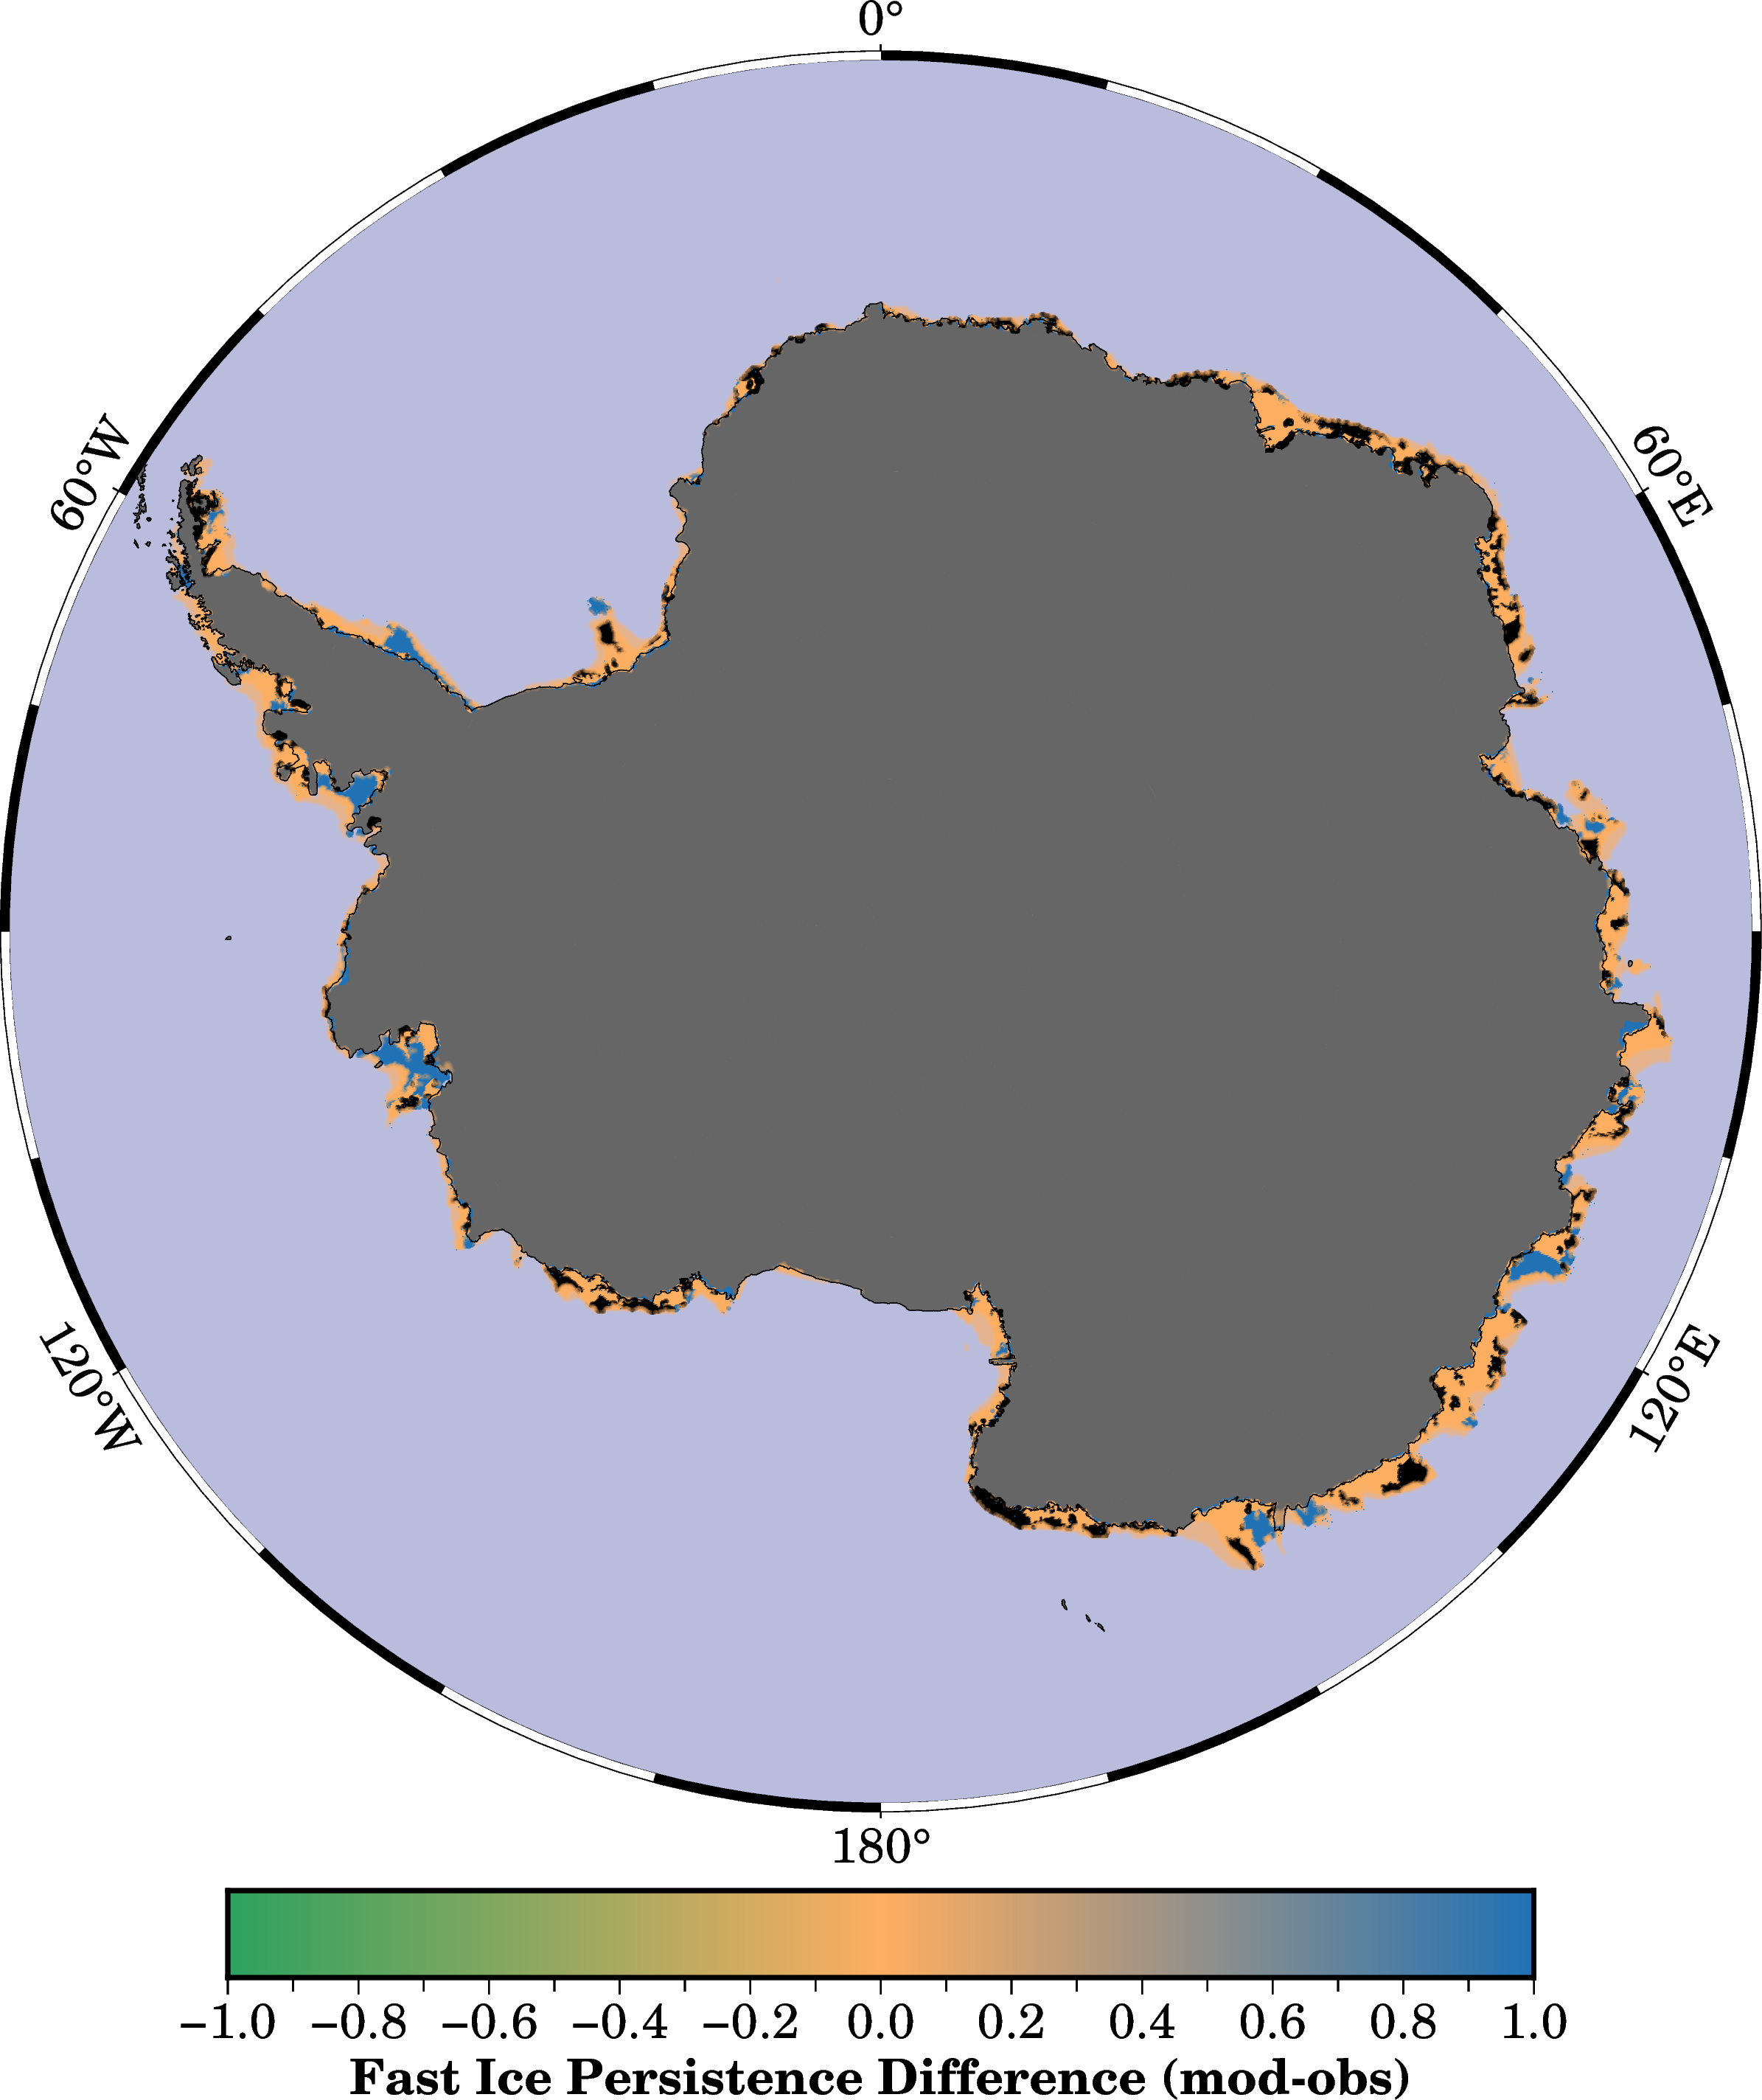

In [22]:
P_cpt      = tb.D_graph / "CPTs" / "FIPdiff_green_orange_blue.cpt"
tb.write_tricolour_cpt(P_cpt, vmin=-1, vmid=0, vmax=1)
#cmap       = "cmocean/curl"
G_pt_size  = "0.05"
fig_size   = 20
region     = [0,360,-90,-62]
P_obs      = tb.D_graph / "AF20" / "FIP_AF2020_reG_2000-2018.png"
P_mod      = tb.D_graph / sim_name / f"FIP_{sim_name}_reG_2000-2018.png"
P_diff     = tb.D_graph / sim_name / f"FIP-diff-cat_{sim_name}-AF2020_2000-2018.png"
frame_obs  = ["af",f"+tAF2020-reG 2000-2018"]
frame_mod  = ["af",f"+t{sim_name}-reG 2000-2018"]
frame_diff = ["af"]#,f"+t20"]
w          = tb.compute_fip_weight(FIP, mode="max", t=0.10, gamma=1.2)
fig        = tb.pygmt_FIP_figure(FIP['diff_cat'],
                                 mode          = "diff",
                                 color_mode    = "continuous",
                                 weight_da     = w,
                                 region        = region,
                                 cmap          = P_cpt,
                                 series        = [-1,1],
                                 G_pt_size     = G_pt_size,
                                 cbar_frame    = ["xa0.2f0.1+lFast Ice Persistence Difference (mod-obs)"],
                                 P_png         = P_diff,
                                 show_fig      = True,
                                 plot_GI       = True,
                                 GI_color      = "#0072B2",
                                 basemap_frame = frame_diff)
                                 #cat_series    = (0,1,2),
                                 #cat_labels    = ["union", "model-dominate", "observation-alone"])

#### by region

2026-03-11 22:25:23,714 - INFO - Grid previously loaded; returning.
2026-03-11 22:25:25,722 - INFO - [0, 0]
2026-03-11 22:25:25,724 - INFO - <contextlib._GeneratorContextManager object at 0x14a198343b30>
2026-03-11 22:25:26,401 - INFO - Grid previously loaded; returning.
2026-03-11 22:25:27,773 - INFO - [0, 1]
2026-03-11 22:25:27,776 - INFO - <contextlib._GeneratorContextManager object at 0x14a1a179f0b0>
2026-03-11 22:25:28,453 - INFO - Grid previously loaded; returning.
2026-03-11 22:25:28,669 - INFO - [1, 0]
2026-03-11 22:25:28,672 - INFO - <contextlib._GeneratorContextManager object at 0x14a1983c4ec0>
2026-03-11 22:25:29,301 - INFO - Grid previously loaded; returning.
2026-03-11 22:25:29,523 - INFO - [1, 1]
2026-03-11 22:25:29,525 - INFO - <contextlib._GeneratorContextManager object at 0x14a0e44450d0>


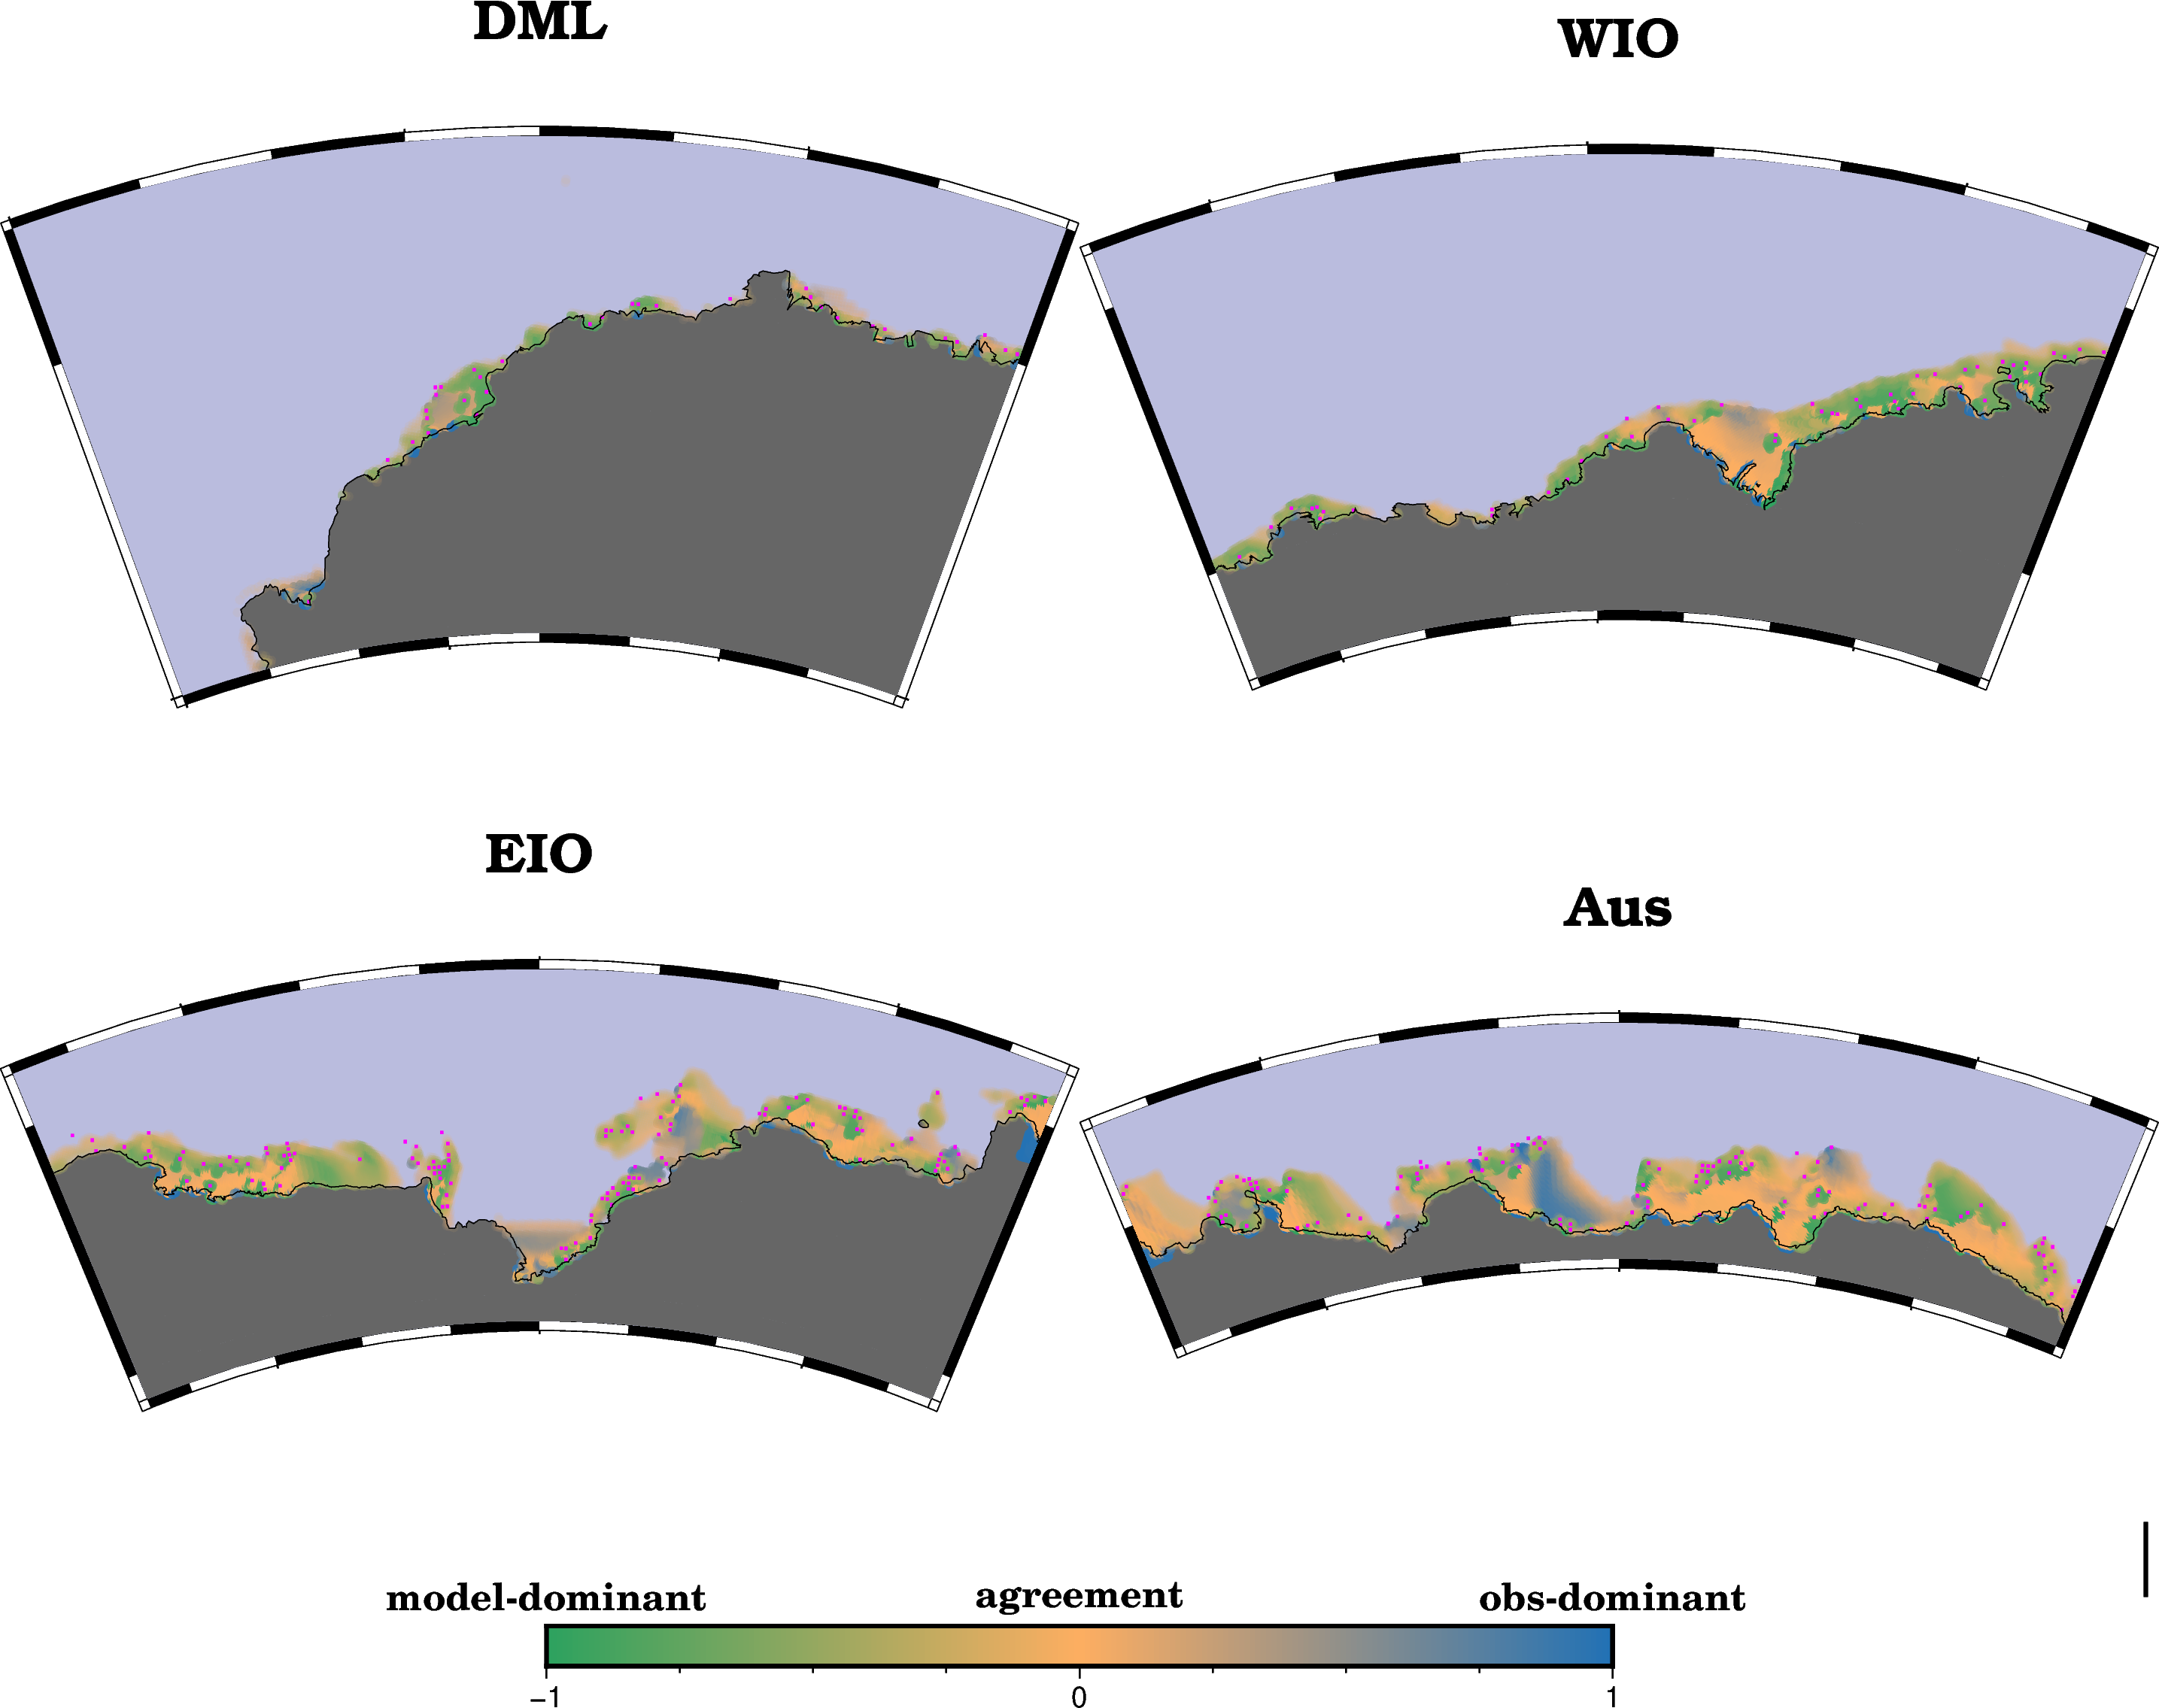

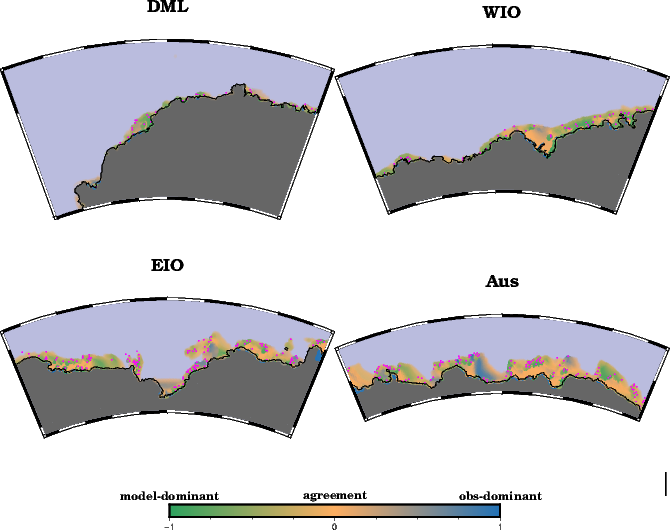

In [67]:
da_plot = FIP["diff"]
tb.pygmt_FIP_diff_four_panel(da_plot,
                             sector_names = ["DML", "WIO", "EIO", "Aus"],
                             weight_da    = w,
                             cbar_bframe  = 'e',
                             G_pt_size    = "0.10",
                             plot_GI      = True,
                             GI_color     = "#FB00FF",
                             GI_size      = "0.05",
                             P_png        = tb.D_graph / sim_name / "FIP_diff_fourpanel_1.png",
                             show_fig     = True)

2026-03-11 22:26:08,106 - INFO - Grid previously loaded; returning.
2026-03-11 22:26:08,337 - INFO - [0, 0]
2026-03-11 22:26:08,339 - INFO - <contextlib._GeneratorContextManager object at 0x14a1a01be8d0>
2026-03-11 22:26:09,058 - INFO - Grid previously loaded; returning.
2026-03-11 22:26:10,645 - INFO - [0, 1]
2026-03-11 22:26:10,647 - INFO - <contextlib._GeneratorContextManager object at 0x14a1ece573b0>
2026-03-11 22:26:11,323 - INFO - Grid previously loaded; returning.
2026-03-11 22:26:13,292 - INFO - [1, 0]
2026-03-11 22:26:13,294 - INFO - <contextlib._GeneratorContextManager object at 0x14a1a1596450>
2026-03-11 22:26:13,984 - INFO - Grid previously loaded; returning.
2026-03-11 22:26:15,630 - INFO - [1, 1]
2026-03-11 22:26:15,633 - INFO - <contextlib._GeneratorContextManager object at 0x14a1a1b90e00>


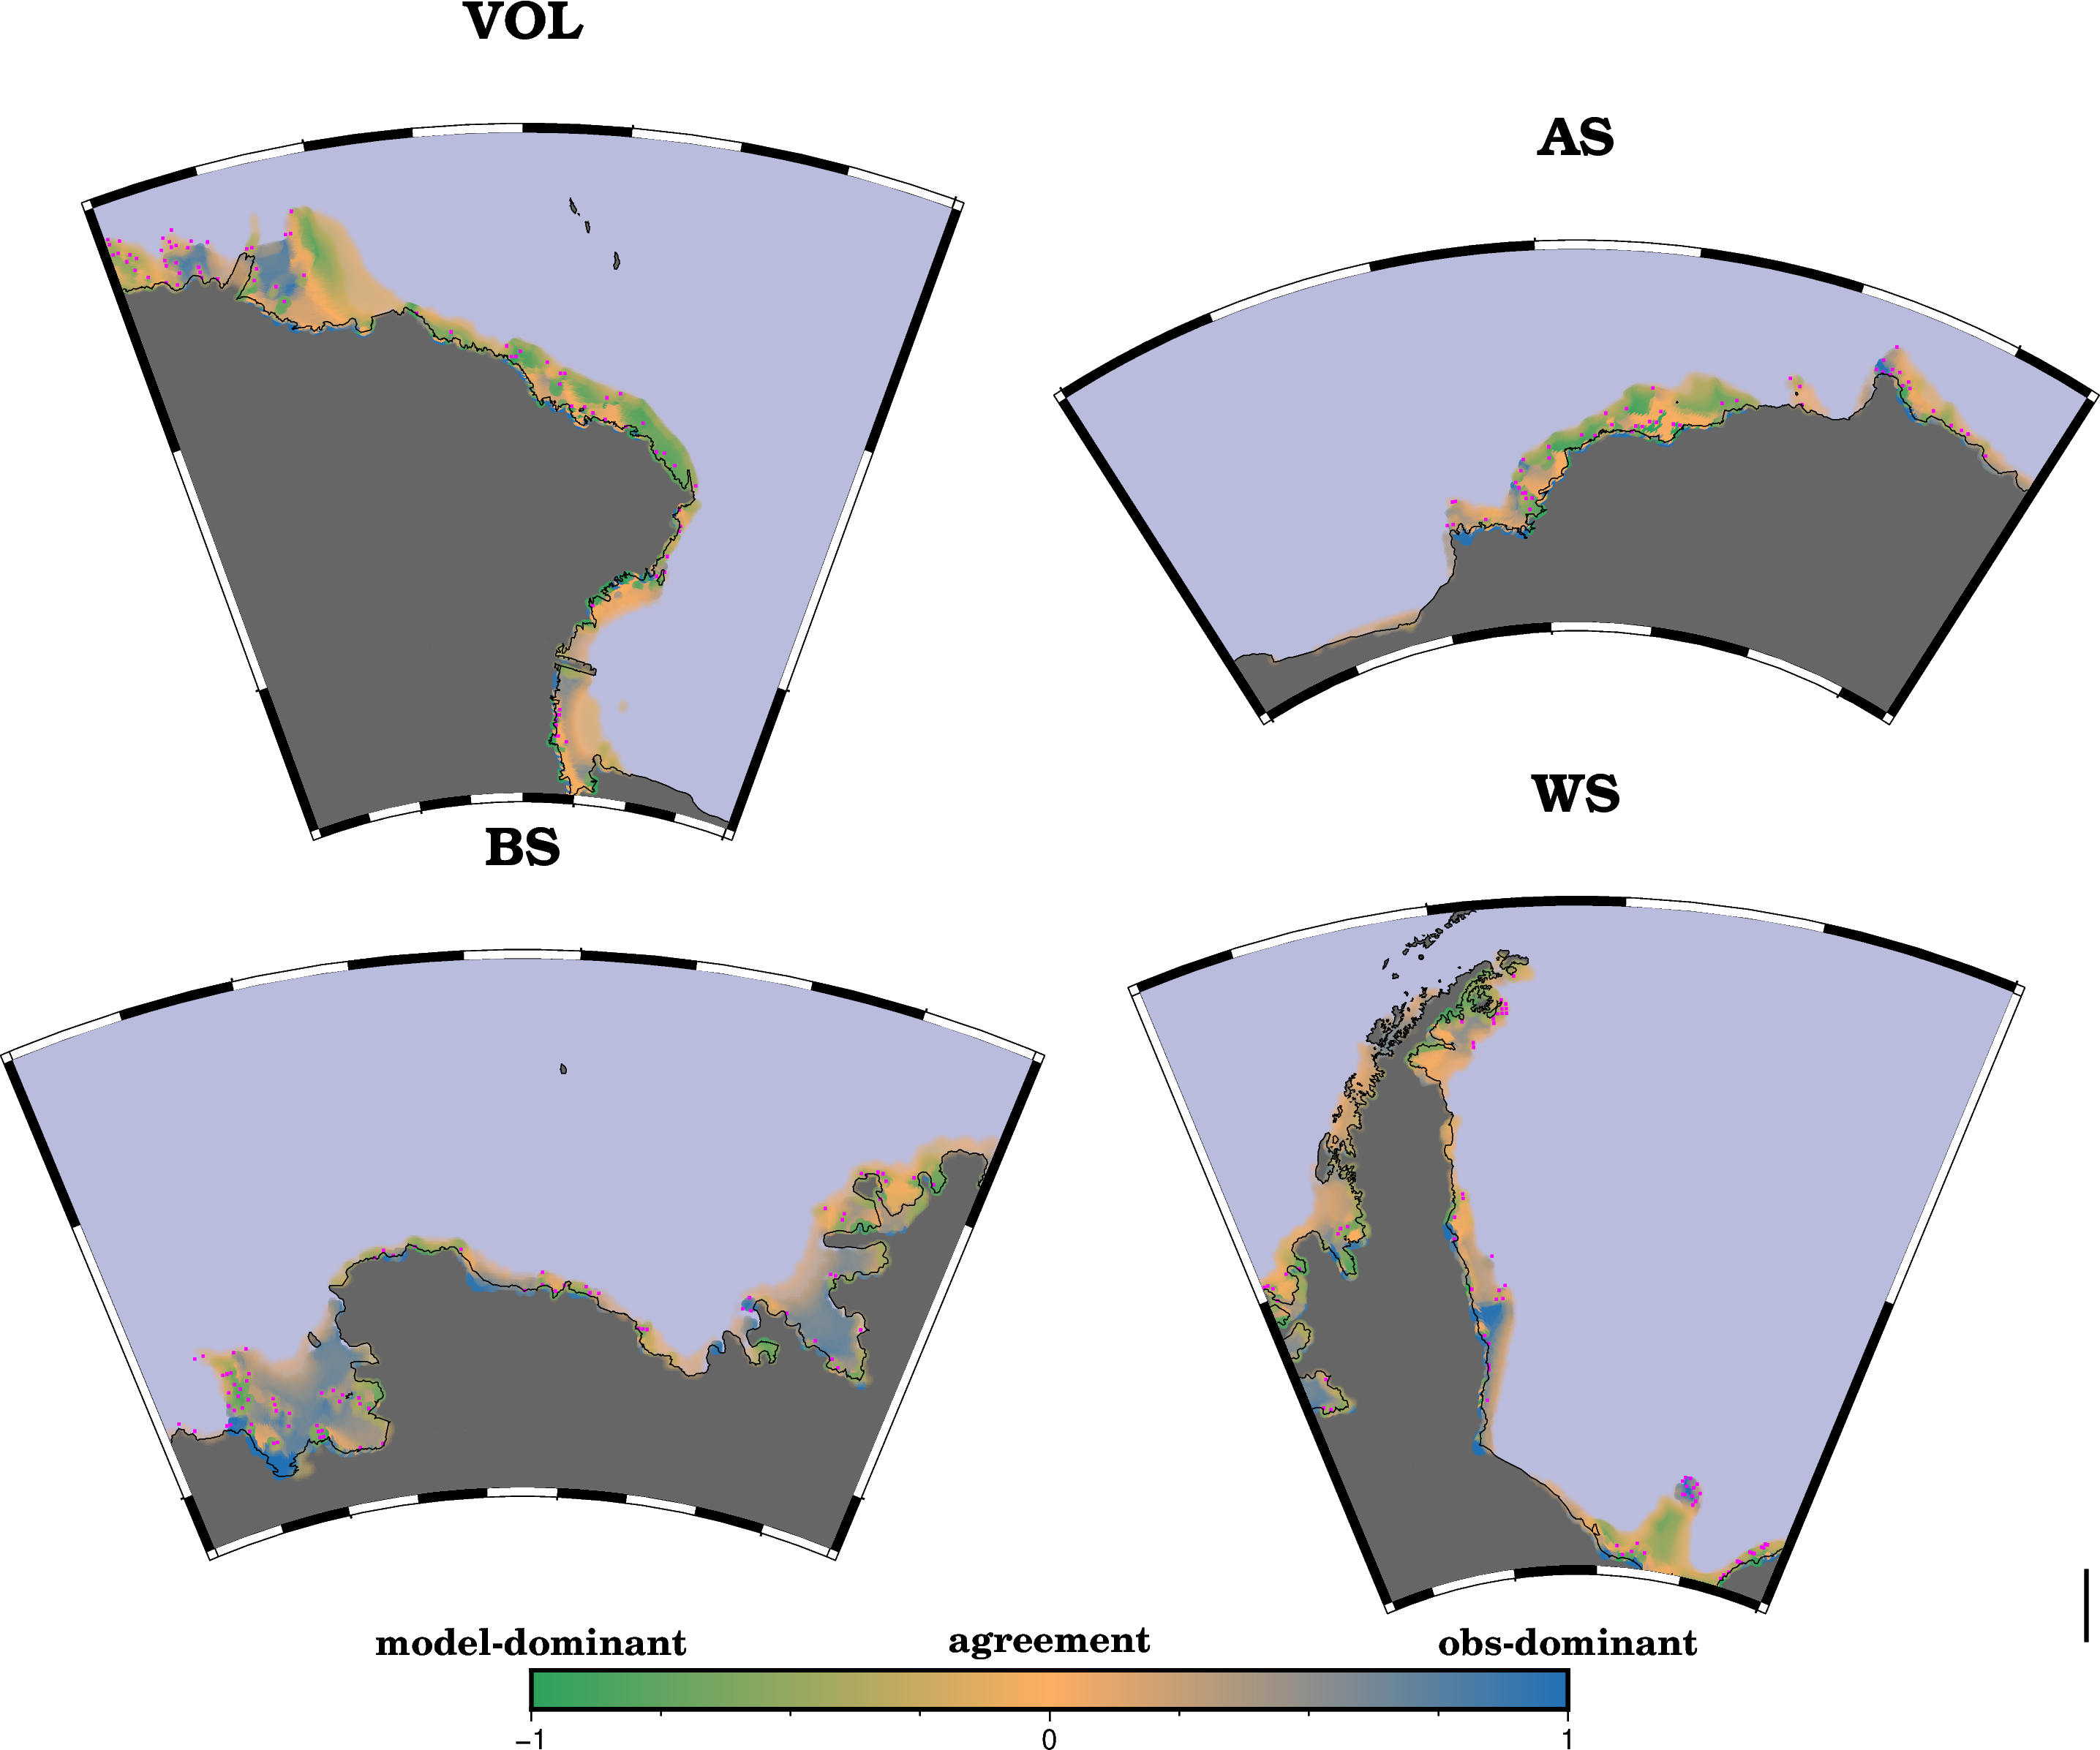

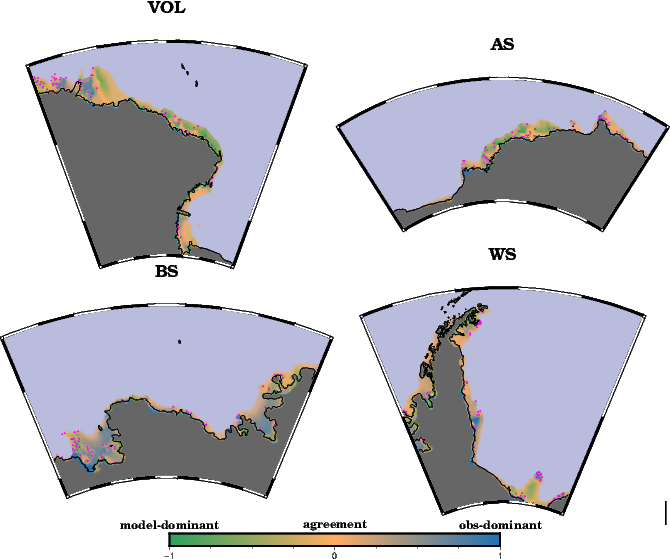

In [68]:
# Figure 2
tb.pygmt_FIP_diff_four_panel(da_plot,
                             sector_names = ["VOL", "AS", "BS", "WS"],
                             weight_da    = w,
                             cbar_bframe  = 'e',
                             G_pt_size    = "0.10",
                             margins      = ["0.20c","0.45c"],
                             plot_GI      = True,
                             GI_color     = "#FB00FF",
                             GI_size      = "0.05",
                             P_png        = tb.D_graph / sim_name / "FIP_diff_fourpanel_2.png",
                             show_fig     = True)

#### animation

In [ ]:
sim_name = "elps-min"
for region in SI_tools.Ant_8sectors.keys():
    SI_tools = SeaIceToolbox(sim_name=sim_name)
    D_png = Path(SI_tools.D_graph, sim_name, region, "FI_diff")
    D_ani = Path(SI_tools.D_graph, "animations", sim_name, "FI_diff")
    F_ani = f"{sim_name}_FI-diff_{region}_2000-2018.mp4"
    P_ani = Path(D_ani,F_ani)
    P_mp4 = Path.home() / "AFIM" / "src" / "AFIM" / "docs" / "figures" / F_ani
    D_ani.mkdir(parents=True, exist_ok=True)
    frames = sorted([f for f in os.listdir(D_png) if f.endswith(".png")])
    os.system(f"rm {SI_tools.D_tmp}/frame_*.png")
    for i, f in enumerate(frames):
        src = D_png / f
        dst = Path(SI_tools.D_tmp) / f"frame_{i:04d}.png"
        if not dst.exists():
            os.symlink(src, dst)
    os.system(f"ffmpeg -y -r 2 -i {SI_tools.D_tmp}/frame_%04d.png -vf \"scale=iw:ih+mod(2-ih\\,2)\" -c:v libx264 -pix_fmt yuv420p {P_ani}")
    os.system(f"cp {P_ani} {P_mp4}")
    

## Figure Interannual Variability

In [ ]:
FIA_dict    = {}
sim_name    = "elps-min"
dt0_str     = "2000-01-01"
dtN_str     = "2018-12-31"
P_log       = Path(Path.home(), "logs", "paper1_fastice_panel.log")
mgr         = SeaIceToolboxManager(P_log=P_log)
tb          = mgr.get_toolbox(sim_name       = sim_name,
                              dt0_str        = dt0_str,
                              dtN_str        = dtN_str,
                              ice_type       = "FI",
                              list_of_BorC2T = ['Tb'])
FIA_obs            = xr.open_dataset("/g/data/gv90/da1339/SeaIce/FI_obs/FIA_AF2020_daily.nc")["AF2020"]
FIA_dict['AF2020'] = {'FIA' : FIA_obs} # in 1e3-km^2
FIA_dict[sim_name] = {'FIA'   : tb.load_computed_metrics()['FIA']}
print(FIA_dict['AF2020']['FIA'])
print(FIA_dict[sim_name]['FIA'])

In [ ]:
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr
def _harmonise_time(da):
    # rename common coord
    if "date" in da.coords:
        da = da.rename({"date": "time"})
    # coerce to datetime64; drop NaT; sort
    t = pd.to_datetime(da["time"].values, errors="coerce")
    da = da.assign_coords(time=t)
    da = da.sel(time=~pd.isnull(da["time"]))
    da = da.sortby("time")
    return da

def annual_from_fortnight_ASMAR(da, agg="mean"):
    """
    Annual means over March–February years using AS-MAR (year starts Mar 1).
    Labels by the start year (e.g., 2000 = 2000-03-01..2001-02-28).
    """
    r = da.resample(time="YS-MAR")
    out = {"mean": r.mean, "max": r.max, "min": r.min}[agg]()
    s = out.to_series()
    s.index = s.index.year
    return s

In [ ]:
from scipy.stats import linregress
ANNUAL_AGG = "mean"
T0         = np.datetime64("2000-03-01")
T1         = np.datetime64("2018-03-01")  # exclusive end; gives full AS-MAR years 2000–2017
OUT        = "/g/data/gv90/da1339/GRAPHICAL/AFIM/elps-min/FIA_interannual_timeseries.png"
da_obs     = FIA_dict["AF2020"]["FIA"]
da_sim     = FIA_dict["elps-min"]["FIA"]
if "date" in da_obs.coords:
    da_obs = da_obs.rename({"date": "time"})
da_obs = da_obs.assign_coords(time=pd.to_datetime(da_obs["time"].values)).sortby("time")
da_sim = da_sim.assign_coords(time=pd.to_datetime(da_sim["time"].values)).sortby("time")
# Restrict to overlap window
da_obs = da_obs.sel(time=slice(T0, T1))
da_sim = da_sim.sel(time=slice(T0, T1))
da_obs = _harmonise_time(da_obs)
da_sim = _harmonise_time(da_sim)
# choose an overlap window that exists in BOTH series (prevents empty slices)
t0     = max(np.datetime64(T0), da_obs["time"].values.min(), da_sim["time"].values.min())
t1     = min(np.datetime64(T1), da_obs["time"].values.max(), da_sim["time"].values.max())
da_obs = da_obs.sel(time=slice(t0, t1))
da_sim = da_sim.sel(time=slice(t0, t1))
if da_sim.sizes.get("time", 0) == 0:
    raise RuntimeError(f"Sim series empty after harmonisation/slicing. "
                       f"Check sim time coverage and conversions. "
                       f"Requested window={T0}..{T1}, overlap window={t0}..{t1}.")
# now resample safely
obs_14d      = da_obs.resample(time="14D", label="left").mean()
sim_14d      = da_sim.resample(time="14D", label="left").mean()
yo           = annual_from_fortnight_ASMAR(obs_14d, ANNUAL_AGG)
ys           = annual_from_fortnight_ASMAR(sim_14d, ANNUAL_AGG)
yo_max       = annual_from_fortnight_ASMAR(obs_14d, "max")
ys_max       = annual_from_fortnight_ASMAR(sim_14d, "max")
yo_min       = annual_from_fortnight_ASMAR(obs_14d, "min")
ys_min       = annual_from_fortnight_ASMAR(sim_14d, "min")
years_max    = yo_max.index.intersection(ys_max.index)
years_min    = yo_min.index.intersection(ys_min.index)
r_max, p_max = pearsonr(yo_max.loc[years_max], ys_max.loc[years_max])
r_min, p_min = pearsonr(yo_min.loc[years_min], ys_min.loc[years_min])
years        = yo.index.intersection(ys.index)
yo           = yo.loc[years]
ys           = ys.loc[years]
trend_obs    = linregress(yo.index, yo.values)
trend_sim    = linregress(ys.index, ys.values)
# Anomalies (remove mean over overlap)
yo_anom      = yo - yo.mean()
ys_anom      = ys - ys.mean()
# Metrics on anomalies
r, p         = pearsonr(yo_anom.values, ys_anom.values)
rmse_anom    = float(np.sqrt(np.mean((ys_anom.values - yo_anom.values) ** 2)))
sigma_ratio  = float(ys_anom.std(ddof=1) / (yo_anom.std(ddof=1) + 1e-12))

In [ ]:
print({"years"      : (int(years.min()), int(years.max())),
       "N_years"    : int(len(years)),
       "r"          : float(r),
       "r2"         : float(r**2),
       "p"          : float(p),
       "rmse_anom"  : rmse_anom,
       "sigma_ratio": sigma_ratio,
       "obs_mean"   : float(yo.mean()),
       "sim_mean"   : float(ys.mean())})
print("Max FIA correlation:", r_max, "p=", p_max)
print("Min FIA correlation:", r_min, "p=", p_min)
print("sig_obs:", yo_anom.std(ddof=1))
print("sig_sim:", ys_anom.std(ddof=1))
print("Obs trend:", trend_obs.slope)
print("Sim trend:", trend_sim.slope)

### time series plot

In [ ]:
# Plot style
plt.rcParams.update({"figure.dpi"       : 120,
                     "savefig.dpi"      : 300,
                     "axes.spines.top"  : False,
                     "axes.spines.right": False,
                     "axes.grid"        : True,
                     "grid.alpha"       : 0.25,
                     "legend.frameon"   : False,
                     "axes.labelsize"   : 11,
                     "xtick.labelsize"  : 10,
                     "ytick.labelsize"  : 10})
unit    = r"×10$^{3}$ km$^{2}$"
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(yo.index, yo.values, marker="o", linewidth=1.8, label="AF2020 (obs)")
ax.plot(ys.index, ys.values, marker="s", linewidth=1.8, label="elps-min (sim)")
ax.set_xlabel("Year (Mar–Feb)")
ax.set_ylabel(f"Annual {ANNUAL_AGG} FIA ({unit})")
ax.legend(loc="lower left")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# Annotate skill (anomalies)
txt = (f"Anomaly skill (2000–2017)\n"
       f"r = {r:.2f}  (p = {p:.3f})\n"
       f"RMSE = {rmse_anom:.1f} {unit}\n"
       f"σ_sim/σ_obs = {sigma_ratio:.2f}")
ax.text(0.02, 0.98, txt, transform=ax.transAxes,
        va="top", ha="left", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))
fig.tight_layout()
plt.show()
fig.savefig(OUT, bbox_inches="tight")
plt.close(fig)
print("Saved:", OUT)

### taylor diagram

In [ ]:
obs = yo_anom.values
sim = ys_anom.values
# statistics
std_obs = np.std(obs, ddof=1)
std_sim = np.std(sim, ddof=1)
corr    = np.corrcoef(obs, sim)[0,1]
# convert correlation to angle
theta   = np.arccos(corr)
corr_ticks = np.array([0,0.2,0.4,0.6,0.8,0.9,1.0])
# figure
fig     = plt.figure(figsize=(6,6))
ax      = fig.add_subplot(111, polar=True)
# observation reference
#ax.plot(0, std_obs, 'ko', label='Observation')
# simulation point
ax.plot(theta, std_sim, 'bo')#, label='elps-min')
# axes formatting
ax.set_thetalim(0, np.pi/2)
ax.set_theta_direction(-1)
ax.set_theta_zero_location('E')
ax.set_xticks(np.arccos(corr_ticks))
ax.set_xticklabels(corr_ticks)
ax.set_rlabel_position(135)
plt.tight_layout()
#ax.legend()
plt.show()

# Appendix

## Grounded Icebergs

In [ ]:
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox2.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
SI_tools    = SI_tool_mgr.get_toolbox(dt0_str  = dt0_str,
                                      dtN_str  = dtN_str,
                                      sim_name = sim_name)
SI_tools.process_raw_grounded_iceberg_database()

In [ ]:
lon       = SI_tools.normalise_longitudes(SI_tools.G_t["lon"].values)
lat       = SI_tools.G_t["lat"].values
GI_cnts   = SI_tools.GI_cnts.values.astype(float)
mask      = (GI_cnts > 0) & np.isfinite(lon) & np.isfinite(lat) & (lat < -55)
print(np.shape(mask))
lon  = lon[mask]#.ravel()
lat  = lat[mask]#.ravel()
GI   = GI_cnts[mask]#.ravel()
print(np.shape(GI_cnts))
print(mask/GI_cnts)

In [ ]:
fig = pygmt.Figure()
fig.basemap(region=[-180,180,-90,-60], projection="S0/-90/14c", frame="g")
fig.coast(shorelines="0.25p,black", land="lightgray", water="white", resolution="i")
pygmt.makecpt(cmap="viridis", series=[1, 228])
fig.plot(x=lon_flat, y=lat_flat, style="s0.07c", fill=GI_cnts, cmap=True)
fig.colorbar(position="JBC+w12c/0.5c+o0/0.7c", frame='af+l"Grounded iceberg counts per cell"')
fig.show()

## Fast Ice Classification Method Comparison

In [29]:
#!/usr/bin/env python3
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pygmt

sys.path.insert(0, "/home/581/da1339/AFIM/src/AFIM/src")
from sea_ice_toolbox import SeaIceToolboxManager

DEFAULT_P_JSON = "/home/581/da1339/AFIM/src/AFIM/src/JSONs/sea_ice_config.json"


def scalar_from_ds(ds, varname):
    """
    Extract a scalar metric from a metrics dataset opened from mets.zarr.
    """
    if varname not in ds:
        raise KeyError(f"{varname} not found in dataset")
    da = ds[varname].squeeze(drop=True)
    return float(np.asarray(da.values).reshape(-1)[0])


def pareto_binary_days(df):
    """
    Pareto front for binary-days points:
      - minimise RMSE
      - maximise Corr

    Returns a boolean mask aligned to df.index.
    """
    out = pd.Series(False, index=df.index)

    d = df[df["method"].eq("bindays")].copy()
    if d.empty:
        return out

    # sort by RMSE ascending, Corr descending
    d = d.sort_values(["RMSE", "Corr"], ascending=[True, False])

    best_corr = -np.inf
    keep = []
    for _, r in d.iterrows():
        if r["Corr"] > best_corr:
            keep.append(True)
            best_corr = r["Corr"]
        else:
            keep.append(False)

    out.loc[d.index] = keep
    return out


# def estimate_label_box(text, xspan, yspan, fig_w_cm=12.0, fig_h_cm=8.0):
#     """
#     Approximate text-box size in data coordinates for collision avoidance.
#     """
#     # crude but good enough for publication plotting
#     char_w_cm = 0.11
#     pad_w_cm = 0.18
#     h_cm = 0.34

#     w_cm = pad_w_cm + char_w_cm * len(text)
#     w_data = w_cm * xspan / fig_w_cm
#     h_data = h_cm * yspan / fig_h_cm
#     return w_data, h_data


# def place_labels(df_annot, xmin, xmax, ymin, ymax, fig_w_cm=12.0, fig_h_cm=8.0):
#     """
#     Place labels using a small set of candidate offsets and reject overlaps.
#     Returns a list of dicts with x, y, xt, yt, text.
#     """
#     xspan = xmax - xmin
#     yspan = ymax - ymin

#     # candidate offsets in data units (scaled)
#     dx0 = 0.020 * xspan
#     dy0 = 0.025 * yspan
#     candidates = [
#         (+1.0, +1.0),
#         (-1.0, +1.0),
#         (+1.0, -1.0),
#         (-1.0, -1.0),
#         (+1.6,  0.0),
#         (-1.6,  0.0),
#         ( 0.0, +1.4),
#         ( 0.0, -1.4),
#         (+2.0, +1.2),
#         (-2.0, +1.2),
#         (+2.0, -1.2),
#         (-2.0, -1.2),
#     ]

#     # place hardest/crowded points first
#     work = df_annot.copy()
#     work = work.sort_values(["method", "Corr", "RMSE"], ascending=[True, False, True])

#     placed = []
#     occupied = []

#     for _, r in work.iterrows():
#         x = float(r["RMSE"])
#         y = float(r["Corr"])
#         text = str(r["short"])

#         w, h = estimate_label_box(text, xspan, yspan, fig_w_cm=fig_w_cm, fig_h_cm=fig_h_cm)

#         chosen = None
#         for sx, sy in candidates:
#             xt = x + sx * dx0
#             yt = y + sy * dy0

#             # clamp inside region with a tiny margin
#             xt = min(max(xt, xmin + 0.03 * xspan), xmax - 0.03 * xspan)
#             yt = min(max(yt, ymin + 0.03 * yspan), ymax - 0.03 * yspan)

#             # label bbox centered on (xt, yt)
#             box = (xt - 0.5 * w, xt + 0.5 * w, yt - 0.5 * h, yt + 0.5 * h)

#             overlap = False
#             for ob in occupied:
#                 if not (box[1] < ob[0] or box[0] > ob[1] or box[3] < ob[2] or box[2] > ob[3]):
#                     overlap = True
#                     break

#             if not overlap:
#                 chosen = (xt, yt, box)
#                 break

#         if chosen is None:
#             # fallback: put it above-right even if imperfect
#             xt = min(max(x + 2.8 * dx0, xmin + 0.03 * xspan), xmax - 0.03 * xspan)
#             yt = min(max(y + 2.2 * dy0, ymin + 0.03 * yspan), ymax - 0.03 * yspan)
#             box = (xt - 0.5 * w, xt + 0.5 * w, yt - 0.5 * h, yt + 0.5 * h)
#             chosen = (xt, yt, box)

#         xt, yt, box = chosen
#         occupied.append(box)
#         placed.append({
#             "x": x,
#             "y": y,
#             "xt": xt,
#             "yt": yt,
#             "text": text,
#             "method": r["method"],
#         })

#     return placed


def build_metrics_dataframe(tb, ice_type="FI", BorC2T_type="Tb", ispd_thresh=5e-4,
                            W_min=5, W_max=21):
    """
    Build DataFrame from load_computed_metrics() for:
      - rolling mean: P = 5..21
      - binary days: for each W, M = W-2, W-1, W
    """
    rows = []

    # rolling-mean
    for P in range(W_min, W_max + 1):
        try:
            ds = tb.load_computed_metrics(
                class_method="rolling-mean",
                ice_type=ice_type,
                BorC2T_type=BorC2T_type,
                ispd_thresh=ispd_thresh,
                mean_period=P,
                clip_to_self=False,
            )
            rows.append({
                "method": "rollmean",
                "W": np.nan,
                "M": np.nan,
                "P": P,
                "RMSE": scalar_from_ds(ds, "RMSE"),
                "Corr": scalar_from_ds(ds, "Corr"),
                "Bias": scalar_from_ds(ds, "Bias"),
                "short": f"R{P:02d}",
                "label": f"roll-days-{P:02d}",
            })
        except Exception as e:
            tb.logger.warning(f"Skipping roll-days-{P:02d}: {e}")

    # binary-days
    for W in range(W_min, W_max + 1):
        for M in range(max(1, W - 2), W + 1):
            try:
                ds = tb.load_computed_metrics(
                    class_method="binary-days",
                    ice_type=ice_type,
                    BorC2T_type=BorC2T_type,
                    ispd_thresh=ispd_thresh,
                    bin_win_days=W,
                    bin_min_days=M,
                    mean_period=W,   # not used by path for binary-days, but harmless if your method accepts it
                    clip_to_self=False,
                )
                rows.append({
                    "method": "bindays",
                    "W": W,
                    "M": M,
                    "P": W,
                    "RMSE": scalar_from_ds(ds, "RMSE"),
                    "Corr": scalar_from_ds(ds, "Corr"),
                    "Bias": scalar_from_ds(ds, "Bias"),
                    "short": f"B{W:02d}/{M:02d}",
                    "label": f"bin-win-{W:02d}_bin-min-{M:02d}",
                })
            except Exception as e:
                tb.logger.warning(f"Skipping bin-win-{W:02d}_bin-min-{M:02d}: {e}")

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No metrics were loaded; DataFrame is empty.")

    df["abs_bias"] = df["Bias"].abs()
    df["pareto"] = pareto_binary_days(df)
    return df
    
def pareto_figure(df, P_png, annotations=None):
    """
    Plot RMSE vs correlation for binary-days and rolling-mean experiments.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns:
        ['RMSE', 'Corr', 'abs_bias', 'method', 'short'].
        Expected method values are 'bindays' and 'rollmean'.
    P_png : str or pathlib.Path
        Output figure path.
    annotations : dict[str, tuple[float, float]], optional
        Mapping from point label (df['short']) to annotation offset in data units:
        {label: (dx_rmse, dy_corr)}.
    """
    import numpy as np
    import pygmt

    fig = pygmt.Figure()

    # ------------------------------------------------------------------
    # region / symbol sizing
    # ------------------------------------------------------------------
    x = df["RMSE"].to_numpy(dtype=float)
    y = df["Corr"].to_numpy(dtype=float)
    b = df["abs_bias"].to_numpy(dtype=float)

    if np.nanmax(b) > 0:
        size = 0.18 + 0.18 * np.sqrt(b / np.nanmax(b))
    else:
        size = np.full_like(b, 0.22, dtype=float)

    xpad = max(2.0, 0.06 * (x.max() - x.min()))
    ypad = max(0.02, 0.08 * (y.max() - y.min()))

    xmin = float(x.min()) - xpad
    xmax = float(x.max()) + xpad
    ymin = max(0.0, float(y.min()) - ypad)
    ymax = min(1.0, float(y.max()) + ypad)

    # ------------------------------------------------------------------
    # default hand-tuned annotation offsets (data units)
    # ------------------------------------------------------------------
    if annotations is None:
        annotations = {
            # binary-days
            "B05/03": ( 1.2,  0.013),
            "B09/07": ( 15,  -0.05),
            "B10/08": ( 2.6,  0.05),
            "B11/09": ( 2.2,  -0.05),

            # rolling-mean
            "R05": ( 1.0,  0.010),
            "R06": ( 0.9,  0.004),
            "R07": (-1.0, -0.004),
            "R15": ( 2.1,  0.010),
            "R20": ( 2.3,  0.008),
            "R21": (-1.4, -0.020),
        }

    # ------------------------------------------------------------------
    # plot
    # ------------------------------------------------------------------
    with pygmt.config(
        MAP_FRAME_TYPE="plain",
        MAP_GRID_PEN_PRIMARY="0.25p,gray85",
        MAP_TICK_PEN_PRIMARY="0.8p,black",
        MAP_TICK_LENGTH_PRIMARY="0.10c",
        FONT_ANNOT_PRIMARY="10p,Helvetica,black",
        FONT_LABEL="11p,Helvetica,black",
        FONT_TITLE="12p,Helvetica-Bold,black",
    ):
        fig.basemap(
            region=[xmin, xmax, ymin, ymax],
            projection="X12c/8c",
            frame=[
                "WS",
                "xa10f5g10+lRMSE (elps-min vs AF2020)",
                "ya0.05f0.01g0.05+lCorrelation (elps-min vs AF2020)",
            ],
        )

        # binary-days
        mask_bin = df["method"].eq("bindays").to_numpy()
        fig.plot(
            x=df.loc[mask_bin, "RMSE"],
            y=df.loc[mask_bin, "Corr"],
            style="c0.2",
            fill="#5B8FD6",
            label="binary-days",
        )

        # rolling-mean
        mask_roll = df["method"].eq("rollmean").to_numpy()
        fig.plot(
            x=df.loc[mask_roll, "RMSE"],
            y=df.loc[mask_roll, "Corr"],
            style="s0.2",
            fill="#D9B84A",
            label="rolling-mean",
        )

        fig.legend(
            position="JBL+jBL+o0.2c",
            box="+gwhite+p0.8p",
        )

        # --------------------------------------------------------------
        # annotation leader lines + text
        # --------------------------------------------------------------
        for label, (dx, dy) in annotations.items():
            row = df.loc[df["short"].eq(label)]
            if row.empty:
                continue

            row = row.iloc[0]
            x0 = float(row["RMSE"])
            y0 = float(row["Corr"])
            xt = x0 + dx
            yt = y0 + dy

            fig.plot(
                x=[x0, xt],
                y=[y0, yt],
                pen="0.35p,gray45",
            )

            justify = "RM"#"M" if dx >= 0 else "RM"

            fig.text(
                x=xt,
                y=yt,
                text=label,
                font="8p,Helvetica,black",
                justify=justify,
                fill="white@70",
                pen="0.25p,gray50",
                clearance="0.05c/0.03c",
                no_clip=True,
            )

    fig.savefig(P_png, dpi=600)
    return fig

In [3]:
P_log = Path.home() / "logs" / "FIA_pareto_publication.log"
mgr   = SeaIceToolboxManager(P_log     = P_log,
                             n_workers = 1,
                             n_threads = 4,
                             mem_lim   = "16GB",
                             process   = False,
                             D_dask    = os.environ.get("DASK_TEMPORARY_DIRECTORY",
                                                        f"/scratch/gv90/{os.environ.get('USER', 'da1339')}/dask_tmp"))
tb = mgr.get_toolbox(P_json              = DEFAULT_P_JSON,
                     sim_name            = "elps-min",
                     dt0_str             = "1994-01-01",
                     dtN_str             = "2023-12-31",
                     ice_type            = "FI",
                     list_of_BorC2T      = ["Tb"],
                     ice_speed_threshold = 5e-4)
df = build_metrics_dataframe(tb,
                             ice_type    = "FI",
                             BorC2T_type = "Tb",
                             ispd_thresh = 5e-4,
                             W_min       = 5,
                             W_max       = 21)

2026-03-14 09:22:09,849 - INFO - log file connected: /home/581/da1339/logs/FIA_pareto_publication.log
2026-03-14 09:22:09,853 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [4]
  Total Memory   : 16.00 GB

2026-03-14 09:22:09,854 - INFO - hemisphere initialised: SH
2026-03-14 09:22:09,856 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-14 09:22:09,859 - INFO - --- SeaIceToolbox Summary ---
2026-03-14 09:22:09,860 - INFO - Simulation Name     : elps-min
2026-03-14 09:22:09,861 - INFO - Analysis Start Date : 1994-01-01
2026-03-14 09:22:09,862 - INFO - Analysis End Date   : 2023-12-31
2026-03-14 09:22:09,864 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-14 09:22:09,865 - INFO - landmask file       : /g/data/gv90/da1339/grids/ACCESS-OM2-025_kmt.nc
2026-03-14 09:22:09,866 - 

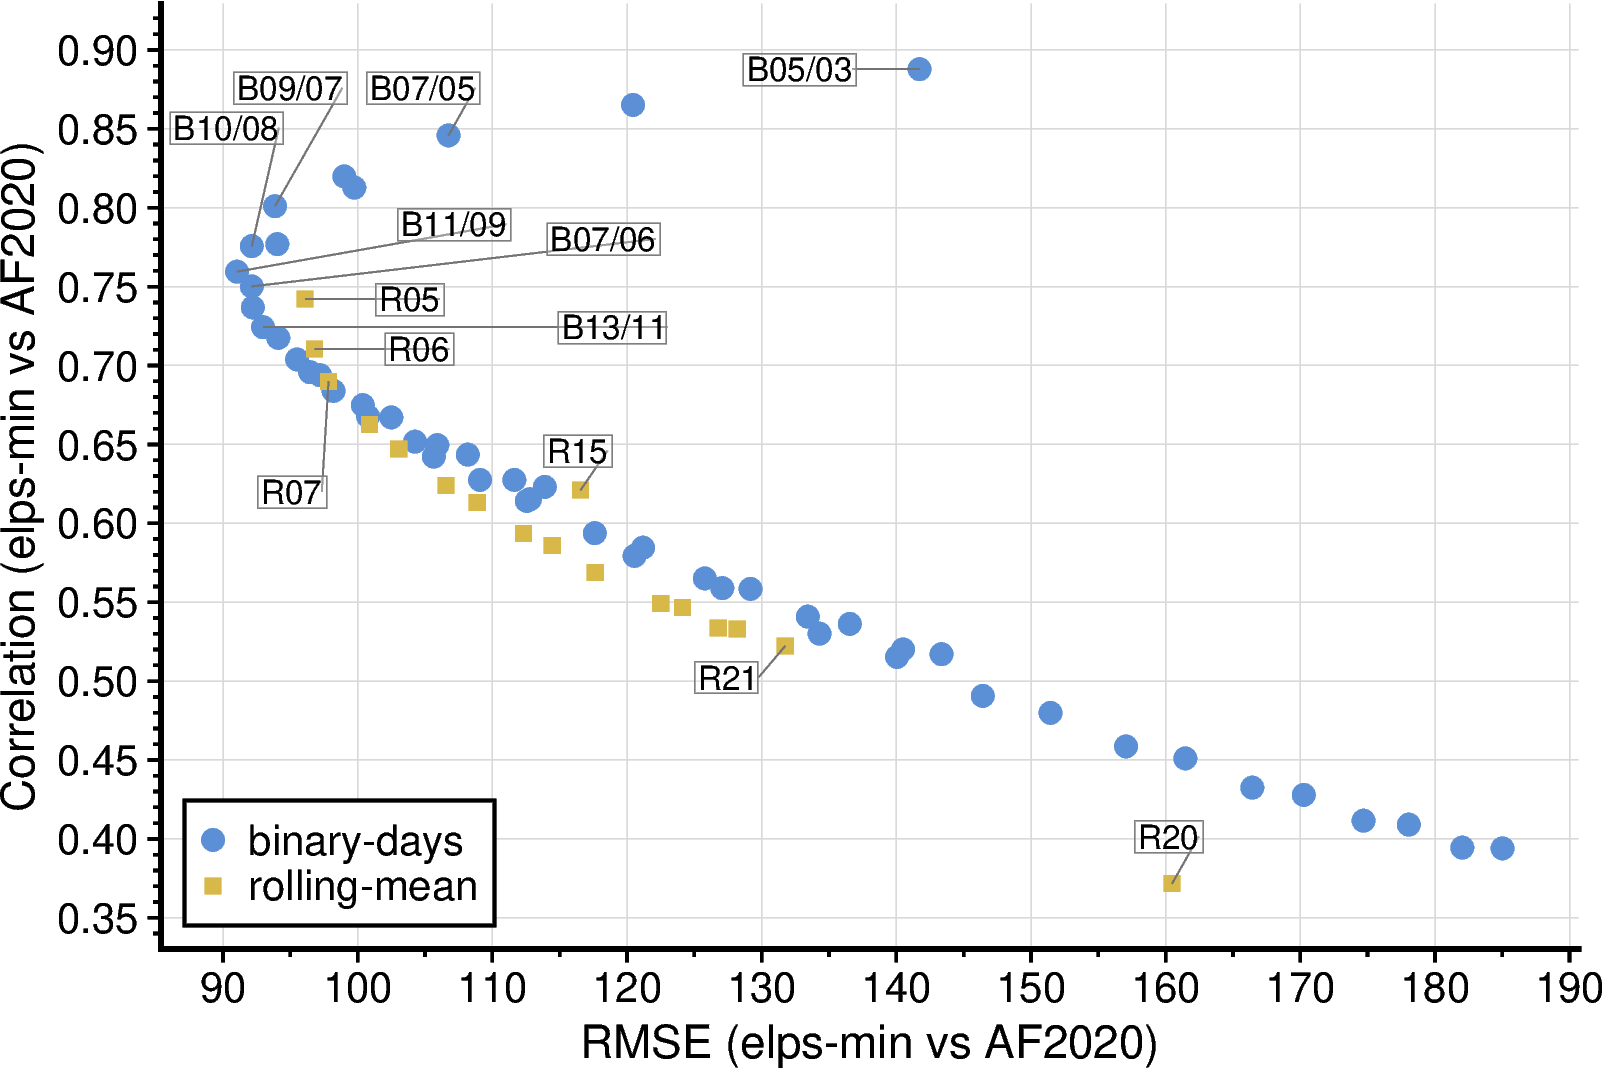

Wrote /home/581/da1339/graphical/AFIM/elps-min/FIA_pareto_bin_vs_roll_1994_1999_publication.png


In [96]:
P_png = Path.home() / "graphical" / "AFIM" / "elps-min" / "FIA_pareto_bin_vs_roll_1994_1999_publication.png"
P_png.parent.mkdir(parents=True, exist_ok=True)
annotations = {
    # binary-days
    "B05/03": ( -5,  0),
    "B07/05": ( 2, 0.03),
    "B09/07": ( 5, 0.075),
    "B10/08": ( 2,  0.075),
    "B13/11": ( 30, 0),
    "B07/06": ( 30 , 0.03),
    "B11/09": ( 20, 0.03),
    # rolling-mean
    "R05": ( 10.0, 0.0),
    "R06": ( 10.0, 0.0),
    "R07": (-0.5, -0.07),
    "R14": ( 
    "R15": ( 2,  0.025),
    "R20": ( 2,  0.03),
    "R21": (-2, -0.020),
}
fig = pareto_figure(df, P_png, annotations=annotations)
fig.show()
print(f"Wrote {P_png}")

## Justification for Ice Speed Threshold

In [3]:
VAR_MAX    = "FIA_Maximum Mean"
VAR_MIN    = "FIA_Minimum Mean"
MAX_STD    = "FIA_Maximum Std"
MIN_STD    = "FIA_Minimum Std"
T_LIST     = [1.0e-6, 3.0e-6, 5.0e-6, 7.0e-6, 9.0e-6,
              1.0e-5, 3.0e-5, 5.0e-5, 7.0e-5, 9.0e-5,
              1.0e-4, 3.0e-4, 5.0e-4, 7.0e-4, 9.0e-4,
              1.0e-3, 3.0e-3, 5.0e-3, 7.0e-3, 9.0e-3,
              1.0e-2, 3.0e-2, 5.0e-2, 7.0e-2, 9.0e-2]
OBS_MIN    = 221
OBS_MAX    = 601
BETA_MAIN  = 5.0e-4
BETA_ANNOT = None
YMIN, YMAX = 60, 800
sim_name   = "elps-min"
OUTPNG     = Path.home() / "graphical/AFIM" / sim_name / "ispd-thresh_vs_FIA-min-max_pygmt.png"
dt0_str    = "1994-01-01"
dtN_str    = "1999-12-31"
P_log      = Path(Path.home(), "logs", "paper1_justification_ispd_thresh.log")
mgr        = SeaIceToolboxManager(P_log=P_log)
t_bin, t_roll              = [], []
max_bin, min_bin           = [], []
max_std_bin, min_std_bin   = [], []
max_roll, min_roll         = [], []
max_std_roll, min_std_roll = [], []
for class_method in ["binary-days","rolling-mean"]:
    for ispd_thresh in T_LIST:
        tb   = mgr.get_toolbox(sim_name            = sim_name,
                               dt0_str             = dt0_str,
                               dtN_str             = dtN_str,
                               ice_type            = "FI",
                               list_of_BorC2T      = ['Tb'],
                               ice_speed_threshold = ispd_thresh)
        mets = tb.load_computed_metrics(class_method=class_method)
        print(mets[VAR_MAX])
        print(mets[VAR_MIN])
        if class_method=="binary-days":
            t_bin.append(ispd_thresh)
            max_bin.append(mets[VAR_MAX])
            max_std_bin.append(mets[MAX_STD])
            min_bin.append(mets[VAR_MIN])
            min_std_bin.append(mets[MIN_STD])
        else:
            t_roll.append(ispd_thresh)
            max_roll.append(mets[VAR_MAX])
            max_std_roll.append(mets[MAX_STD])
            min_roll.append(mets[VAR_MIN])
            min_std_roll.append(mets[MIN_STD])
# convert to arrays
t_bin         = np.asarray(t_bin, dtype=float)
max_bin       = np.asarray(max_bin, dtype=float)
max_std_bin   = np.asarray(max_std_bin, dtype=float)
min_bin       = np.asarray(min_bin, dtype=float)
min_std_bin   = np.asarray(min_std_bin, dtype=float)
t_roll        = np.asarray(t_roll, dtype=float)
max_roll      = np.asarray(max_roll, dtype=float)
max_std_roll  = np.asarray(max_std_roll, dtype=float)
min_roll      = np.asarray(min_roll, dtype=float)
min_std_roll  = np.asarray(min_std_roll, dtype=float)

2026-03-12 08:38:24,020 - INFO - log file connected: /home/581/da1339/logs/paper1_justification_ispd_thresh.log
2026-03-12 08:38:24,056 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 08:38:24,058 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 08:38:24,060 - INFO - hemisphere initialised: SH
2026-03-12 08:38:24,061 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 08:38:24,062 - INFO - Simulation Name     : elps-min
2026-03-12 08:38:24,064 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 08:38:24,065 - INFO - Analysis End Date   : 1999-12-31
2026-03-12 08:38:24,066 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-12 08:38:24,067 - INFO - landmask file       : /g/data/gv90/da1339/grids/ACCESS-OM2-025_kmt.nc
2026-03

<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]


2026-03-12 08:38:27,168 - INFO - 	subsetting and padding time
2026-03-12 08:38:27,178 - INFO - log file connected: /home/581/da1339/logs/paper1_justification_ispd_thresh.log
2026-03-12 08:38:27,185 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 08:38:27,186 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 08:38:27,188 - INFO - hemisphere initialised: SH
2026-03-12 08:38:27,189 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 08:38:27,190 - INFO - Simulation Name     : elps-min
2026-03-12 08:38:27,191 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 08:38:27,192 - INFO - Analysis End Date   : 1999-12-31
2026-03-12 08:38:27,193 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-12 08:38:27,194 - INFO - landmask file  

<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]


2026-03-12 08:38:27,449 - INFO - 	subsetting and padding time
2026-03-12 08:38:27,460 - INFO - log file connected: /home/581/da1339/logs/paper1_justification_ispd_thresh.log
2026-03-12 08:38:27,475 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 08:38:27,476 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 08:38:27,478 - INFO - hemisphere initialised: SH
2026-03-12 08:38:27,479 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 08:38:27,480 - INFO - Simulation Name     : elps-min
2026-03-12 08:38:27,480 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 08:38:27,481 - INFO - Analysis End Date   : 1999-12-31
2026-03-12 08:38:27,482 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-12 08:38:27,483 - INFO - landmask file  

...

<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]


2026-03-12 08:38:32,792 - INFO - 	subsetting and padding time
2026-03-12 08:38:32,855 - INFO - log file connected: /home/581/da1339/logs/paper1_justification_ispd_thresh.log
2026-03-12 08:38:32,861 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 08:38:32,863 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 08:38:32,865 - INFO - hemisphere initialised: SH
2026-03-12 08:38:32,866 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 08:38:32,867 - INFO - Simulation Name     : elps-min
2026-03-12 08:38:32,868 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 08:38:32,869 - INFO - Analysis End Date   : 1999-12-31
2026-03-12 08:38:32,871 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-12 08:38:32,872 - INFO - landmask file  

<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]


2026-03-12 08:38:33,016 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-12 08:38:33,017 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-12 08:38:33,019 - INFO - hemisphere initialised: SH
2026-03-12 08:38:33,020 - INFO - --- SeaIceToolbox Summary ---
2026-03-12 08:38:33,021 - INFO - Simulation Name     : elps-min
2026-03-12 08:38:33,023 - INFO - Analysis Start Date : 1994-01-01
2026-03-12 08:38:33,023 - INFO - Analysis End Date   : 1999-12-31
2026-03-12 08:38:33,024 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-12 08:38:33,025 - INFO - landmask file       : /g/data/gv90/da1339/grids/ACCESS-OM2-025_kmt.nc
2026-03-12 08:38:33,026 - INFO - Using GI?           : True
2026-03-12 08:38:33,027 - INFO - modified landmask file: /g

<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Maximum Mean' ()> Size: 8B
[1 values with dtype=float64]
<xarray.DataArray 'FIA_Minimum Mean' ()> Size: 8B
[1 values with dtype=float64]


### helper for shaded bands

In [4]:
max_bin

array([  66.85418091,   69.41696014,   77.5105835 ,   91.362677  ,
        106.48132172,  113.95448303,  222.56740723,  293.95625   ,
        345.03343506,  383.53544922,  400.30004883,  568.21140137,
        639.3545166 ,  681.14993896,  708.57384033,  719.08076172,
        811.00689697,  839.79581299,  872.18068848,  900.82120361,
        918.24951172, 1182.11580811, 1552.13210449, 2115.45959473,
       2716.76560059])

In [5]:
def band_polygon(x, y, ystd):
    y_lo = y - ystd
    y_hi = y + ystd
    xpoly = np.r_[x, x[::-1]]
    ypoly = np.r_[y_hi, y_lo[::-1]]
    return xpoly, ypoly

### figure setup colours and pens

In [6]:
# pens
BIN_COL   = "0/114/178"   # blue
ROLL_COL  = "213/94/0"    # vermillion
GREY_COL  = "140"
BLACK_COL = "0"
# mean curves
PEN_BIN_MAX   = f"2.4p,{BIN_COL}"
PEN_BIN_MIN   = f"2.4p,{BIN_COL},10_3_2_3:0p"
PEN_ROLL_MAX  = f"2.4p,{ROLL_COL}"
PEN_ROLL_MIN  = f"2.4p,{ROLL_COL},10_3_2_3:0p"
# references
PEN_OBS       = f"1.2p,{BLACK_COL},6_3:0p"
PEN_JF        = f"1.2p,{GREY_COL},10_4:0p"
PEN_VBIN      = f"1.0p,{BIN_COL},1_3:0p"
PEN_VROLL     = f"1.0p,{ROLL_COL},1_3:0p"
# shaded envelopes
ALPHA_BAND = 78  # higher = more transparent
x_all      = np.r_[t_bin, t_roll] if t_roll.size else t_bin
xmin, xmax = float(np.nanmin(x_all)), float(np.nanmax(x_all))

### plot

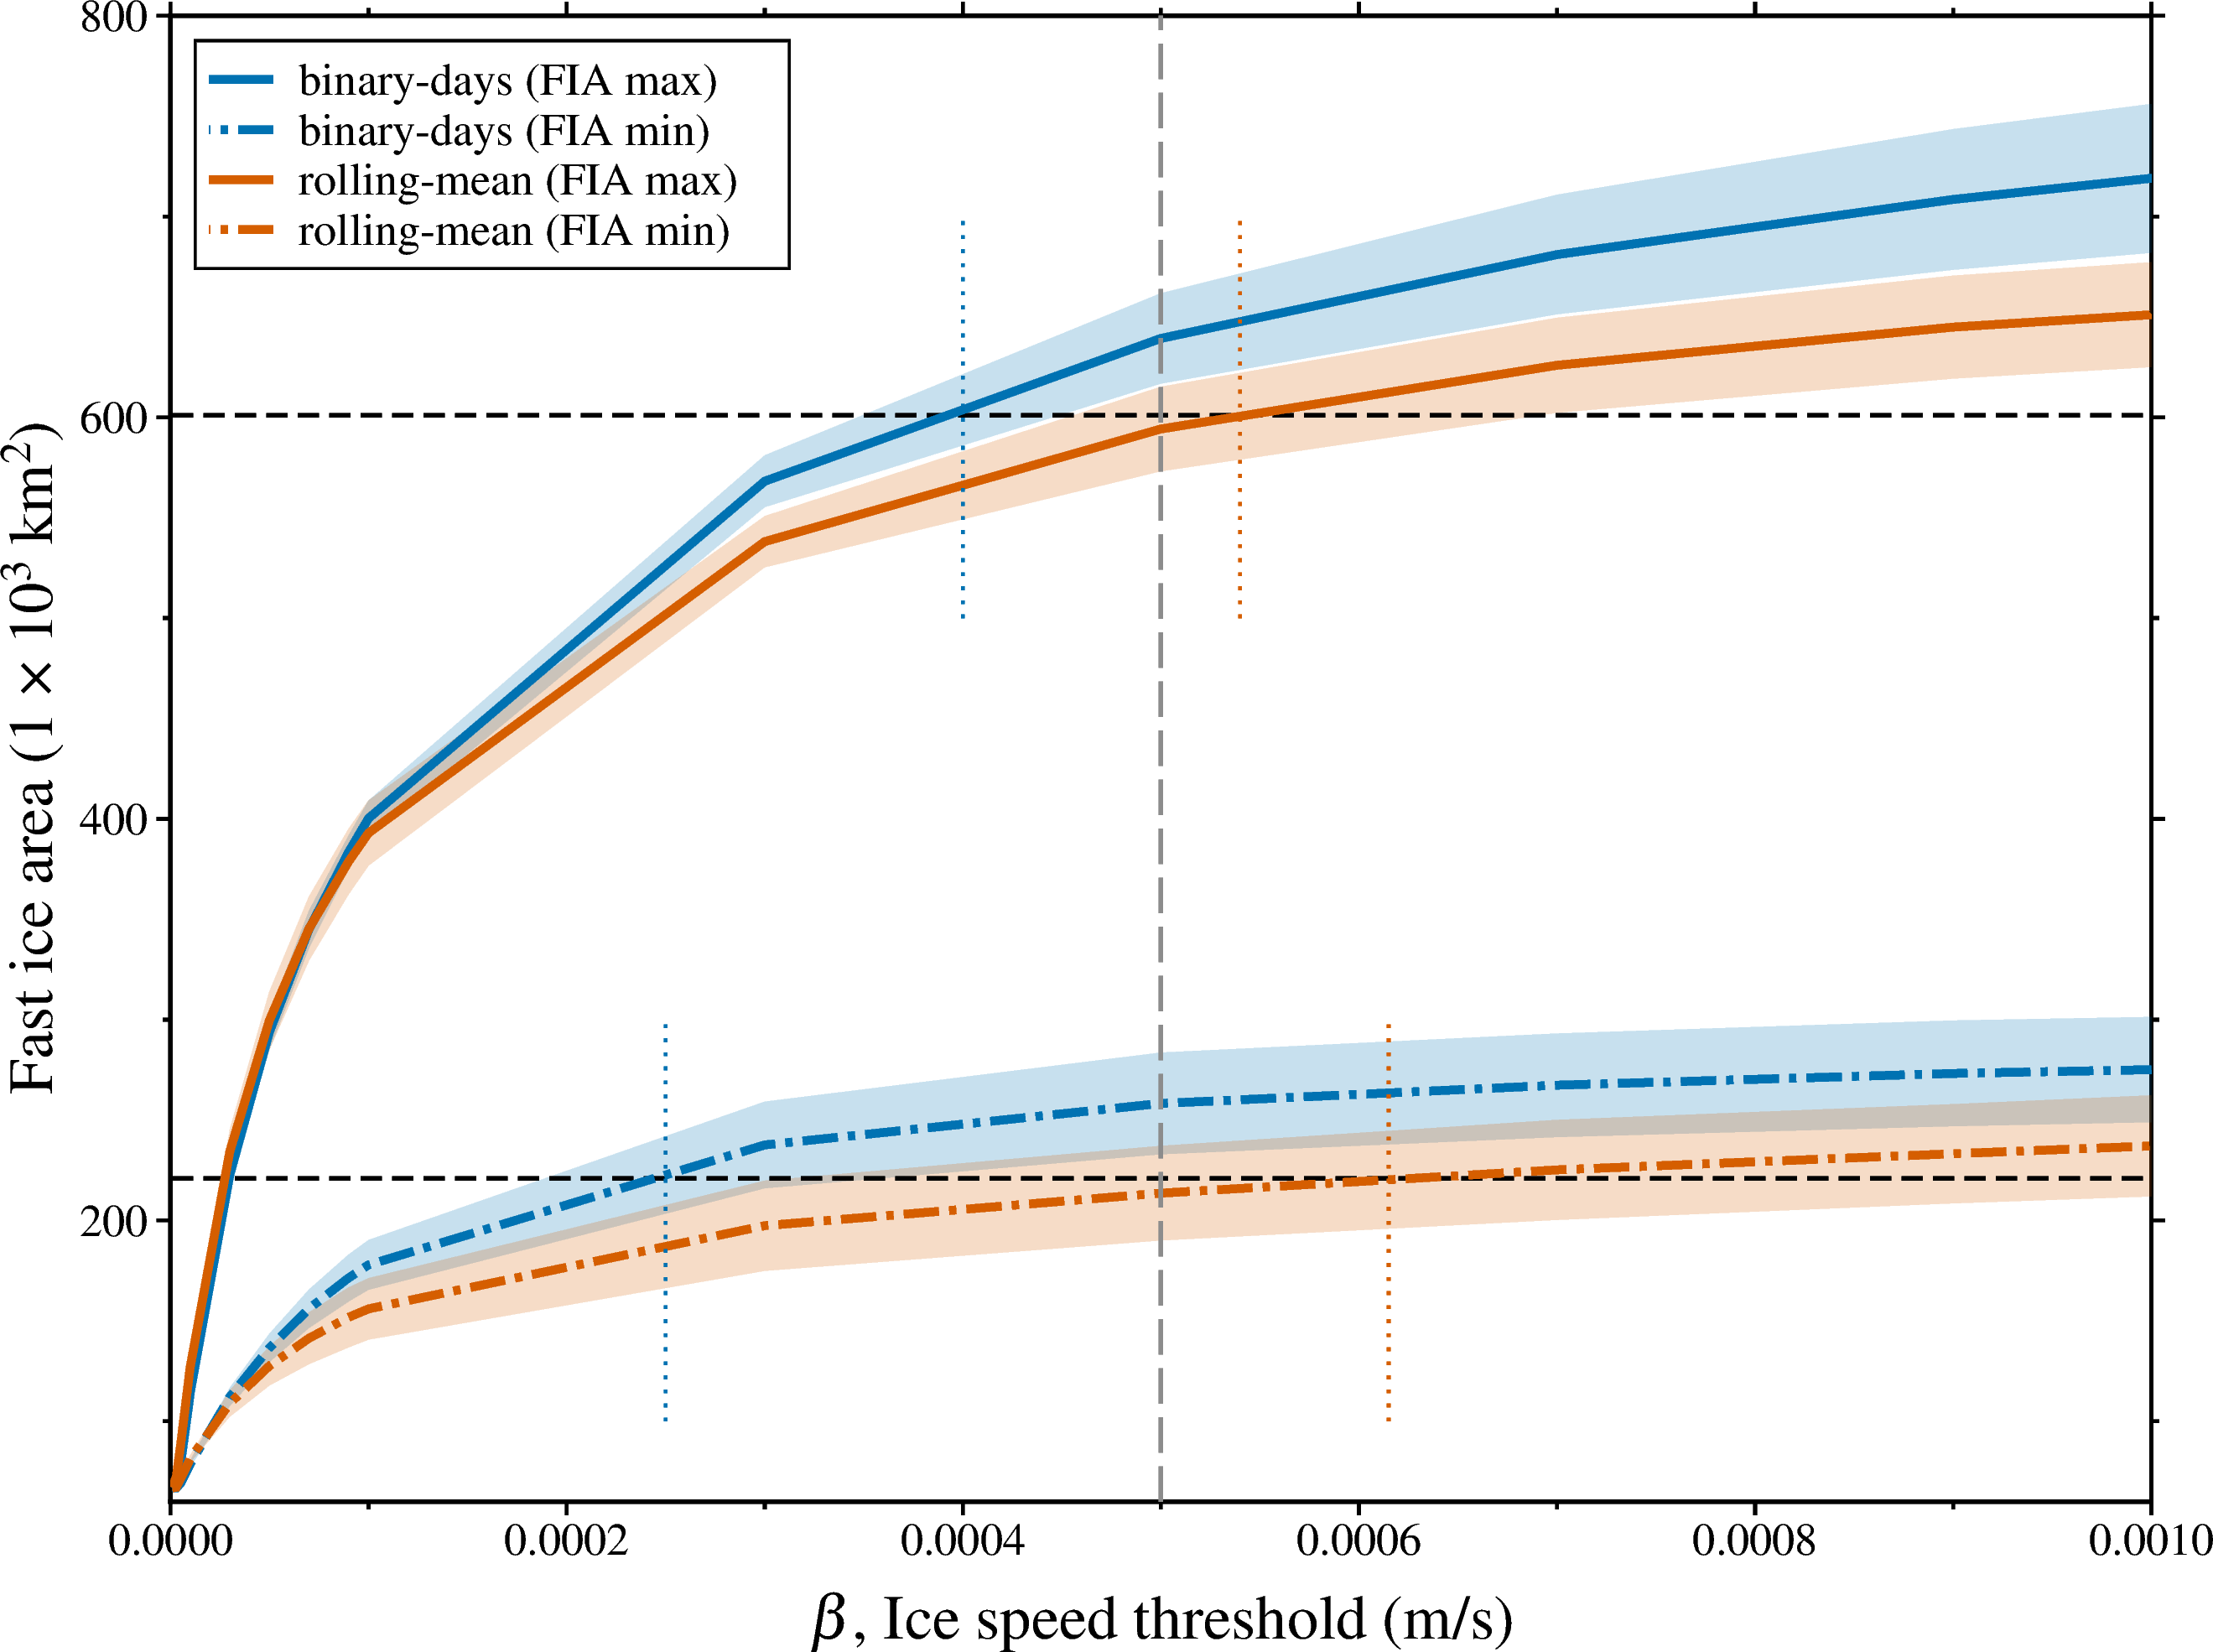

Wrote /home/581/da1339/graphical/AFIM/elps-min/ispd-thresh_vs_FIA-min-max_pygmt.png


In [16]:
with pygmt.config(MAP_FRAME_TYPE          = "plain",
                  MAP_FRAME_PEN           = "1.2p,black",
                  MAP_TICK_PEN_PRIMARY    = "1.0p,black",
                  MAP_TICK_LENGTH_PRIMARY = "0.12c",
                  FONT_ANNOT_PRIMARY      = "13p,Times-Roman,black",
                  FONT_LABEL              = "18p,Times-Roman,black",
                  MAP_LABEL_OFFSET        = "8p"):
    fig = pygmt.Figure()
    fig.basemap(region     = [0, 0.001, YMIN, YMAX],
                projection = "X20c/15c",
                frame      = ["WSen",
                              "xaf+l@[\\beta@[, Ice speed threshold (m/s)",
                              r'yaf+lFast ice area (1 \327 10@+3@+ km@+2@+)'])
    # shaded +/- std envelopes FIRST
    if t_bin.size:
        xpoly, ypoly = band_polygon(t_bin, max_bin, max_std_bin)
        fig.plot(x=xpoly, y=ypoly, fill=BIN_COL, transparency=ALPHA_BAND, close=True)
        xpoly, ypoly = band_polygon(t_bin, min_bin, min_std_bin)
        fig.plot(x=xpoly, y=ypoly, fill=BIN_COL, transparency=ALPHA_BAND, close=True)
    if t_roll.size:
        xpoly, ypoly = band_polygon(t_roll, max_roll, max_std_roll)
        fig.plot(x=xpoly, y=ypoly, fill=ROLL_COL, transparency=ALPHA_BAND, close=True)
        xpoly, ypoly = band_polygon(t_roll, min_roll, min_std_roll)
        fig.plot(x=xpoly, y=ypoly, fill=ROLL_COL, transparency=ALPHA_BAND, close=True)
    # observed bounds
    fig.plot(x=[xmin, xmax], y=[OBS_MIN, OBS_MIN], pen=PEN_OBS)
    fig.plot(x=[xmin, xmax], y=[OBS_MAX, OBS_MAX], pen=PEN_OBS)
    # mean curves on top of bands
    if t_bin.size:
        fig.plot(x=t_bin, y=max_bin, pen=PEN_BIN_MAX, label="binary-days (FIA max)")
        fig.plot(x=t_bin, y=min_bin, pen=PEN_BIN_MIN, label="binary-days (FIA min)")
    if t_roll.size:
        fig.plot(x=t_roll, y=max_roll, pen=PEN_ROLL_MAX, label="rolling-mean (FIA max)")
        fig.plot(x=t_roll, y=min_roll, pen=PEN_ROLL_MIN, label="rolling-mean (FIA min)")
    # threshold reference lines
    fig.plot(x=[2.5e-4, 2.5e-4], y=[100, 300], pen=PEN_VBIN)    # binary-days FIA min
    fig.plot(x=[4.0e-4, 4.0e-4], y=[500, 700], pen=PEN_VBIN)    # binary-days FIA max
    fig.plot(x=[6.15e-4, 6.15e-4], y=[100, 300], pen=PEN_VROLL)   # rolling-mean FIA min
    fig.plot(x=[5.4e-4, 5.4e-4], y=[500, 700], pen=PEN_VROLL)   # rolling-mean FIA max
    # literature/default threshold
    fig.plot(x=[BETA_MAIN, BETA_MAIN], y=[YMIN, YMAX], pen=PEN_JF)
    fig.legend(position="JTL+jTL+o0.25c/0.25c+w6c", box="+gwhite+p0.8p")
    fig.show()
    fig.savefig(OUTPNG, dpi=600)
    fig.savefig(OUTPNG.with_suffix(".pdf"))
    print(f"Wrote {OUTPNG}")

## binary-day or rolling-mean?

+ create a dictionary of circumpolar fast ice area time series for one simulation (``elps-min``) for a range of different ``binary-day`` and ``rolling-mean`` configurations
+ calculate relevant statistical skills for each configuration against fast ice area observations (``AF2020``)
+ come up with a metric (normalisation-score) for determining the best performing configuration

### How to run the cells in this section:

+ the first cell is meant to provide the rationale for why the comparison should be done (it does assume that the user knows the ``F2020`` fortnightly-climatological "shape" of the plot)
+ the second cell below runs the main analysis script in a small test case

However, to run the main analysis script as intended (to regenerate the figure results) then:
```
cd ~/AFIM/src/AFIM/scripts/classification/
qsub -J 7-16 FI_classify_methods_comparison.pbs
qsub -J 17-20 FI_classify_methods_comparison.pbs
qsub -J 1 -v MERGE=1 -W ./FI_classify_methods_comparison.pbs
```

Batch jobs can be monitored using:
```
qstat -t NNNNNNNNNN[].gadi-pbs
```

In [ ]:
FIA_dict    = {}
vars_load   = ['aice','tarea','hi']
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1994-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
SI_tools    = SI_tool_mgr.get_toolbox(sim_name = sim_name,
                                      dt0_str  = dt0_str,
                                      dtN_str  = dtN_str,
                                      ice_speed_threshold = 5e-4)
_, FI_bin_dsA, FI_roll_ds = SI_tools.classify_fast_ice(bin_win_days         = 7,
                                                      bin_min_days          = 5,
                                                      enable_rolling_output = True,
                                                      roll_win_days         = 7)
_, FI_bin_dsB, FI_roll_ds = SI_tools.classify_fast_ice(bin_win_days         = 7,
                                                      bin_min_days          = 7,
                                                      enable_rolling_output = True,
                                                      roll_win_days         = 7)
CICE_SO       = SI_tools.load_cice_zarr(slice_hem=True, variables=['aice','tarea'], dt0_str = "1994-01-01", dtN_str = "1994-12-31",)
FI_bin_maskA  = FI_bin_dsA["FI_mask"] > 0
FI_bin_maskB  = FI_bin_dsB["FI_mask"] > 0
FI_roll_mask  = FI_roll_ds["FI_mask"] > 0 
# 1) Compute masks locally so no graph is serialized
with dask.config.set(scheduler="single-threaded"):
    FI_bin_maskA_c = FI_bin_dsA["FI_mask"].astype("bool").compute()
    FI_bin_maskB_c = FI_bin_dsB["FI_mask"].astype("bool").compute()
    FI_roll_mask_c = FI_roll_ds["FI_mask"].astype("bool").compute()
# 2) Now do the masking and area with local compute as well (or re-chunk afterwards)
with dask.config.set(scheduler="single-threaded"):
    aice_binA  = CICE_SO["aice"].where(FI_bin_maskA_c).compute()
    area_binA  = CICE_SO["tarea"].where(FI_bin_maskA_c).compute()
    aice_binB  = CICE_SO["aice"].where(FI_bin_maskB_c).compute()
    area_binB  = CICE_SO["tarea"].where(FI_bin_maskB_c).compute()
    aice_roll  = CICE_SO["aice"].where(FI_roll_mask_c).compute()
    area_roll  = CICE_SO["tarea"].where(FI_roll_mask_c).compute()
spat = SI_tools.CICE_dict["spatial_dims"]
FIA_binA = (aice_binA * area_binA).sum(dim=spat).rename("FIA")/1e9
FIA_binB = (aice_binB * area_binB).sum(dim=spat).rename("FIA")/1e9
FIA_roll = (aice_roll * area_roll).sum(dim=spat).rename("FIA")/1e9
plt.rcParams['font.family'] = 'Courier New'
fig, ax = plt.subplots(figsize=(9,4))
# overlay on same axis with distinct styles
FIA_binA.plot(ax=ax, label=r'bin-days  : 5/7-days', color='tab:blue'  , linewidth=1.8)
FIA_binB.plot(ax=ax, label=r'bin-days  : 7/7-days', color='tab:orange', linewidth=1.8)
FIA_roll.plot(ax=ax, label=r'roll-mean : 7-days'  , color='tab:green' , linewidth=1.8)
ax.set_title('FIA classification method comparison')
ax.set_ylabel('FIA (10^3 km^2)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()

In [ ]:
from pathlib import Path
import os, getpass, subprocess

WIN       = 9
CNT_SPAN  = 3
SIM_NAME  = "elps-min"
DT0       = "1994-01-01"
DTN       = "1995-12-31"
ISPD_THR  = "5e-4"

USER   = getpass.getuser()
OUTDIR = Path(f"/scratch/gv90/{USER}/afim/methods_comp/elps-min_test")
OUTDIR.mkdir(parents=True, exist_ok=True)
os.environ["DASK_TEMPORARY_DIRECTORY"] = str(OUTDIR / "dask-tmp")
Path(os.environ["DASK_TEMPORARY_DIRECTORY"]).mkdir(parents=True, exist_ok=True)

SCRIPT = str(Path.home() / "AFIM/src/AFIM/scripts/classification/FI_classify_methods_comparison.py")
cmd    = ["python", "-u", SCRIPT, 
          "--sim-name", SIM_NAME,
           "--dt0", DT0, 
           "--dtN", DTN,
           "--ispd", ISPD_THR,
           "--win", str(WIN),
           "--min-days-span", str(CNT_SPAN),
           "--out-dir", str(OUTDIR),]
print("Running:", " ".join(cmd))
res = subprocess.run(cmd)
if res.returncode != 0:
    raise RuntimeError(f"Driver exited with code {res.returncode}")

print("Wrote:", OUTDIR / f"metrics_win{WIN:02d}.csv")

In [ ]:
FIA_dict   = {}
FIV_dict   = {}
sim_name   = "elps-min"
dt0_str    = "1994-01-01"
dtN_str    = "1999-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
SI_tools    = SI_tool_mgr.get_toolbox(sim_name = sim_name,
                                      dt0_str  = dt0_str,
                                      dtN_str  = dtN_str)
FI_raw, CICE = SI_tools.load_processed_cice( zarr_CICE = True )

#### compute binary-days 
+ this will be binary-days for 7 out of 7, 6 out of 7, 5 out of 7, 8 out of 8, 7 out of 8, 6 out of 8, and so on, until 13 out of 15.
  

In [ ]:
CICE_SO = CICE.isel(nj=SI_tools.hemisphere_dict['nj_slice'])
for win in np.arange(7, 16):  # window sizes: 7 to 15 inclusive
    for cnt in np.arange(win, win - 3, -1):  # max, max-1, max-2 (e.g., 7,6,5)
        key_name = f"elps-min_bin-day_{cnt}of{win}"
        FI_bool               = SI_tools.boolean_fast_ice(FI_raw['FI_mask'], window=win, min_count=cnt)
        aice_bool             = CICE_SO['aice'].where(FI_bool)
        hi_bool               = CICE_SO['hi'].where(FI_bool)
        tarea_bool            = CICE_SO['tarea'].where(FI_bool)
        #P_bool                = CICE_SO['strength'].where(FI_bool)
        #divu_bool             = CICE_SO['divu'].where(FI_bool)
        #dvidtt_bool           = CICE_SO['dvidtt'].where(FI_bool)
        FIA_dict[key_name]    = SI_tools.compute_ice_area(FI_bool, tarea_bool)
        FIV_dict[key_name]    = SI_tools.compute_ice_volume(FI_bool, hi_bool, tarea_bool)
        #P_dict[key_name]      = P_bool.sum(dim=('nj','ni'))
        #divu_dict[key_name]   = divu_bool.sum(dim=('nj','ni'))
        #dvidtt_dict[key_name] = dvidtt_bool.sum(dim=('nj','ni'))

#### compute rolling-mean

+ this will be rolling-means over 7, 10, 13, 16 and 19 day periods
+ then compute FIA on each of those

In [ ]:
for i in np.arange(7,20,3):
    roll_name  = f"elps-min_roll-day_{i:d}"
    CICE_rolls = SI_tools.process_rolling_cice(sim_name         = sim_name,
                                               dt0_str          = dt0_str,
                                               dtN_str          = dtN_str,
                                               mean_period      = i,
                                               ivec_type        = "BT",
                                               write_zarr_group = False)
    FIA_dict[roll_name]    = SI_tools.compute_ice_area(CICE_rolls['FI_mask'], CICE_rolls['tarea'])
    FIV_dict[roll_name]    = SI_tools.compute_ice_volume(CICE_rolls['FI_mask'], CICE_rolls['hi'], CICE_rolls['tarea'])
    #P_FI_roll              = CICE_rolls['strength'].where(CICE_rolls['FI_mask'])
    #divu_FI_roll           = CICE_rolls['divu'].where(CICE_rolls['FI_mask'])
    #dvidtt_FI_roll         = CICE_rolls['dvidtt'].where(CICE_rolls['FI_mask'])
    #P_dict[roll_name]      = P_FI_roll.sum(dim=('nj','ni'))
    #divu_dict[roll_name]   = divu_FI_roll.sum(dim=('nj','ni'))
    #dvidtt_dict[roll_name] = dvidtt_FI_roll.sum(dim=('nj','ni'))

#### compute statistics for each configuration

In [ ]:
# ts_ds     = SI_tools.dict_to_ds(FIA_dict)
# ts_ds_cnk = ts_ds.chunk({'time':30})
# ts_ds_cnk.to_zarr(Path(SI_tools.D_sim,"FIA_time-series_multi-bin-days_multi-roll-days.zarr"), mode="w")
# ts_ds     = SI_tools.dict_to_ds(FIV_dict)
# ts_ds_cnk = ts_ds.chunk({'time':30})
# ts_ds_cnk.to_zarr(Path(SI_tools.D_sim,"FIV_time-series_multi-bin-days_multi-roll-days.zarr"), mode="w")
# ts_ds     = SI_tools.dict_to_ds(P_dict)
# ts_ds_cnk = ts_ds.chunk({'time':30})
# ts_ds_cnk.to_zarr(Path(SI_tools.D_sim,"FI-strength_time-series_multi-bin-days_multi-roll-days.zarr"), mode="w")
# ts_ds     = SI_tools.dict_to_ds(divu_dict)
# ts_ds_cnk = ts_ds.chunk({'time':30})
# ts_ds_cnk.to_zarr(Path(SI_tools.D_sim,"FI-strain-rate_time-series_multi-bin-days_multi-roll-days.zarr"), mode="w")
# ts_ds     = SI_tools.dict_to_ds(dvidtt_dict)
# ts_ds_cnk = ts_ds.chunk({'time':30})
# ts_ds_cnk.to_zarr(Path(SI_tools.D_sim,"FI-thermo-vol-tend_time-series_multi-bin-days_multi-roll-days.zarr"), mode="w")
AF_clim = SI_tools.load_AF2020_FIA_summary(start="1994-01-01", end="1999-12-31")
obs_fia = SI_tools.AF2020_clim_to_model_time( FIA_dict['elps-min_bin-day_7of7'] , AF_clim["FIA_clim"].sel(region="circumpolar"))
FIA_stats = {}
for key in FIA_dict.keys():
    print(key)
    FIA_stats[key] = SI_tools.compute_skill_statistics( FIA_dict[key], obs_fia )

#### compute a normalised-score to rank the configurations

In [ ]:
df['Abs_Bias'] = np.abs(df['Bias'])
df['SD_Diff']  = np.abs(df['SD_Model'] - df['SD_Obs'])
df['score']    = (df['Abs_Bias'] / df['Abs_Bias'].max() +
                   df['RMSE']     / df['RMSE'].max() +
                   df['MAE']      / df['MAE'].max() +
                   df['SD_Diff']  / df['SD_Diff'].max() +
                   (1 - df['Corr']) / (1 - df['Corr'].min()))
best_method    = df['score'].idxmin()
df_sorted      = df.sort_values(by='score')
print("Best-aligned method with observed FIA:", best_method)
df_sorted[['Bias', 'RMSE', 'MAE', 'Corr', 'SD_Model', 'SD_Obs']].head(5)

#### Taylor Diagram

In [ ]:
def plot_taylor_nonlinear_zoom(stats_dict, color_metric="Bias", corr_lims=(0.4, 0.1), std_lims=(0.75, 1.0)):
    def nonlinear_theta(corr, exponent=0.5):
        corr = np.clip(corr, 0, 1)
        linear_angle = np.arccos(corr)
        return np.power(linear_angle / np.pi, exponent) * np.pi
    fig = plt.figure(figsize=(14, 14))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    # Colormap with centered zero
    color_vals = np.array([v[color_metric] for v in stats_dict.values()])
    vmin, vmax = color_vals.min(), color_vals.max()
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = cm.RdBu_r
    # Set zoomed radial and angular limits
    ax.set_rmin(std_lims[0])
    ax.set_rmax(std_lims[1])
    ax.set_rticks(np.round(np.linspace(*std_lims, 3), 2))
    ax.set_rlabel_position(135)
    corr_min, corr_max = corr_lims
    tick_corrs = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    tick_angles = [np.degrees(nonlinear_theta(c)) for c in tick_corrs]
    ax.set_thetamin(min(tick_angles))
    ax.set_thetamax(max(tick_angles))
    ax.set_thetagrids(tick_angles, labels=[f"{c:.2f}" for c in tick_corrs])
    # Reference std circle at r = 1
    ref_theta = np.linspace(0, np.pi, 500)
    ax.plot(nonlinear_theta(np.cos(ref_theta)), np.ones_like(ref_theta), 'k-', lw=1.2)
    # RMSD arcs
    ref_std = list(stats_dict.values())[0]['SD_Obs']
    rs = np.linspace(std_lims[0], std_lims[1], 400)
    rms_levels = [20, 50, 100]
    for rms in rms_levels:
        rms_norm = rms / ref_std
        theta = np.arccos(np.clip((1 + rs**2 - rms_norm**2) / (2 * rs), -1, 1))
        scaled_theta = nonlinear_theta(np.cos(theta))
        valid = (scaled_theta >= np.radians(ax.get_thetamin())) & (scaled_theta <= np.radians(ax.get_thetamax()))
        ax.plot(scaled_theta[valid], rs[valid], '--', color='lightgray', lw=0.8)
        if np.any(valid):
            label_theta = scaled_theta[valid][5]
            label_r = rs[valid][5] + 0.01
            ax.text(label_theta, label_r, f'RMSE={rms}', fontsize=7, color='gray')

    # Plot data points with external annotations and arrows
    for i, (label, stat) in enumerate(stats_dict.items()):
        corr = np.clip(stat["Corr"], 0, 1)
        std_ratio = stat["SD_Model"] / stat["SD_Obs"]
        angle = nonlinear_theta(corr)
        r = std_ratio
        color = cmap(norm(stat[color_metric]))
        ax.plot(angle, r, 'o', markersize=6, color=color)
        # Offset annotation radially outward
        r_annot = r + 0.05
        ax.annotate(label,
            xy=(angle, r),
            xytext=(angle*0.9, r_annot),
            textcoords='data',
            ha='center', va='center',
            fontsize=8,
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.7)
        )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.2, orientation="horizontal", shrink=0.75)
    cbar.set_label(f"{color_metric} (m/s)")
    
    plt.tight_layout()
    plt.show()

In [ ]:
sim_name   = "elps-min"
SI_tools   = SeaIceToolbox( sim_name = sim_name )
AF2020_CSV = SI_tools.load_AF2020_FIA_summary()
obs_FIA    = AF2020_CSV['FIA_clim_repeat'].sel(region='circumpolar')
FIA_sim    = xr.open_zarr(Path(Path.home(),"AFIM_archive","elps-min","FIA_time-series_multi-bin-days_multi-roll-days.zarr"))
dt         = pd.to_datetime(FIA_sim["time"].values)
valid_dt   = dt.year > 1993 
FIA_sim    = FIA_sim.sel(time=valid_dt)
print(FIA_sim.time.values)

In [ ]:
AF_clim = SI_tools.load_AF2020_FIA_summary(start="1994-01-01", end="1999-12-31")
obs_fia = SI_tools.AF2020_clim_to_model_time( FIA_sim['elps-min_bin-day_7of7'] , AF_clim["FIA_clim"].sel(region="circumpolar"))
FIA_stats = {}
for key in FIA_sim.keys():
    print(key)
    FIA_stats[key] = SI_tools.compute_skill_statistics( FIA_sim[key], obs_fia )

In [ ]:
# import json
# with open("/g/data/gv90/da1339/afim_output/elps-min/FIA_skill_statistics_1994-1999.json", "w") as f:
#     json.dump(FIA_stats, f, indent=2)
#plot_taylor(FIA_stats)
plot_taylor_nonlinear_zoom(FIA_stats,color_metric="Bias",std_lims=(0.8, 1))

In [ ]:
FIA_dict = {"AF2020"                  : obs_FIA,
            "elps-min_bin-day_13of15"  : FIA_sim['elps-min_bin-day_13of15'],
            "elps-min_bin-day_14of15" : FIA_sim['elps-min_bin-day_14of15'],
            "elps-min_bin-day_15of15" : FIA_sim['elps-min_bin-day_15of15'],
            "elps-min_roll-day_16"    : FIA_sim['elps-min_roll-day_16']}
SI_tools.plot_timeseries_matplotlib(FIA_dict,
                        ylabel    = "Fast Ice Area (1000-km²)",
                        P_png     = Path(SI_tools.D_graph,"timeseries","FIA_elps-min_bin-day_comparison_15day.png"))
SI_tools.plot_monthly_ice_metric_by_year(FIA_dict,
                                        ice_type         = "FIA",
                                        figsize          = (18, 10),
                                        P_png            = Path(SI_tools.D_graph,sim_name,"FIA_elps-min_bin-day_comparison_15day_by_doy.png"),
                                        plot_annotations = False)

#
---------------------

# ACCESS-OM2-025-ERA5 sea ice data 
**needs only to be run once, after which data can be extracted from local zarr files**
+ this uses [ACCESS-NRI intake catalog](https://access-nri-intake-catalog.readthedocs.io/en/latest/index.html) through a ``SeaIceToolbox`` method ``load_ACCESS_OM_CICE``

In [ ]:
dt0_str        = "2000-01-01"
dtN_str        = "2023-12-31"
dt_rng_str     = f"{dt0_str[:4]}-{dtN_str[:4]}"
ice_type       = "FI_BT"
SIA_dict       = {}
FIA_dict       = {}
SI_tools       = SeaIceToolbox(sim_name             = "AOM2-ERA5",
                               dt0_str              = dt0_str,
                               dtN_str              = dtN_str,
                               ice_speed_threshold  = 5e-4,
                               ice_speed_type       = "BT",
                               ice_type             = "FI_BT",
                               overwrite_zarr       = False,
                               save_new_figs        = True,
                               show_figs            = True,
                               overwrite_saved_figs = True)

## load ACCESS-OM-025-ERA5 data from ESM datastore then convert to zarr files for easy of use later
+ loading and saving only needs to be done if it has not been done previously
+ running both of these cells takes approximately an hour with the bottleneck at writing to zarr

In [ ]:
AOM2 = SI_tools.load_ACCESS_OM_CICE()

In [ ]:
SI_tools.write_ACCESS_to_monthly_zarr(AOM2)

## run ACCESS-OM-025-ERA5 through fast ice classification workflow
+ this is a quick process and will save masked zarr dataset

In [ ]:
AOM2_FI_raw = SI_tools.process_daily_cice(ispd_thresh=5e-4,
                                          ivec_type="BT",
                                          overwrite_zarr_group=True)

In [ ]:
AOM2_FI_roll = SI_tools.process_rolling_cice(ispd_thresh=5e-4,
                                             ivec_type="BT",
                                             overwrite_zarr_group=True)

### Seasonality and inter-annual variability

In [ ]:
sim_name            = "elps-min"
SI_tools            = SeaIceToolbox(sim_name = sim_name)
FI_mets             = xr.open_dataset(Path(SI_tools.D_zarr,"ispd_thresh_5.0e-4","metrics","FI_BT_bool_mets.zarr"))
FIA_obs             = SI_tools.load_AF2020_FI_area_timeseries()
FIA_dict            = {}
FIA_dict['FIA_obs'] = FIA_obs
FIA_dict['FIA_sim'] = FI_mets['FIA']
FIA_obs_df          = FIA_dict['FIA_obs']  # pandas DataFrame
FIA_sim             = FIA_dict['FIA_sim']  # xarray DataArray with .time and daily frequency
obs_daily_list      = []
for year in FIA_obs_df['Year'].unique():
    subset     = FIA_obs_df[FIA_obs_df['Year'] == year]
    doys       = ((subset['DOY_start'] + subset['DOY_end']) // 2).values
    dates      = pd.to_datetime(f"{year}-01-01") + pd.to_timedelta(doys - 1, unit='D')
    ts         = pd.Series(subset['circumpolar'].values, index=dates)
    full_range = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq='D')
    ts_daily   = ts.reindex(full_range).interpolate("linear").ffill().bfill()
    obs_daily_list.append(ts_daily)
FIA_obs_daily   = pd.concat(obs_daily_list).sort_index()
sim_dates       = pd.to_datetime(FIA_sim['time'].values)
FIA_obs_aligned = FIA_obs_daily.reindex(sim_dates).interpolate("linear").ffill().bfill()
FIA_obs_aligned = FIA_obs_aligned/1e3
FIA_sim_smooth  = FIA_sim.rolling(time=15, center=True).mean()
FIA_diff_norm   = (FIA_obs_aligned - FIA_sim_smooth) / FIA_obs_aligned 
fig, ax1        = plt.subplots(figsize=(20, 12))
ax1.plot(sim_dates, FIA_sim_smooth, label="model (CICE6-standalone)", color='blue', linewidth=1)
ax1.plot(sim_dates, FIA_obs_aligned, label="observed", color='black', linestyle='--')
ax1.tick_params(size=14, axis='y', labelcolor='black')
ax2 = ax1.twinx()
ax2.plot(sim_dates, FIA_diff_norm, label="(Obs - Sim) / Obs [%]", color='gray', alpha=0.5)
ax2.tick_params(size=14, axis='y', labelcolor='gray')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title("Circumpolar Antarctic Fast Ice Area 2000-2018: Observations vs Model", fontsize=20)
ax1.set_ylabel("Area (1000 km²)", fontsize=18)
ax2.set_ylabel("Relative Difference (%)", color='gray', fontsize=18)
ax1.set_xlabel("Date", fontsize=18)
ax1.set_ylim([100, 800])
ax2.set_ylim([-1,1])
ax1.set_xlim(pd.Timestamp("2000-03-01"), pd.Timestamp("2018-03-01"))
plt.tight_layout()
plt.show()
results = []
for year in range(2000, 2019):
    t0 = pd.Timestamp(f"{year}-01-01")
    tN = pd.Timestamp(f"{year}-12-31")
    sim_year = FIA_sim_smooth.sel(time=slice(t0, tN)).to_series()
    obs_year = FIA_obs_aligned.loc[t0:tN]
    sim_year = sim_year.dropna()
    obs_year = obs_year.dropna()
    if len(sim_year) == 0 or len(obs_year) == 0:
        continue
    sim_min_val    = sim_year.min()
    sim_min_day    = sim_year.idxmin()
    sim_max_val    = sim_year.max()
    sim_max_day    = sim_year.idxmax()
    obs_min_val    = obs_year.min()
    obs_min_day    = obs_year.idxmin()
    obs_max_val    = obs_year.max()
    obs_max_day    = obs_year.idxmax()
    delta_min_mag  = sim_min_val - obs_min_val
    delta_min_time = (sim_min_day - obs_min_day).days
    delta_max_mag  = sim_max_val - obs_max_val
    delta_max_time = (sim_max_day - obs_max_day).days
    results.append({"year"     : year,
                    "sim_min"  : sim_min_val,
                    "obs_min"  : obs_min_val,
                    "Δmin_mag" : delta_min_mag,
                    "Δmin_day" : delta_min_time,
                    "sim_max"  : sim_max_val,
                    "obs_max"  : obs_max_val,
                    "Δmax_mag" : delta_max_mag,
                    "Δmax_day" : delta_max_time})
comparison_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(comparison_df['year'] - 0.2, comparison_df['Δmin_mag'], label='Δmin_mag (Obs - Sim)', color='steelblue')
ax.plot(comparison_df['year'] + 0.2, comparison_df['Δmax_mag'], label='Δmax_mag (Obs - Sim)', color='coral')
ax.set_xlabel("Year")
ax.set_ylabel("Δ Magnitude (km²)")
ax.set_title("Observed - Model Min/Max FIA Magnitude per Year")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(comparison_df['year'] - 0.2, comparison_df['Δmin_day'], label='Δmin_day (days)', color='slategray')
ax.plot(comparison_df['year'] + 0.2, comparison_df['Δmax_day'], label='Δmax_day (days)', color='darkorange')
ax.set_xlabel("Year")
ax.set_ylabel("Δ Timing (days)")
ax.set_title("Observed - Model Timing of Min/Max FIA per Year")
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()


# Is there a relationship between sea ice speed threshold and fast ice area?

In [ ]:

# Assumes your SeaIceToolboxManager + toolbox loader are already available
# from your environment
# from your_pkg import SeaIceToolboxManager

def _get_scalar(ds, name, default=np.nan):
    """Safely fetch a scalar from an xarray.Dataset (variable can be 0-D or length-1)."""
    if name not in ds:
        return default
    v = ds[name]
    try:
        # 0-D (scalar) or length-1
        return float(v.values) if np.size(v.values) == 1 else float(v.values.squeeze())
    except Exception:
        return default

def load_metrics_for_experiment(sim_name, dt0_str, dtN_str, P_log=None):
    """Load the computed metrics (mets) dataset for one experiment."""
    SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
    SI_tools    = SI_tool_mgr.get_toolbox(sim_name=sim_name, dt0_str=dt0_str, dtN_str=dtN_str)
    mets        = SI_tools.load_computed_metrics(ice_type="FI_BT")
    return mets

def build_fia_skill_table(
    experiments,
    dt0_str="1994-01-01",
    dtN_str="1999-12-31",
    P_log=None,
    round_map=None
):
    """
    For each experiment in `experiments`, load `mets` and extract:
      Bias, Corr, MAE, RMSE, SD_Model, SD_Obs,
      persistence_stability_index, persistence_max_distance, persistence_mean_distance,
      FIA_Maximum Mean, FIA_Minimum Mean, FIA_DOY Max Mean, FIA_DOY Min Mean.

    Returns
    -------
    df : pandas.DataFrame
        Tidy table ready for LaTeX.
    latex_str : str
        A LaTeX tabular environment (no surrounding table environment),
        matching column order and formatting.
    """
    cols = [
        ("Experiment", "experiment"),
        ("Bias", "Bias"),
        ("Corr", "Corr"),
        ("MAE", "MAE"),
        ("RMSE", "RMSE"),
        (r"SD\textsubscript{model}", "SD_Model"),
        (r"SD\textsubscript{obs}",   "SD_Obs"),
        (r"FIPSI",                   "persistence_stability_index"),
        (r"FIPmax (km)",             "persistence_max_distance"),
        (r"FIPmean (km)",            "persistence_mean_distance"),
        (r"FIA\_Maximum Mean",       "FIA_Maximum Mean"),
        (r"FIA\_Minimum Mean",       "FIA_Minimum Mean"),
        (r"FIA\_DOY Max Mean",       "FIA_DOY Max Mean"),
        (r"FIA\_DOY Min Mean",       "FIA_DOY Min Mean"),
    ]

    rows = []
    for sim_name in experiments:
        mets = load_metrics_for_experiment(sim_name, dt0_str, dtN_str, P_log=P_log)

        row = {"experiment": sim_name}
        # Pull scalars
        row["Bias"]  = _get_scalar(mets, "Bias")
        row["Corr"]  = _get_scalar(mets, "Corr")
        row["MAE"]   = _get_scalar(mets, "MAE")
        row["RMSE"]  = _get_scalar(mets, "RMSE")

        row["SD_Model"] = _get_scalar(mets, "SD_Model")
        # SD_Obs appears to be scalar in mets; if not present, set to your known benchmark (e.g., 127)
        sd_obs_val = _get_scalar(mets, "SD_Obs")
        row["SD_Obs"] = sd_obs_val

        # Persistence metrics
        row["persistence_stability_index"] = _get_scalar(mets, "persistence_stability_index")
        row["persistence_max_distance"]    = _get_scalar(mets, "persistence_max_distance")
        row["persistence_mean_distance"]   = _get_scalar(mets, "persistence_mean_distance")

        # FIA summaries
        row["FIA_Maximum Mean"] = _get_scalar(mets, "FIA_Maximum Mean")
        row["FIA_Minimum Mean"] = _get_scalar(mets, "FIA_Minimum Mean")
        row["FIA_DOY Max Mean"] = _get_scalar(mets, "FIA_DOY Max Mean")
        row["FIA_DOY Min Mean"] = _get_scalar(mets, "FIA_DOY Min Mean")

        rows.append(row)

    df = pd.DataFrame(rows)

    # Order and rename columns for LaTeX
    latex_columns = [c[0] for c in cols]
    internal_keys = [c[1] for c in cols]
    df = df.rename(columns={"experiment": "Experiment"})  # to match label above
    df = df[ [ ("Experiment" if k=="experiment" else k) for k in internal_keys ] ]
    df.columns = latex_columns

    # Optional rounding for neatness
    if round_map is None:
        round_map = {
            "Bias": 1, "Corr": 3, "MAE": 1, "RMSE": 1,
            r"SD\textsubscript{model}": 1, r"SD\textsubscript{obs}": 0,
            "FIPSI": 3, "FIPmax (km)": 1, "FIPmean (km)": 1,
            "FIA\\_Maximum Mean": 1, "FIA\\_Minimum Mean": 1,
            "FIA\\_DOY Max Mean": 0, "FIA\\_DOY Min Mean": 0,
        }
    for col, ndig in round_map.items():
        if col in df.columns:
            df[col] = np.where(pd.notnull(df[col]), np.round(df[col].astype(float), ndig), df[col])

    # Build a LaTeX tabular (no outer table env) using siunitx S columns would be ideal,
    # but to keep it simple/robust here we’ll output a standard tabular string:
    col_fmt = "l" + "r"*(len(df.columns)-1)
    header = " & ".join(df.columns) + r" \\"
    lines  = [ " & ".join(map(str, r)) + r" \\" for r in df.values ]
    latex_str = (
        "\\begin{tabular}{" + col_fmt + "}\n\\toprule\n" +
        header + "\n\\midrule\n" +
        "\n".join(lines) + "\n\\bottomrule\n\\end{tabular}"
    )
    return df, latex_str

# --- Example usage (matching the experiments in your current table order) ---
experiments = [
    "elps-min","elps-ext","elps-mid","elps-max","FI-heavy","ry93",
    "Pstar-max","Pstar-min","Cstar-min","Cstar-max",
    "gi-max","gi-mid","gi-min","gi-nil","gi-nil-def","notensnogi",
    "ktens-max","ktens-min","ktens-nil","ktens-ext",
]
# Map these to your actual sim_name strings if they differ
df, latex_tab = build_fia_skill_table(experiments, dt0_str="1994-01-01", dtN_str="1999-12-31", P_log=Path.home()/ "logs/paper1_sandbox.log")
print(latex_tab)


---------------------------------------

# B-grid re-gridding comparison

In [ ]:
sim_name    = "elps-min"
dt0_str     = "1994-01-01"
dtN_str     = "1995-12-31"
P_log       = Path(Path.home(), "logs", "paper1_sandbox.log")
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
SI_tools    = SI_tool_mgr.get_toolbox(sim_name=sim_name, dt0_str=dt0_str, dtN_str=dtN_str, list_of_composite_grids=['Tb'])
SI_tools.define_datetime_vars()

In [ ]:
for yr0_str, yrN_str in zip(SI_tools.yr0_strs, SI_tools.yrN_strs):
    yr_str = yr0_str[:4]
    print(f"looping over each month in year {yr_str}")
    SI_tools.define_datetime_vars(dt0_str=yr0_str, dtN_str=yrN_str)
    FI_mo, FI_bin_mo, FI_roll_mo, ispd_dy_mo, ispd_rl_mo = [], [], [], [], []
    for mo0_str, moN_str in zip(SI_tools.mo0_strs, SI_tools.moN_strs):
        FI_raw, FI_bin, FI_roll, ispds = SI_tools.classify_fast_ice(dt0_str=mo0_str, dtN_str=moN_str, enable_rolling_output=True)
        FI_mo.append(FI_raw)
        FI_bin_mo.append(FI_bin)
        FI_roll_mo.append(FI_roll)
        ispd_dy_mo.append(ispds['daily'])
        ispd_rl_mo.append(ispds['rolly'])
    FI_yr      = xr.concat(FI_mo, dim="time").chunk(SI_tools.CICE_dict["FI_chunks"])
    FI_bin_yr  = xr.concat(FI_bin_mo, dim="time").chunk(SI_tools.CICE_dict["FI_chunks"])
    FI_roll_yr = xr.concat(FI_roll_mo, dim="time").chunk(SI_tools.CICE_dict["FI_chunks"]) 
    ispd_dy_yr = xr.concat(ispd_dy_mo, dim="time").chunk(SI_tools.CICE_dict["FI_chunks"])
    ispd_rl_yr = xr.concat(ispd_rl_mo, dim="time").chunk(SI_tools.CICE_dict["FI_chunks"])                        

In [ ]:
load_vars = ['aice','tarea','hi','strength','dvidtt','daidtt','dvidtd','daidtd']
CICE_SO   = SI_tools.load_cice_zarr(slice_hem=True, variables=load_vars)
A         = CICE_SO['tarea'].isel(time=0)
FI_daily  = CICE_SO.where(FI_yr['FI_mask'])
FI_rolly  = CICE_SO.where(FI_roll_yr['FI_mask'])
FI_binly  = CICE_SO.where(FI_bin_yr['FI_mask'])
FI_dy     = SI_tools.fast_ice_metrics_data_dict(FI_yr, FI_daily, A)
FI_rl     = SI_tools.fast_ice_metrics_data_dict(FI_roll_yr, FI_rolly, A)
FI_bn     = SI_tools.fast_ice_metrics_data_dict(FI_bin_yr, FI_binly, A)
FIA_raw  = SI_tools.compute_hemisphere_ice_area(FI_dy['aice'], A, ice_area_scale=SI_tools.FIC_scale)
FIA_roll = SI_tools.compute_hemisphere_ice_area(FI_rl['aice'], A, ice_area_scale=SI_tools.FIC_scale)
FIA_bin  = SI_tools.compute_hemisphere_ice_area(FI_bn['aice'], A, ice_area_scale=SI_tools.FIC_scale)
FIA_dict = {"FI_BT"     : {'FIA'      : FIA_raw.compute(),
                           "leg_lab"  : "@[\\mathcal{M}_{\\mathrm{FI\\_daily}}@[",
                           "line_pen" : "1p",
                           "line_clr" : "#000000"},
            "FI_BT_bin" : {'FIA'      : FIA_bin.compute(),
                           "leg_lab"  : "@[\\mathcal{M}_{\\mathrm{FI\\_bin}}@[",
                           "line_pen" : "2p",
                           "line_clr" : "#D55E00"}, 
            "FI_BT_roll": {'FIA'      : FIA_roll.compute(),
                           "leg_lab"  : "@[\\mathcal{M}_{\\mathrm{FI\\_roll}}@[",
                           "line_pen" : "1.5p",
                           "line_clr" : "#56B4E9"}}
FIA = FIA_dict

In [ ]:
FI  = {'FI_daily' : FI_daily,
        'FI_binly' : FI_binly,
        'FI_rolly' : FI_rolly}
FI_binly.to_netcdf("/home/581/da1339/AFIM_archive/elps-min/ispd_regrid_analysis/elps-min_Tb.nc")
# print(FIA_Tb)
# print(FI_Tb)

In [ ]:
D_out = Path(SI_tools.D_sim) / "ispd_regrid_analysis"
D_out.mkdir(parents=True, exist_ok=True)
FIA_ds = xr.Dataset({"FI_BT"      : (("time",), FIA["FI_BT"]["FIA"].values),
                     "FI_BT_bin"  : (("time",), FIA["FI_BT_bin"]["FIA"].values),
                     "FI_BT_roll" : (("time",), FIA["FI_BT_roll"]["FIA"].values)},
                    coords = {"time": FIA["FI_BT"]["FIA"]["time"].values},
                    attrs  = {"title"   : f"Fast-ice area time series ({SI_tools.sim_name})",
                              "units"   : "10^3 km^2",
                              "source"  : "AFIM / SeaIceClassification -- Tb,Tx",
                              "contact" : "daniel.atwater@utas.edu.au",})
for key in ["FI_BT", "FI_BT_bin", "FI_BT_roll"]:
    FIA_ds[key].attrs.update({"legend_label": FIA[key]["leg_lab"],
                              "line_pen"    : FIA[key]["line_pen"],
                              "line_color"  : FIA[key]["line_clr"]})
# NetCDF (compressed)
P_nc = D_out / f"FIA_{SI_tools.sim_name}_{SI_tools.dt0_str[:4]}-{SI_tools.dtN_str[:4]}_TbTx.nc"
enc  = {v: {"zlib": True, "complevel": 4, "dtype": "f4", "_FillValue": np.nan} for v in FIA_ds.data_vars}
FIA_ds.to_netcdf(P_nc, encoding=enc)
print(f"Saved FIA to {P_nc}")



In [ ]:
D_out = Path(SI_tools.D_sim) / "ispd_regrid_analysis" / f"{SI_tools.sim_name}_TbTx.zarr"
D_out.parent.mkdir(parents=True, exist_ok=True)
def _save_group(ds: xr.Dataset, group: str, first: bool = False):
    varname = "FI_mask" if "FI_mask" in ds.data_vars else list(ds.data_vars)[0]
    out     = ds[[varname]].astype("uint8")   # keep it small
    for v in out.data_vars:
        out[v].encoding = {}
    mode = "w" if (first or not D_out.exists()) else "a"
    out.to_zarr(str(D_out), group=group, mode=mode, consolidated=True, zarr_version=2)
_save_group(FI["FI_daily"], group="FI_daily", first=True)
_save_group(FI["FI_binly"], group="FI_bin")
_save_group(FI["FI_rolly"], group="FI_roll")
print(f"Saved FI masks to {D_out}")

In [ ]:
fig = SI_tools.pygmt_timeseries(ts_dict   = FIA_dict,
                                primary_key = "FIA",
                                legend_pos  = "JTL+jTL+o0.2c+w5c",
                                #P_png=Path(SI_tools.P_figs, f"FIA_timeseries_{SI_tools.sim_name}_1995.png"),
                                save_fig  = False,
                                show_fig  = True)

# Sensitivity Table

In [ ]:
ARCHIVE_DIR = Path.home() / "AFIM_archive"
dt0_str     = "1994-01-01"
dtN_str     = "1999-12-31"
P_log       = Path(Path.home(), "logs", f"paper1_sandbox_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")
# Metrics variable name mapping (left = what this script looks for, right = fallback names in your zarr)
VAR_CANDIDATES = {"bias":               ["bias", "fia_bias", "FIA_bias"],
                  "corr":               ["corr", "correlation", "pearson_r"],
                  "mae":                ["mae", "mean_abs_error"],
                  "rmse":               ["rmse", "root_mean_sq_error"],
                  "fipsi":              ["fipsi", "FIPSI", "persistence_stability_index"],
                  "fipmax":             ["fipmax", "FIP_max", "persistence_max_distance", "fip_max_km"],
                  "fia_max_area":       ["fia_max_area", "FIA_max_area", "fia_area_max", "fia_max_kkm2"],
                  "fia_min_area":       ["fia_min_area", "FIA_min_area", "fia_area_min", "fia_min_kkm2"],
                  "fia_max_onset_doy":  ["fia_max_onset_doy", "FIA_max_onset_doy", "onset_max_doy", "fia_onset_max"],
                  "fia_min_onset_doy":  ["fia_min_onset_doy", "FIA_min_onset_doy", "onset_min_doy", "fia_onset_min"],}
AREA_UNITS = "m2"  # one of {"kkm2", "km2", "m2"}
# Map archive folder names -> LaTeX \gls{} macros
GLOSS_MAP = {"elps-min":  r"\gls{elpsmin}",
             "elps-ext":  r"\gls{elpsext}",
             "elps-mid":  r"\gls{elpsmid}",
             "elps-max":  r"\gls{elpsmax}",
             "FI-heavy":  r"\gls{fiheavy}",
             "ry93":      r"\gls{ry}",
             "Pstar-max": r"\gls{pstarmax}",
             "Pstar-min": r"\gls{pstarmin}",
             "Cstar-max": r"\gls{cstarmax}",
             "Cstar-min": r"\gls{cstarmin}",
             "gi-max":    r"\gls{gimax}",
             "gi-mid":    r"\gls{gimid}",
             "gi-min":    r"\gls{gimin}",
             "gi-nil":    r"\gls{ginil}",
             "gi-nil-def":r"\gls{ginildef}",
             "notensnogi":r"\gls{nofi}",
             "ktens-max": r"\gls{ktensmax}",
             "ktens-min": r"\gls{ktensmin}",
             "ktens-nil": r"\gls{ktensnil}",
             "ktens-ext": r"\gls{ktensext}"}
# Preferred row order (match paper)
PREFERRED_ORDER = ["elps-min","elps-ext","elps-mid","elps-max","FI-heavy","ry93",
                   "Pstar-max","Pstar-min","Cstar-min","Cstar-max",
                   "gi-max","gi-mid","gi-min","gi-nil","gi-nil-def","notensnogi",
                   "ktens-max","ktens-min","ktens-nil","ktens-ext"]

def _get_scalar(ds: xr.Dataset, keys: list[str], default=np.nan):
    """Return a Python float from ds[key], trying keys in order; supports DataArray or 0-d variable."""
    for k in keys:
        if k in ds:
            v = ds[k]
            try:
                # xr.DataArray(…)-> .item(); if it has dims, reduce if size==1
                return float(v.item() if v.size == 1 else v.values.squeeze().item())
            except Exception:
                pass
    return float(default)
    
def _area_to_kkm2(val: float) -> float:
    if np.isnan(val):
        return np.nan
    if AREA_UNITS == "kkm2":  # already in 1e3 km^2
        return float(val)
    if AREA_UNITS == "km2":
        return float(val) / 1e3
    if AREA_UNITS == "m2":
        return float(val) / 1e9  # m^2 -> (1e3 km^2)
    return float(val)

import pandas as pd
import math

def _latex_escape(s: str) -> str:
    """Escape minimal LaTeX specials in text fields."""
    if s is None:
        return ""
    rep = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    out = str(s)
    for k, v in rep.items():
        out = out.replace(k, v)
    return out

def format_table_latex(
    df: pd.DataFrame,
    max_width="\\linewidth",
    label="tab:FIA_skill_metrics_ext",
    caption=None
) -> str:
    """
    Build a LaTeX tabular string with a units row, using booktabs + adjustbox.
    Requires in preamble:
        \\usepackage{booktabs}
        \\usepackage{siunitx}
        \\usepackage{adjustbox}
    """
    # Column order & pretty headers
    cols    = [
        "Experiment", "bias", "corr", "mae", "rmse", "fipsi"]#, "fipmax",
        #"fia_max_area", "fia_min_area", "fia_max_onset_doy", "fia_min_onset_doy"
    #]
    units   = [
        "",
        "", "", "", "", "",  # bias, corr, mae, rmse, fipsi
        # r"\si{\kilo\metre}", r"$1\times10^3\ \mathrm{km}^2$", r"$1\times10^3\ \mathrm{km}^2$",
        # r"\text{onset (DOY)}", r"\text{onset (DOY)}"
    ]
    headers = [
        r"\textbf{Experiment}",
        r"\textbf{\gls{bias}}",
        r"\textbf{\gls{corr}}",
        r"\textbf{\gls{mae}}",
        r"\textbf{\gls{rmse}}",
        r"\textbf{\gls{fipsi}}",
        # r"\textbf{\gls{fipmax}}",
        # r"\textbf{\gls{fia}$_\mathrm{max}$}",
        # r"\textbf{\gls{fia}$_\mathrm{min}$}",
        # r"\textbf{\gls{fia}$_\mathrm{max}$}",
        # r"\textbf{\gls{fia}$_\mathrm{min}$}",
    ]

    # Alignment: 1 'l' + 10 'r'
    align = "l" + "r"*10

    # Ensure required columns exist
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    # Format numbers per your style
    def f1(x): return "" if (x is None or (isinstance(x,float) and math.isnan(x))) else f"{x:.1f}"
    def f3(x): return "" if (x is None or (isinstance(x,float) and math.isnan(x))) else f"{x:.3f}"

    df_fmt = df.copy()
    df_fmt["Experiment"]        = df_fmt["Experiment"].map(_latex_escape)
    df_fmt["bias"]              = df_fmt["bias"].map(f1)
    df_fmt["corr"]              = df_fmt["corr"].map(f3)
    df_fmt["mae"]               = df_fmt["mae"].map(f1)
    df_fmt["rmse"]              = df_fmt["rmse"].map(f1)
    df_fmt["fipsi"]             = df_fmt["fipsi"].map(f3)
    # df_fmt["fipmax"]            = df_fmt["fipmax"].map(f1)
    # df_fmt["fia_max_area"]      = df_fmt["fia_max_area"].map(f1)
    # df_fmt["fia_min_area"]      = df_fmt["fia_min_area"].map(f1)
    # df_fmt["fia_max_onset_doy"] = df_fmt["fia_max_onset_doy"].map(f1)
    # df_fmt["fia_min_onset_doy"] = df_fmt["fia_min_onset_doy"].map(f1)

    # Build LaTeX lines
    header_line = " & ".join(headers) + r" \\"
    units_line  = " & ".join(units)   + r" \\"

    rows = []
    for _, row in df_fmt[cols].iterrows():
        rows.append(" & ".join(str(v) for v in row.values) + r" \\")
    body = "\n".join(rows)

    # Wrap with table environment if caption/label provided
    top = ""
    bottom = ""
    if caption or label:
        cap = f"\\caption{{{caption}}}\n" if caption else ""
        lab = f"\\label{{{label}}}\n"    if label   else ""
        top = "\\begin{table}[t]\n" + cap + lab
        bottom = "\\end{table}"

    # IMPORTANT: double braces for literal braces in an f-string
    latex = fr"""{top}\begin{{adjustbox}}{{max width={max_width}}}
\begin{{tabular}}{{{align}}}
\toprule
{header_line}
{units_line}
\midrule
{body}
\bottomrule
\end{{tabular}}
\end{{adjustbox}}
{bottom}"""
    return latex

In [ ]:
# Discover simulation names (folders) and exclude non-runs
EXCLUDE   = {"AOM2-ERA5", "LD-linear-CL0"}  # add "*.json", "*.csv" are excluded automatically below
sim_names = sorted([p.name for p in ARCHIVE_DIR.iterdir() if p.is_dir() and (p.name not in EXCLUDE) and not p.name.endswith(".zarr")])
sim_names  = ["Cstar-max", "Cstar-min", "Pstar-max", "Pstar-min", "ktens-ext", "ktens-max", "ktens-min", "ktens-nil", 
             "gi-max", "gi-mid", "gi-mid-gi1", "gi-mid-gi2", "gi-mid-gi3", "gi-min", "notensnogi", "gi-nil", "gi-nil-def",
             "elps-ext", "elps-min", "elps-mid", "elps-max", "ry93"]
# Instantiate the toolbox manager (creates a toolbox per sim inside the loop)
SI_tool_mgr = SeaIceToolboxManager(P_log=P_log)
rows        = []
skipped     = []
for sim_name in sim_names:
    # Build toolbox for this sim & window
    SI_tools = SI_tool_mgr.get_toolbox(dt0_str=dt0_str, dtN_str=dtN_str, sim_name=sim_name, ice_type="FI", list_of_BorC2T="Tb")
    # Load the precomputed metrics Zarr (defaults are fine unless you need specific grid/type)
    ds_mets = SI_tools.load_computed_metrics()
    # Extract scalars (robust to different var names)
    bias              = ds_mets["Bias"].values
    corr              = ds_mets["Corr"].values
    mae               = ds_mets["MAE"].values
    rmse              = ds_mets["RMSE"].values
    print(ds_mets)
    fipsi             = ds_mets["persistence_stability_index"].values
    #fipmax            = ds_mets["persistence_max_distance"].values
    # fia_max_area      = _area_to_kkm2(_get_scalar(ds_mets, VAR_CANDIDATES["area_persistent_winter"]))
    # fia_min_area      = _area_to_kkm2(_get_scalar(ds_mets, VAR_CANDIDATES["fia_min_area"]))
    #fia_max_onset_doy = _get_scalar(ds_mets, VAR_CANDIDATES["FIA_DOY Max Mean"])
    #fia_min_onset_doy = _get_scalar(ds_mets, VAR_CANDIDATES["FIA_DOY Min Mean"])
    # Experiment label as \gls macro if we know it; else raw folder name
    exp_label = GLOSS_MAP.get(sim_name, sim_name)
    rows.append({"Experiment"        : exp_label,
                 "sim_name"          : sim_name,  # keep raw for ordering/sorting
                 "bias"              : bias,
                 "corr"              : corr,
                 "mae"               : mae,
                 "rmse"              : rmse,
                 "fipsi"             : fipsi})
                 #"fipmax"            : fipmax,
                 #"fia_max_area"      : fia_max_area,
                 #"fia_min_area"      : fia_min_area,
                 #"fia_max_onset_doy" : fia_max_onset_doy,
                 #"fia_min_onset_doy" : fia_min_onset_doy})
df = pd.DataFrame(rows)

In [ ]:
df

In [ ]:
# Order rows to match your manuscript, with any extras appended alphabetically
order     = [s for s in PREFERRED_ORDER if s in df["sim_name"].values]
extras    = sorted(set(df["sim_name"].values) - set(order))
order_idx = order + extras
df        = df.set_index("sim_name").loc[order_idx].reset_index(drop=True)
# Reorder visible columns (drop sim_name)
df = df[["Experiment","bias","corr","mae","rmse","fipsi"]]#,"fipmax","fia_max_area","fia_min_area","fia_max_onset_doy","fia_min_onset_doy"]]
# Show a quick preview
print(df)
latex_tabular = format_table_latex(df, max_width="\\linewidth", label="tab:FIA_skill_metrics_ext")
print(latex_tabular)
# save to tex file
OUT_TEX = Path.home() / "paper1_FIA_skill_metrics_table.tex"
OUT_TEX.write_text(latex_tabular)
print(OUT_TEX)